Main Project: Data-Driven Insights using Python
 - *A n a n d B R | B a t c h : P G P D S B A . O . SEP25.A*

# file_pointer

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
data_file = '/content/drive/MyDrive/Colab Notebooks/AIML/DataDriven Insights/austo_automobile .csv'

A n a n d B R | B a t c h : P G P D S B A . O . SEP25.A

# Objective:

Analyze customer demand data to improve the company's marketing strategy and enhance the customer experience. The goal is to answer key questions provided by the Data Science team, which will help Austo Motor Company optimize its business.

### Data Description

---

* **Age**: The age of the individual in years.
* **Gender**: The individual's gender, categorized as male or female.
* **Profession**: The individual's occupation.
* **Marital_status**: The individual's marital status (e.g., married, single).
* **Education**: The individual's educational qualification (Graduate, Post Graduate).
* **No_of_Dependents**: The number of people the individual financially supports.
* **Personal_loan**: A binary variable indicating if the individual has a personal loan ("Yes" or "No").
* **House_loan**: A binary variable indicating if the individual has a housing loan ("Yes" or "No").
* **Partner_working**: A binary variable indicating if the individual's partner is employed ("Yes" or "No").
* **Salary**: The individual's salary or income.
* **Partner_salary**: The salary or income of the individual's partner.
* **Total_salary**: The combined salary of the individual and their partner.
* **Price**: The price of a product or service.
* **Make**: The type of automobile.

#  Initialize Modules
- Importing Modules and create OOPs and Methods

In [3]:
# Importing required Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import pprint
import inspect


In [4]:
df = pd.read_csv(data_file)

In [5]:
class UnivariateAnalyzer:
    """
    A class to perform comprehensive univariate analysis on a pandas DataFrame.
    """
    def __init__(self, dataframe: pd.DataFrame):
        """
        Initializes the UnivariateAnalyzer with a pandas DataFrame.
        """
        self.df = dataframe

    def display_data_structure(self):
       """
       Displays the data structure, number of rows columns and data types of the DataFrame.
       """
       print("Data Structure:")
       print("\n------------------------")
       print(f"Number of Rows: {self.df.shape[0]}")
       print("\n------------------------")
       print(f"Number of Columns: {self.df.shape[1]}")
       print("\n------------------------")
       columns = list(self.df.columns)
       print("list of columns:")
       print("\n------------------------")
       pprint.pprint(columns)


    def display_datatypes(self):
        """
        Displays the data types of all columns in the DataFrame.
        """
        print("Data Types:")
        self.df.info()
        print("\n--- Data Type Counts ---")
        print(self.df.dtypes.value_counts())
        print("\n------------------------")

    def display_missing_values(self):
        """
        Calculates and displays the count and percentage of missing values for each column.
        """
        missing_values = self.df.isnull().sum()
        missing_percentage = (missing_values / len(self.df)) * 100
        missing_info = pd.DataFrame({'Count': missing_values, 'Percentage': missing_percentage})
        missing_info = missing_info[missing_info['Count'] > 0].sort_values(by='Count', ascending=False)
        print("\nMissing Values:")
        display(missing_info)

    def display_summary_statistics(self, include: str = 'all'):
        """
        Displays descriptive statistics for numerical and/or categorical columns.
        """
        if include == 'numerical' or include == 'all':
            print("\nSummary Statistics for Numerical Columns:")
            display(self.df.describe())

        if include == 'categorical' or include == 'all':
            print("\nSummary Statistics for Categorical Columns:")
            display(self.df.describe(include='object'))

    def check_data_irregularities(self):
        """
        Checks for potential data irregularities (e.g., inconsistencies in categorical values) across all relevant columns.
        """
        if self.df is not None:
            print("\n--- Checking for Data Irregularities ---")
            for col in self.df.columns:
                if pd.api.types.is_object_dtype(self.df[col]) or pd.api.types.is_categorical_dtype(self.df[col]):
                    print(f"\nUnique values in '{col}':")
                    print(self.df[col].unique())

    def check_column_irregularities(self, column: str):
        """
        Checks for potential data irregularities (e.g., inconsistencies in categorical values) in a specific column.

        Args:
            column (str): The name of the column to check.
        """
        if column not in self.df.columns:
            print(f"Error: Column '{column}' not found in the DataFrame.")
            return
        if pd.api.types.is_object_dtype(self.df[column]) or pd.api.types.is_categorical_dtype(self.df[column]):
            print(f"\n--- Checking for Data Irregularities in '{column}' ---")
            print(f"Unique values in '{column}':")
            print(self.df[column].unique())
        else:
            print(f"Column '{column}' is not a categorical or object type column. Irregularity check skipped.")


    def check_value_counts(self):
        """
        Displays the value counts for each categorical column.
        """
        if self.df is not None:
            print("\n--- Checking Value Counts for Categorical Columns ---")
            for col in self.df.columns:
                if pd.api.types.is_object_dtype(self.df[col]) or pd.api.types.is_categorical_dtype(self.df[col]):
                    print(f"\nValue counts for '{col}': NOT Normalized")
                    print(self.df[col].value_counts())
                    print('*'*50)
                    print(f"\nValue counts for '{col}': WITH Normalized")
                    print('*'*50)
                    print(self.df[col].value_counts(normalize=True))
                    print('*'*50)

    def plot_histogram(self, column: str, bins: int = 10, kde: bool = False):
        """
        Generates a histogram for a numerical column.
        """
        if column not in self.df.columns:
            print(f"Error: Column '{column}' not found in the DataFrame.")
            return
        if not pd.api.types.is_numeric_dtype(self.df[column]):
            print(f"Error: Column '{column}' is not a numerical column. Cannot plot histogram.")
            return

        plt.figure(figsize=(8, 6))
        sns.histplot(data=self.df, x=column, bins=bins, kde=kde)
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.show()

    def plot_boxplot(self, column: str, showfliers: bool = True):
        """
        Generates a box plot for a numerical column.

        Args:
            column (str): The name of the numerical column to plot.
            showfliers (bool): Whether to show outliers. Defaults to True.
        """
        if column not in self.df.columns:
            print(f"Error: Column '{column}' not found in the DataFrame.")
            return
        if not pd.api.types.is_numeric_dtype(self.df[column]):
            print(f"Error: Column '{column}' is not a numerical column. Cannot plot box plot.")
            return

        plt.figure(figsize=(8, 6))
        sns.boxplot(data=self.df, x=column, showfliers=showfliers)
        plt.title(f'Box Plot of {column}')
        plt.xlabel(column)
        plt.show()

    def plot_countplot(self, column: str):
        """
        Generates a count plot for a categorical column.

        Args:
            column (str): The name of the categorical column to plot.
        """
        if column not in self.df.columns:
            print(f"Error: Column '{column}' not found in the DataFrame.")
            return
        if not pd.api.types.is_categorical_dtype(self.df[column]) and not pd.api.types.is_object_dtype(self.df[column]):
            print(f"Error: Column '{column}' is not a categorical column. Cannot plot count plot.")
            return


        plt.figure(figsize=(10, 6))
        sns.countplot(data=self.df, x=column)
        plt.title(f'Count Plot of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


    def analyze_column(self, column: str):
        """
        Provides a comprehensive univariate analysis for a specified column.

        Displays data type, missing value information, summary statistics,
        and relevant visualizations (histogram/boxplot for numerical,
        countplot for categorical).

        Args:
            column (str): The name of the column to analyze.
        """
        if column not in self.df.columns:
            print(f"Error: Column '{column}' not found in the DataFrame.")
            return

        print(f"\n--- Analyzing Column: {column} ---")

        # Display data type
        print("\nData Type:")
        print(self.df[column].dtype)

        # Display missing value information
        print("\nMissing Value Information:")
        missing_count = self.df[column].isnull().sum()
        missing_percentage = (missing_count / len(self.df)) * 100
        print(f"Count: {missing_count}, Percentage: {missing_percentage:.3f}%")

        # Check if the column is numerical
        if pd.api.types.is_numeric_dtype(self.df[column]):
            # Display numerical summary statistics
            print("\nNumerical Summary Statistics:")
            display(self.df[column].describe())

            # Generate visualizations
            self.plot_histogram(column, kde=True)
            self.plot_boxplot(column)

        # If not numerical, assume categorical/object type
        elif pd.api.types.is_categorical_dtype(self.df[column]) or pd.api.types.is_object_dtype(self.df[column]):
             # Display categorical summary statistics
            print("\nCategorical Summary Statistics:")
            display(self.df[column].value_counts())
            display(self.df[column].value_counts(normalize=True))


            # Generate visualization
            self.plot_countplot(column)

        else:
            print(f"\nColumn '{column}' is of unhandled data type: {self.df[column].dtype}")

        print(f"\n--- Analysis Complete for Column: {column} ---")

In [6]:
class BivariateAnalyzer:
    """
    A class to perform bivariate analysis on a pandas DataFrame.

    Provides methods to visualize relationships between pairs of columns
    and automatically selects the appropriate analysis based on data types.
    """
    def __init__(self, dataframe: pd.DataFrame):
        """
        Initializes the BivariateAnalyzer with a pandas DataFrame.

        Args:
            dataframe (pd.DataFrame): The DataFrame to analyze.
        """
        self.df = dataframe

    def plot_correlation_matrix(self, figsize: tuple = (10, 8)):
        """
        Calculates and displays the correlation matrix for numerical columns
        with a heatmap visualization.

        Args:
            figsize (tuple): The size of the figure for the heatmap. Defaults to (10, 8).
        """
        # Select numerical columns
        numerical_df = self.df.select_dtypes(include=np.number)

        # Calculate the correlation matrix
        correlation_matrix = numerical_df.corr()

        # Create the heatmap
        plt.figure(figsize=figsize)
        sns.heatmap(correlation_matrix, annot=True, cmap='Spectral', vmin=-1, vmax=1)
        plt.title('Correlation Matrix of Numerical Columns')
        plt.show()

    def plot_numerical_numerical(self, col1: str, col2: str, kind: str, figsize: tuple = (10, 6)):
        """
        Generates a scatter or line plot for two numerical columns.

        Args:
            col1 (str): The name of the first numerical column (x-axis).
            col2 (str): The name of the second numerical column (y-axis).
            kind (str): The type of plot to generate ('scatter' or 'line').
            figsize (tuple): The size of the figure for the plot. Defaults to (10, 6).
        """
        if col1 not in self.df.columns:
            print(f"Error: Column '{col1}' not found in the DataFrame.")
            return
        if col2 not in self.df.columns:
            print(f"Error: Column '{col2}' not found in the DataFrame.")
            return
        if not pd.api.types.is_numeric_dtype(self.df[col1]):
            print(f"Error: Column '{col1}' is not a numerical column. Cannot plot.")
            return
        if not pd.api.types.is_numeric_dtype(self.df[col2]):
            print(f"Error: Column '{col2}' is not a numerical column. Cannot plot.")
            return

        plt.figure(figsize=figsize)

        if kind == 'scatter':
            sns.scatterplot(data=self.df, x=col1, y=col2)
            plt.title(f'Scatter Plot of {col1} vs. {col2}')
        elif kind == 'line':
            sns.lineplot(data=self.df, x=col1, y=col2, ci=None)
            plt.title(f'Line Plot of {col1} vs. {col2}')
        else:
            print(f"Error: Invalid 'kind' specified. Supported values are 'scatter' and 'line'.")
            return

        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()


    def plot_numerical_categorical(self, numerical_col: str, categorical_col: str, kind: str, figsize: tuple = (10, 6)):
        """
        Generates a box plot or violin plot for a numerical column across categories
        of a categorical column.

        Args:
            numerical_col (str): The name of the numerical column (y-axis).
            categorical_col (str): The name of the categorical column (x-axis).
            kind (str): The type of plot to generate ('boxplot' or 'violinplot').
            figsize (tuple): The size of the figure for the plot. Defaults to (10, 6).
        """
        if numerical_col not in self.df.columns:
            print(f"Error: Numerical column '{numerical_col}' not found in the DataFrame.")
            return
        if categorical_col not in self.df.columns:
            print(f"Error: Categorical column '{categorical_col}' not found in the DataFrame.")
            return
        if not pd.api.types.is_numeric_dtype(self.df[numerical_col]):
            print(f"Error: Column '{numerical_col}' is not a numerical column. Cannot plot.")
            return
        if not pd.api.types.is_categorical_dtype(self.df[categorical_col]) and not pd.api.types.is_object_dtype(self.df[categorical_col]):
            print(f"Error: Column '{categorical_col}' is not a categorical column. Cannot plot.")
            return

        plt.figure(figsize=figsize)

        if kind == 'boxplot':
            sns.boxplot(data=self.df, x=categorical_col, y=numerical_col, showfliers=False)
            plt.title(f'Box Plot of {numerical_col} by {categorical_col}')
        elif kind == 'violinplot':
            sns.violinplot(data=self.df, x=categorical_col, y=numerical_col)
            plt.title(f'Violin Plot of {numerical_col} by {categorical_col}')
        else:
            print(f"Error: Invalid 'kind' specified. Supported values are 'boxplot' and 'violinplot'.")
            return

        plt.xlabel(categorical_col)
        plt.ylabel(numerical_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    def analyze_categorical_categorical(self, cat_col1: str, cat_col2: str, figsize: tuple = (10, 8)):
        """
        Analyzes the relationship between two categorical variables.

        Displays a contingency table and generates a heatmap visualization.

        Args:
            cat_col1 (str): The name of the first categorical column.
            cat_col2 (str): The name of the second categorical column.
            figsize (tuple): The size of the figure for the heatmap. Defaults to (10, 8).
        """
        if cat_col1 not in self.df.columns:
            print(f"Error: Column '{cat_col1}' not found in the DataFrame.")
            return
        if cat_col2 not in self.df.columns:
            print(f"Error: Column '{cat_col2}' not found in the DataFrame.")
            return
        if not (pd.api.types.is_categorical_dtype(self.df[cat_col1]) or pd.api.types.is_object_dtype(self.df[cat_col1])):
            print(f"Error: Column '{cat_col1}' is not a categorical or object column. Cannot analyze.")
            return
        if not (pd.api.types.is_categorical_dtype(self.df[cat_col2]) or pd.api.types.is_object_dtype(self.df[cat_col2])):
            print(f"Error: Column '{cat_col2}' is not a categorical or object column. Cannot analyze.")
            return

        print(f"\n--- Analyzing Relationship between {cat_col1} and {cat_col2} ---")

        # Create and display contingency table
        contingency_table = pd.crosstab(self.df[cat_col1], self.df[cat_col2])
        print("\nContingency Table:")
        display(contingency_table)

        # Create heatmap visualization
        plt.figure(figsize=figsize)
        sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
        plt.title(f'Heatmap of {cat_col1} vs. {cat_col2}')
        plt.xlabel(cat_col2)
        plt.ylabel(cat_col1)
        plt.show()

        print(f"\n--- Analysis Complete for {cat_col1} and {cat_col2} ---")

    def analyze_bivariate(self, col1: str, col2: str):
        """
        Performs relevant bivariate analysis based on the data types of two columns.

        Automatically determines if the columns are numerical or categorical
        and calls the appropriate plotting or analysis method.

        Args:
            col1 (str): The name of the first column to analyze.
            col2 (str): The name of the second column to analyze.
        """
        if col1 not in self.df.columns:
            print(f"Error: Column '{col1}' not found in the DataFrame.")
            return
        if col2 not in self.df.columns:
            print(f"Error: Column '{col2}' not found in the DataFrame.")
            return

        col1_is_numeric = pd.api.types.is_numeric_dtype(self.df[col1])
        col2_is_numeric = pd.api.types.is_numeric_dtype(self.df[col2])
        col1_is_categorical = pd.api.types.is_categorical_dtype(self.df[col1]) or pd.api.types.is_object_dtype(self.df[col1])
        col2_is_categorical = pd.api.types.is_categorical_dtype(self.df[col2]) or pd.api.types.is_object_dtype(self.df[col2])

        if col1_is_numeric and col2_is_numeric:
            print(f"\nAnalyzing numerical-numerical relationship between {col1} and {col2}")
            self.plot_numerical_numerical(col1, col2, kind='scatter')
            # Optional: self.plot_numerical_numerical(col1, col2, kind='line')
        elif (col1_is_numeric and col2_is_categorical):
             print(f"\nAnalyzing numerical-categorical relationship between {col1} and {col2}")
             self.plot_numerical_categorical(col1, col2, kind='boxplot')
             # Optional: self.plot_numerical_categorical(col1, col2, kind='violinplot')
        elif (col1_is_categorical and col2_is_numeric):
             print(f"\nAnalyzing numerical-categorical relationship between {col2} and {col1}")
             self.plot_numerical_categorical(col2, col1, kind='boxplot')
             # Optional: self.plot_numerical_categorical(col2, col1, kind='violinplot')
        elif col1_is_categorical and col2_is_categorical:
            print(f"\nAnalyzing categorical-categorical relationship between {col1} and {col2}")
            self.analyze_categorical_categorical(col1, col2)
        else:
            print(f"\nBivariate analysis for data types of '{col1}' ({self.df[col1].dtype}) and '{col2}' ({self.df[col2].dtype}) is not currently supported.")

In [7]:


methods = inspect.getmembers(UnivariateAnalyzer, predicate=inspect.isfunction)
print("Methods in UnivariateAnalyzer class:")
for name, method in methods:
    print(f"- {name}")

Methods in UnivariateAnalyzer class:
- __init__
- analyze_column
- check_column_irregularities
- check_data_irregularities
- check_value_counts
- display_data_structure
- display_datatypes
- display_missing_values
- display_summary_statistics
- plot_boxplot
- plot_countplot
- plot_histogram


In [8]:
methods = inspect.getmembers(BivariateAnalyzer, predicate=inspect.isfunction)
print("Methods in BivariateAnalyzer class:")
for name, method in methods:
    print(f"- {name}")

Methods in BivariateAnalyzer class:
- __init__
- analyze_bivariate
- analyze_categorical_categorical
- plot_correlation_matrix
- plot_numerical_categorical
- plot_numerical_numerical


# Rubric

## Data Overview

In [9]:
analyzer = UnivariateAnalyzer(df)

In [10]:
analyzer.display_data_structure()

Data Structure:

------------------------
Number of Rows: 1581

------------------------
Number of Columns: 14

------------------------
list of columns:

------------------------
['Age',
 'Gender',
 'Profession',
 'Marital_status',
 'Education',
 'No_of_Dependents',
 'Personal_loan',
 'House_loan',
 'Partner_working',
 'Salary',
 'Partner_salary',
 'Total_salary',
 'Price',
 'Make']


In [11]:
analyzer.display_datatypes()

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB

--- Data Type Counts ---
object     8
int64      5
float64    1


In [12]:
analyzer.display_missing_values()


Missing Values:


,Count,Percentage
Partner_salary,106,6.704617
Gender,53,3.352309


In [13]:
analyzer.check_data_irregularities()


--- Checking for Data Irregularities ---

Unique values in 'Gender':
['Male' 'Femal' 'Female' nan 'Femle']

Unique values in 'Profession':
['Business' 'Salaried']

Unique values in 'Marital_status':
['Married' 'Single']

Unique values in 'Education':
['Post Graduate' 'Graduate']

Unique values in 'Personal_loan':
['No' 'Yes']

Unique values in 'House_loan':
['No' 'Yes']

Unique values in 'Partner_working':
['Yes' 'No']

Unique values in 'Make':
['SUV' 'Sedan' 'Hatchback']


**Data Irregularities**

Gender values appears to be Type for Gender:Female, replace ['Femal', 'Femle'] with 'Female'

In [14]:
analyzer.check_value_counts()


--- Checking Value Counts for Categorical Columns ---

Value counts for 'Gender': NOT Normalized
Gender
Male      1199
Female     327
Femal        1
Femle        1
Name: count, dtype: int64
**************************************************

Value counts for 'Gender': WITH Normalized
**************************************************
Gender
Male      0.784686
Female    0.214005
Femal     0.000654
Femle     0.000654
Name: proportion, dtype: float64
**************************************************

Value counts for 'Profession': NOT Normalized
Profession
Salaried    896
Business    685
Name: count, dtype: int64
**************************************************

Value counts for 'Profession': WITH Normalized
**************************************************
Profession
Salaried    0.56673
Business    0.43327
Name: proportion, dtype: float64
**************************************************

Value counts for 'Marital_status': NOT Normalized
Marital_status
Married    1443
Single      1

In [15]:
df[df.Gender.isnull()].head(10)

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
24,46,NaN,Business,Married,Post Graduate,3,Yes,No,Yes,78000,600.0,78600,50000,SUV
25,46,NaN,Salaried,Married,Post Graduate,3,No,No,Yes,87900,700.0,88600,50000,SUV
67,53,NaN,Salaried,Married,Graduate,4,Yes,No,Yes,80900,30000.0,110900,49000,SUV
125,47,NaN,Salaried,Single,Post Graduate,2,Yes,No,No,87200,0.0,87200,49000,SUV
203,44,NaN,Salaried,Single,Post Graduate,0,Yes,No,No,68600,0.0,68600,50000,SUV
302,41,NaN,Salaried,Married,Graduate,1,Yes,No,No,55900,0.0,55900,32000,Sedan
325,40,NaN,Business,Married,Graduate,1,No,Yes,No,59600,0.0,59600,31000,Sedan
463,36,NaN,Salaried,Married,Post Graduate,3,Yes,No,No,66600,0.0,66600,49000,SUV
485,35,NaN,Business,Married,Post Graduate,2,Yes,Yes,Yes,61600,25000.0,86600,31000,Sedan
528,34,NaN,Salaried,Single,Post Graduate,2,No,Yes,No,64800,0.0,64800,32000,Sedan


In [16]:
df.Gender.replace(to_replace=['Femle', 'Femal'], value='Female', inplace=True)

In [17]:
df.Gender.value_counts()

,count
Gender,
Male,1199
Female,329


In [18]:
df.Gender.isnull().sum().sum()

np.int64(53)

In [19]:
df.Gender.fillna(df.Gender.mode().values[0], inplace=True)

In [20]:
df.Gender.isnull().sum()

np.int64(0)

In [21]:
df.Gender.value_counts()

,count
Gender,
Male,1252
Female,329


In [22]:
analyzer.display_missing_values()


Missing Values:


,Count,Percentage
Partner_salary,106,6.704617


In [23]:
# partner_salary field NaN treatement
df[(df.Partner_salary.isna()) & (df.Partner_working == 'No')].shape

(90, 14)

In [24]:
df[(df.Partner_salary.isna()) & (df.Partner_working == 'Yes')].shape

(16, 14)

In [25]:
#Fill Partner_salary NaN values to Zero if the Partner_Working column is NO
df.Partner_salary = np.where(((df.Partner_salary.isna()) & (df.Partner_working == 'No')), 0, df.Partner_salary)

In [26]:
df[(df.Partner_salary.isna()) & (df.Partner_working == 'No')].shape

(0, 14)

In [27]:
# Treat the missing Values Partner_salary if Partner_working == Yes

# Total_salary - Salary = Partner_salary
df['Partner_salary'] = np.where(((df.Partner_salary.isna()) & (df.Partner_working == 'Yes')), df['Total_salary'] - df['Salary'], df['Partner_salary'])

In [28]:
df[(df.Partner_salary.isna()) & (df.Partner_working == 'Yes')].shape

(0, 14)

In [29]:
analyzer.display_missing_values()


Missing Values:


,Count,Percentage


In [30]:
analyzer.display_summary_statistics()


Summary Statistics for Numerical Columns:


,Age,No_of_Dependents,Salary,Partner_salary,Total_salary,Price
count,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000
mean,31.922201,2.457938,60392.220114,19233.776091,79625.996205,35597.722960
std,8.425978,0.943483,14674.825044,19670.391171,25545.857768,13633.636545
min,22.000000,0.000000,30000.000000,0.000000,30000.000000,18000.000000
25%,25.000000,2.000000,51900.000000,0.000000,60500.000000,25000.000000
50%,29.000000,2.000000,59500.000000,25100.000000,78000.000000,31000.000000
75%,38.000000,3.000000,71800.000000,38100.000000,95900.000000,47000.000000
max,54.000000,4.000000,99300.000000,80500.000000,171000.000000,70000.000000



Summary Statistics for Categorical Columns:


,Gender,Profession,Marital_status,Education,Personal_loan,House_loan,Partner_working,Make
count,1581,1581,1581,1581,1581,1581,1581,1581
unique,2,2,2,2,2,2,2,3
top,Male,Salaried,Married,Post Graduate,Yes,No,Yes,Sedan
freq,1252,896,1443,985,792,1054,868,702


In [31]:
analyzer.check_value_counts()


--- Checking Value Counts for Categorical Columns ---

Value counts for 'Gender': NOT Normalized
Gender
Male      1252
Female     329
Name: count, dtype: int64
**************************************************

Value counts for 'Gender': WITH Normalized
**************************************************
Gender
Male      0.791904
Female    0.208096
Name: proportion, dtype: float64
**************************************************

Value counts for 'Profession': NOT Normalized
Profession
Salaried    896
Business    685
Name: count, dtype: int64
**************************************************

Value counts for 'Profession': WITH Normalized
**************************************************
Profession
Salaried    0.56673
Business    0.43327
Name: proportion, dtype: float64
**************************************************

Value counts for 'Marital_status': NOT Normalized
Marital_status
Married    1443
Single      138
Name: count, dtype: int64
***************************************

In [32]:
analyzer.check_data_irregularities()


--- Checking for Data Irregularities ---

Unique values in 'Gender':
['Male' 'Female']

Unique values in 'Profession':
['Business' 'Salaried']

Unique values in 'Marital_status':
['Married' 'Single']

Unique values in 'Education':
['Post Graduate' 'Graduate']

Unique values in 'Personal_loan':
['No' 'Yes']

Unique values in 'House_loan':
['No' 'Yes']

Unique values in 'Partner_working':
['Yes' 'No']

Unique values in 'Make':
['SUV' 'Sedan' 'Hatchback']


### Observations and Insights
---
### Data Cleaning and Preprocessing
* **Data Types**: The dataset has 14 variables: 8 are objects (categorical), 1 is a float, and 5 are integers. The data types are consistent with their intended values.
* **Missing Values**:
    * Missing values in the **`Partner_salary`** column were imputed by subtracting the individual's `Salary` from their `Total_salary`, but only for individuals whose `Partner_working` status was 'Yes'.
    * The missing values in the **`Gender`** column were imputed with the **mode** (the most frequent value) since they accounted for less than 4% of the total data.
* **Typos**: Typos in the `Gender` column were corrected using a replace function.

### Categorical Columns
* **`Gender`**: Male, Female
* **`Profession`**: Business, Salaried
* **Loan Status**:
    * **`House_loan`**: Yes, No
    * **`Personal_loan`**: Yes, No
* **`Make`**: SUV, Hatchback, Sedan
* **`Marital_status`**: Yes, No
* **`Education`**: Post Graduate, Graduate
* **`Partner_working`**: Yes, No

### Numericals columns:
* **`Salary`**
* **`Partner Salary`**
* **`Price`**
* **`Total Salary`**
* **`Age`**
* **`Number of Dependents`**: *this can also be treated as Categorical column.*

In [33]:
#convert Number of Dependents from Numerical to categorical column
df['No_of_Dependents'] = df['No_of_Dependents'].astype('object')
analyzer. display_datatypes()

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1581 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   object 
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1581 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(4), object(9)
memory usage: 173.1+ KB

--- Data Type Counts ---
object     9
int64      4
float64    1


## Univariate Analysis


--- Analyzing Column: Age ---

Data Type:
int64

Missing Value Information:
Count: 0, Percentage: 0.000%

Numerical Summary Statistics:


,Age
count,1581.000000
mean,31.922201
std,8.425978
min,22.000000
25%,25.000000
50%,29.000000
75%,38.000000
max,54.000000


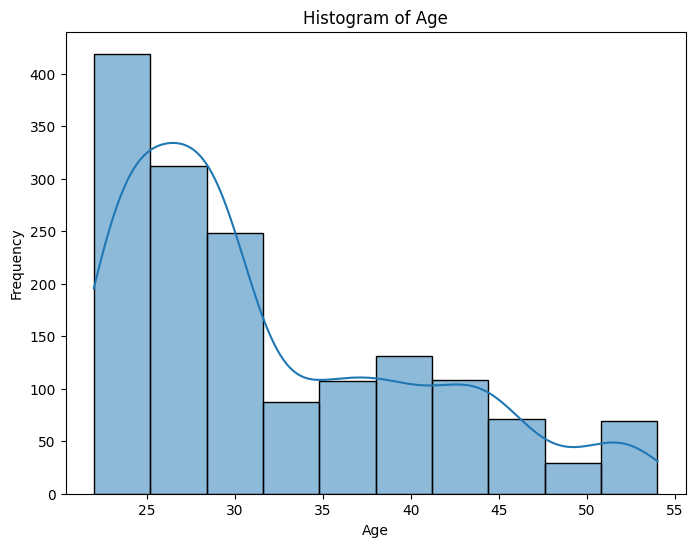

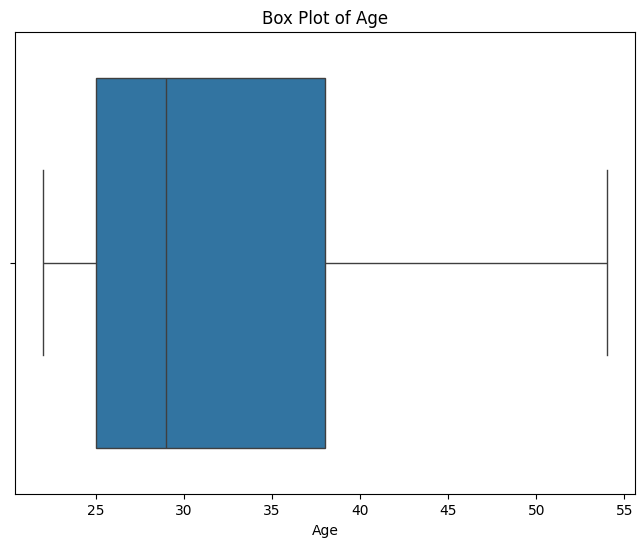


--- Analysis Complete for Column: Age ---

--- Analyzing Column: Gender ---

Data Type:
object

Missing Value Information:
Count: 0, Percentage: 0.000%

Categorical Summary Statistics:


,count
Gender,
Male,1252
Female,329


,proportion
Gender,
Male,0.791904
Female,0.208096


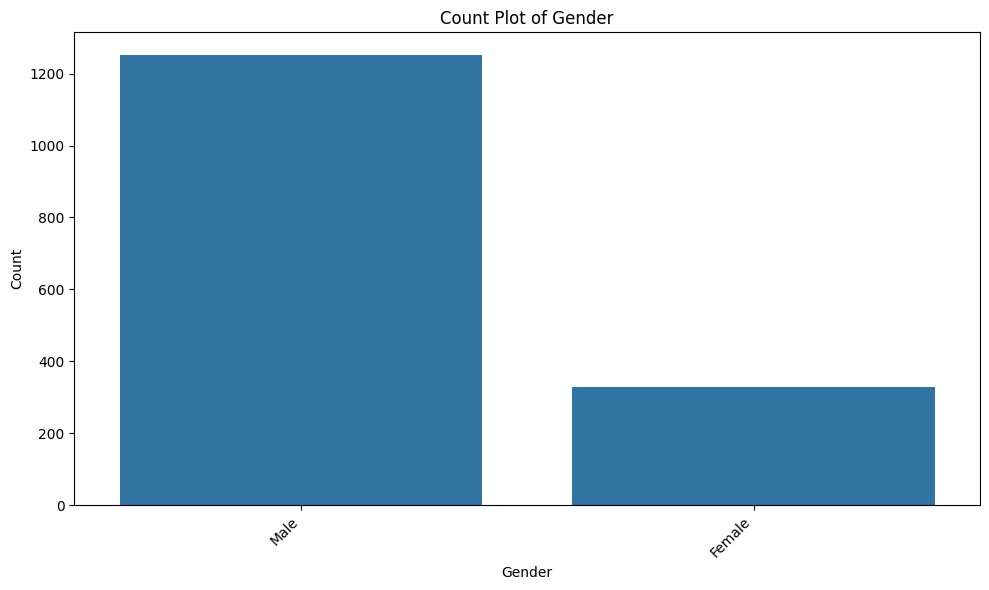


--- Analysis Complete for Column: Gender ---

--- Analyzing Column: Profession ---

Data Type:
object

Missing Value Information:
Count: 0, Percentage: 0.000%

Categorical Summary Statistics:


,count
Profession,
Salaried,896
Business,685


,proportion
Profession,
Salaried,0.56673
Business,0.43327


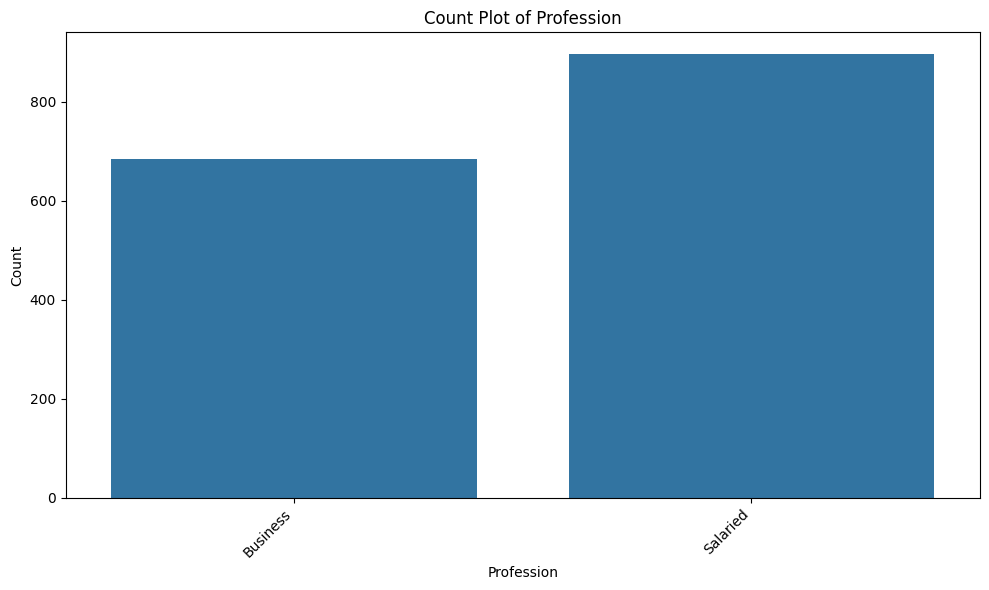


--- Analysis Complete for Column: Profession ---

--- Analyzing Column: Marital_status ---

Data Type:
object

Missing Value Information:
Count: 0, Percentage: 0.000%

Categorical Summary Statistics:


,count
Marital_status,
Married,1443
Single,138


,proportion
Marital_status,
Married,0.912713
Single,0.087287


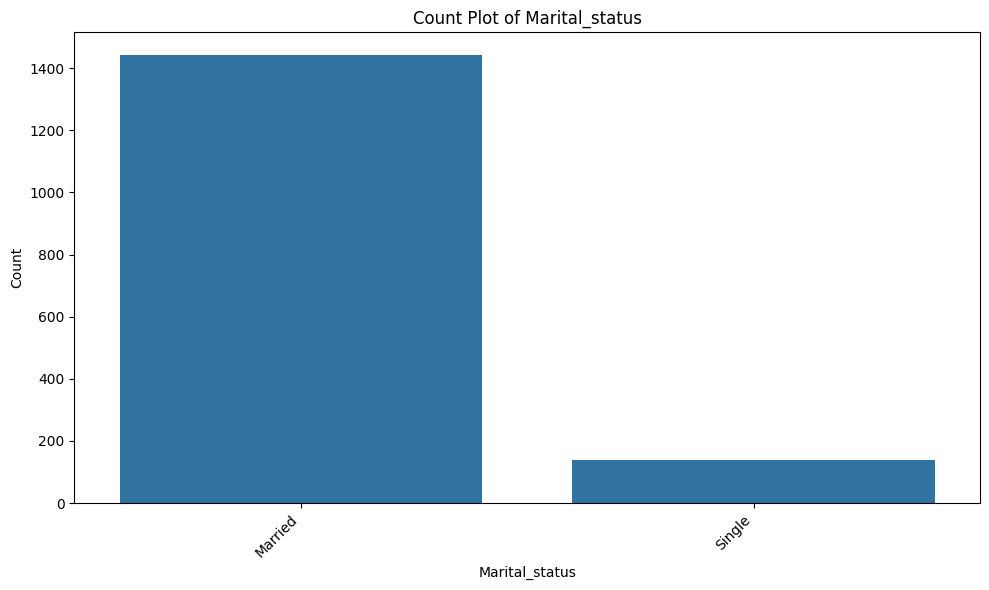


--- Analysis Complete for Column: Marital_status ---

--- Analyzing Column: Education ---

Data Type:
object

Missing Value Information:
Count: 0, Percentage: 0.000%

Categorical Summary Statistics:


,count
Education,
Post Graduate,985
Graduate,596


,proportion
Education,
Post Graduate,0.623023
Graduate,0.376977


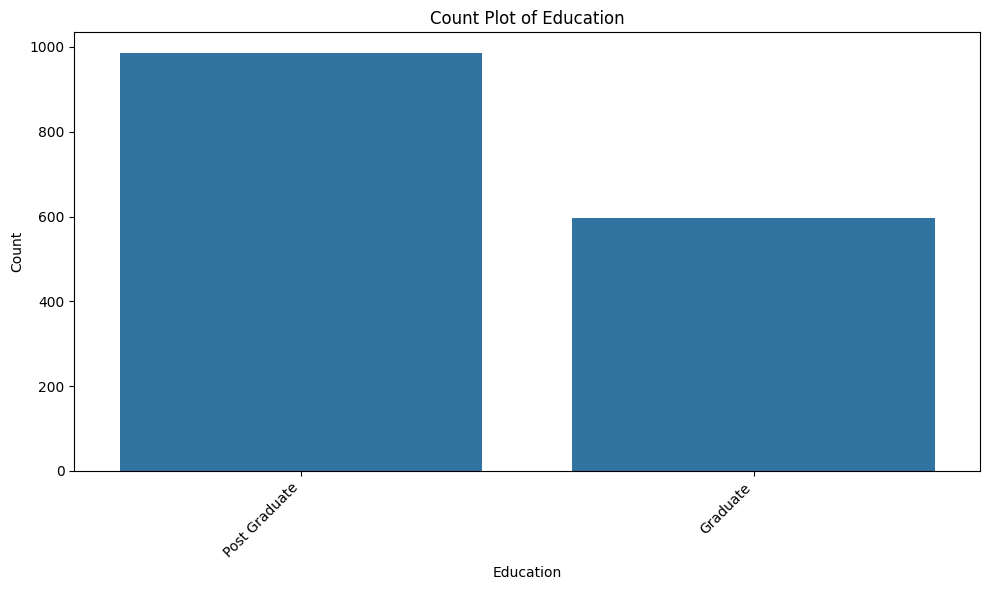


--- Analysis Complete for Column: Education ---

--- Analyzing Column: No_of_Dependents ---

Data Type:
object

Missing Value Information:
Count: 0, Percentage: 0.000%

Categorical Summary Statistics:


,count
No_of_Dependents,
3,557
2,557
1,229
4,218
0,20


,proportion
No_of_Dependents,
3,0.352309
2,0.352309
1,0.144845
4,0.137887
0,0.012650


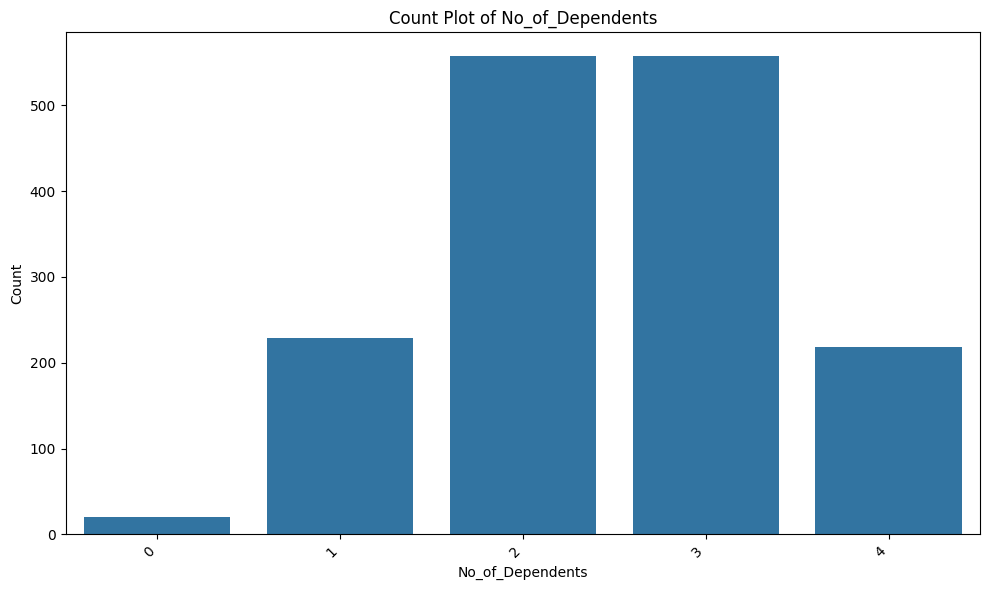


--- Analysis Complete for Column: No_of_Dependents ---

--- Analyzing Column: Personal_loan ---

Data Type:
object

Missing Value Information:
Count: 0, Percentage: 0.000%

Categorical Summary Statistics:


,count
Personal_loan,
Yes,792
No,789


,proportion
Personal_loan,
Yes,0.500949
No,0.499051


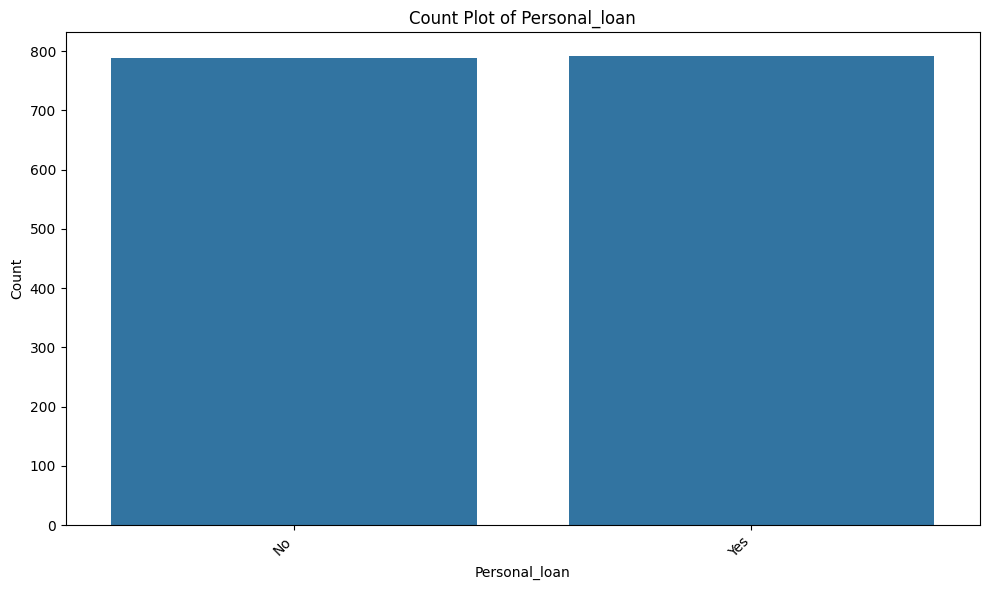


--- Analysis Complete for Column: Personal_loan ---

--- Analyzing Column: House_loan ---

Data Type:
object

Missing Value Information:
Count: 0, Percentage: 0.000%

Categorical Summary Statistics:


,count
House_loan,
No,1054
Yes,527


,proportion
House_loan,
No,0.666667
Yes,0.333333


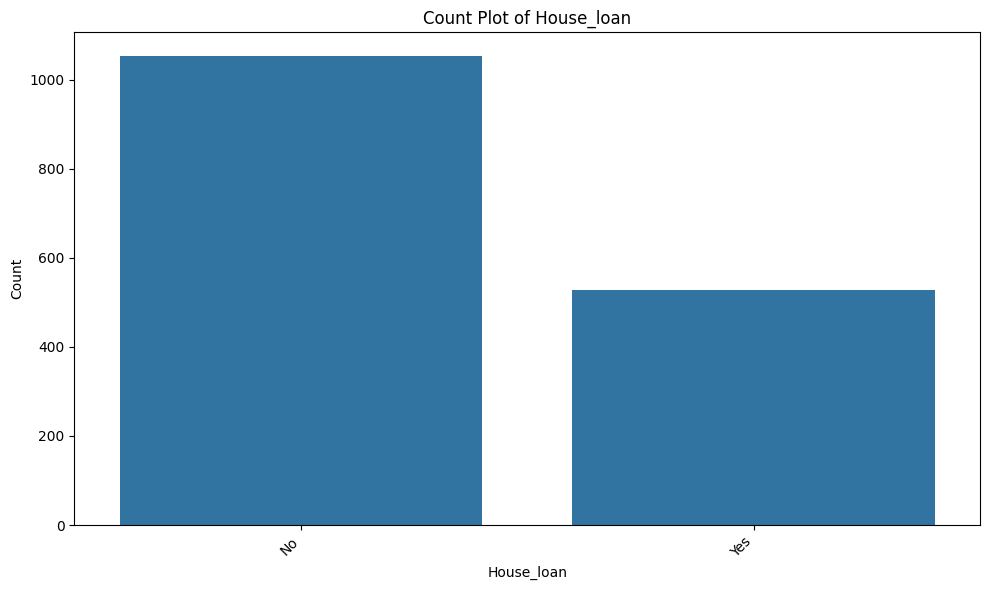


--- Analysis Complete for Column: House_loan ---

--- Analyzing Column: Partner_working ---

Data Type:
object

Missing Value Information:
Count: 0, Percentage: 0.000%

Categorical Summary Statistics:


,count
Partner_working,
Yes,868
No,713


,proportion
Partner_working,
Yes,0.54902
No,0.45098


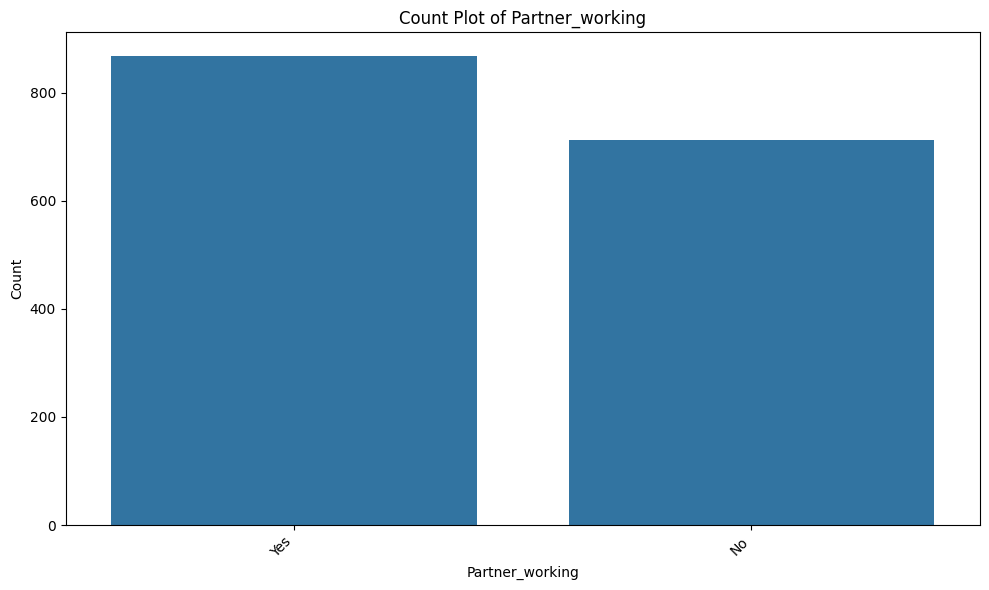


--- Analysis Complete for Column: Partner_working ---

--- Analyzing Column: Salary ---

Data Type:
int64

Missing Value Information:
Count: 0, Percentage: 0.000%

Numerical Summary Statistics:


,Salary
count,1581.000000
mean,60392.220114
std,14674.825044
min,30000.000000
25%,51900.000000
50%,59500.000000
75%,71800.000000
max,99300.000000


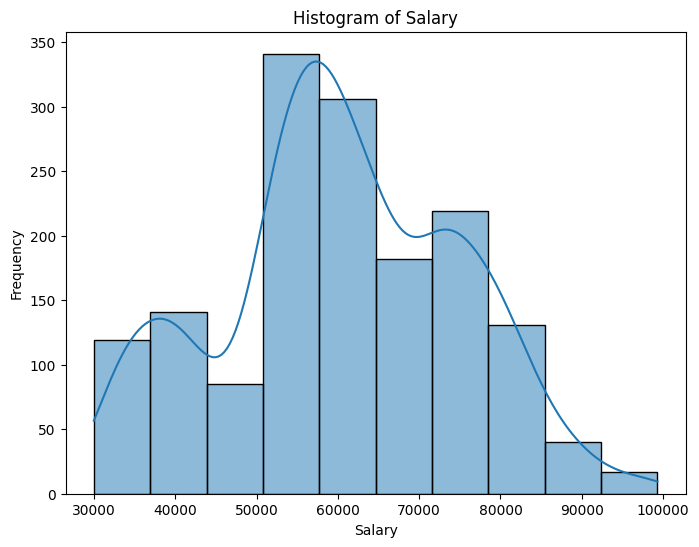

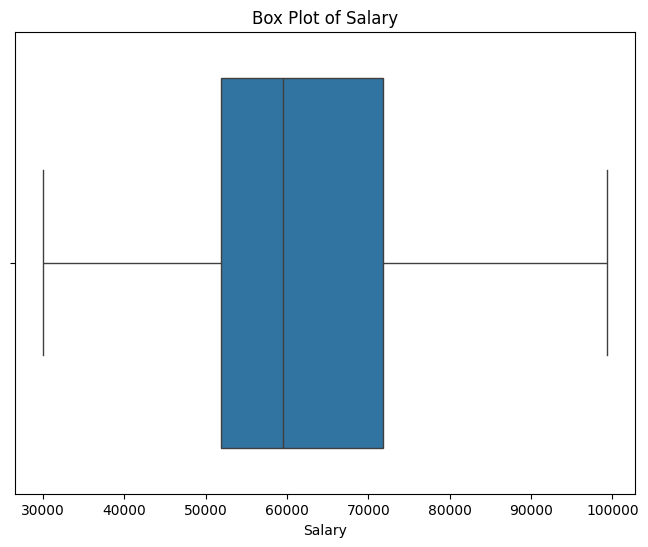


--- Analysis Complete for Column: Salary ---

--- Analyzing Column: Partner_salary ---

Data Type:
float64

Missing Value Information:
Count: 0, Percentage: 0.000%

Numerical Summary Statistics:


,Partner_salary
count,1581.000000
mean,19233.776091
std,19670.391171
min,0.000000
25%,0.000000
50%,25100.000000
75%,38100.000000
max,80500.000000


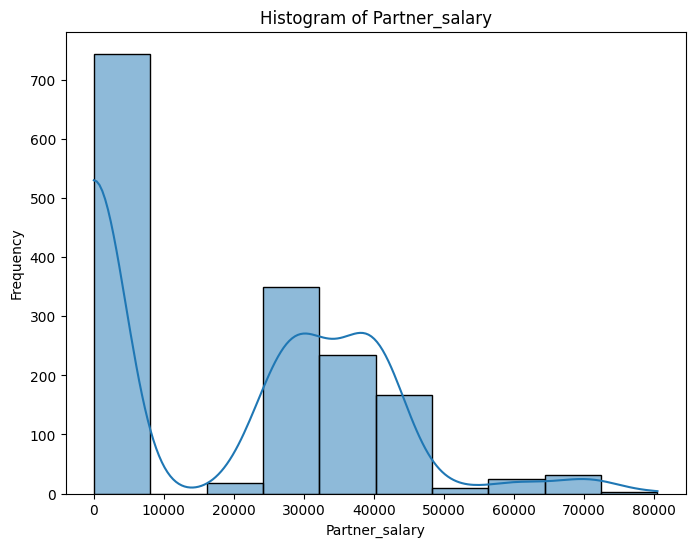

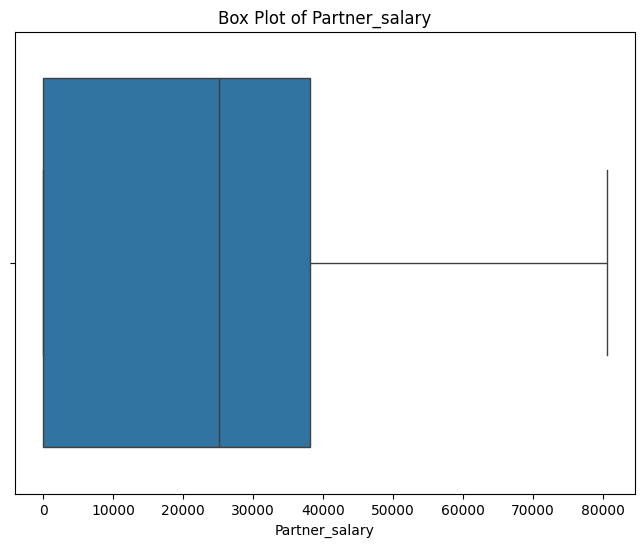


--- Analysis Complete for Column: Partner_salary ---

--- Analyzing Column: Total_salary ---

Data Type:
int64

Missing Value Information:
Count: 0, Percentage: 0.000%

Numerical Summary Statistics:


,Total_salary
count,1581.000000
mean,79625.996205
std,25545.857768
min,30000.000000
25%,60500.000000
50%,78000.000000
75%,95900.000000
max,171000.000000


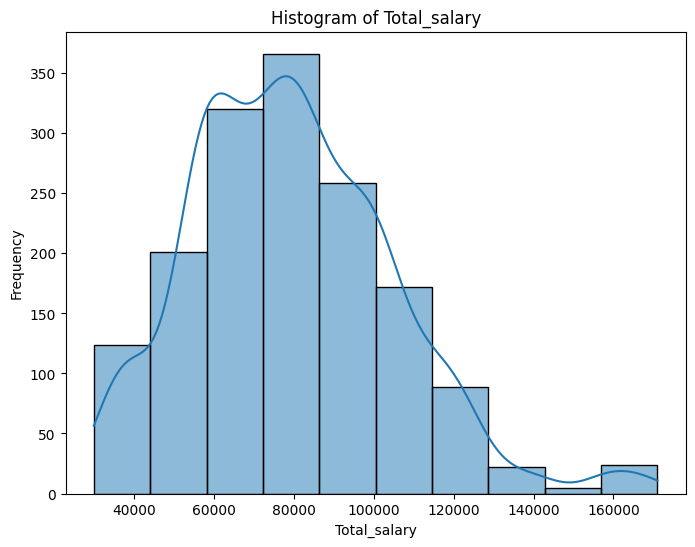

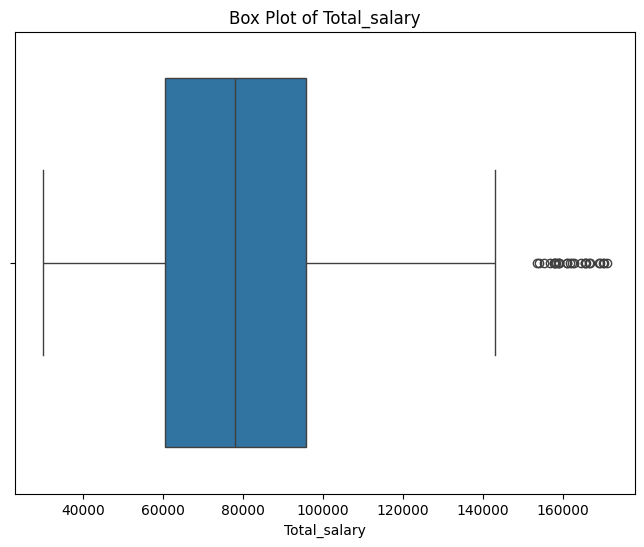


--- Analysis Complete for Column: Total_salary ---

--- Analyzing Column: Price ---

Data Type:
int64

Missing Value Information:
Count: 0, Percentage: 0.000%

Numerical Summary Statistics:


,Price
count,1581.000000
mean,35597.722960
std,13633.636545
min,18000.000000
25%,25000.000000
50%,31000.000000
75%,47000.000000
max,70000.000000


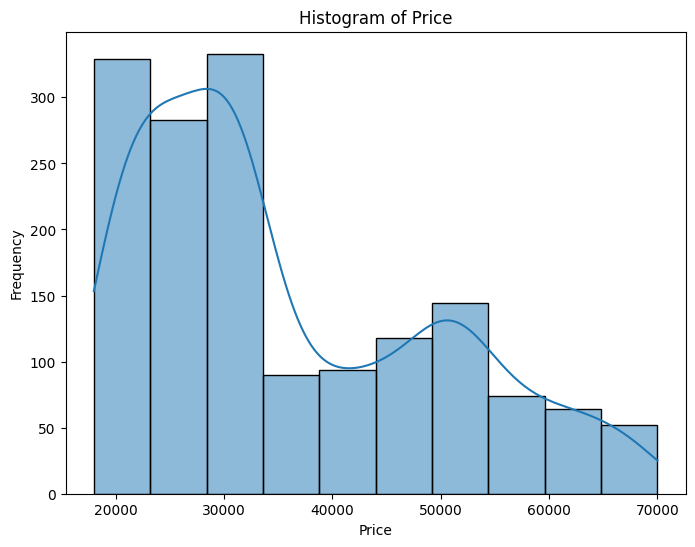

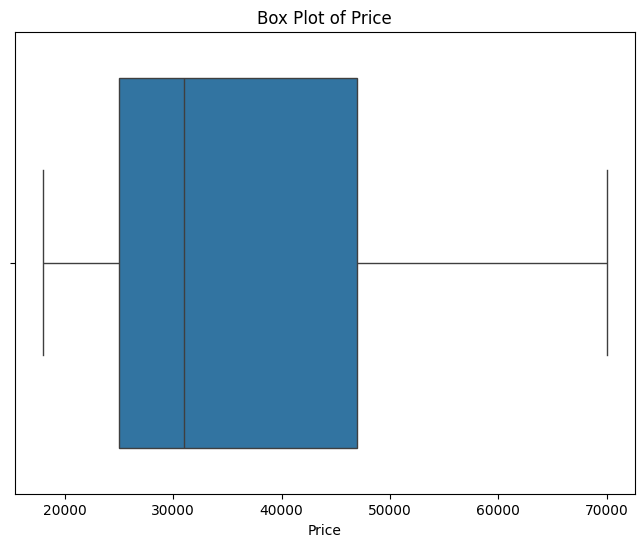


--- Analysis Complete for Column: Price ---

--- Analyzing Column: Make ---

Data Type:
object

Missing Value Information:
Count: 0, Percentage: 0.000%

Categorical Summary Statistics:


,count
Make,
Sedan,702
Hatchback,582
SUV,297


,proportion
Make,
Sedan,0.444023
Hatchback,0.368121
SUV,0.187856


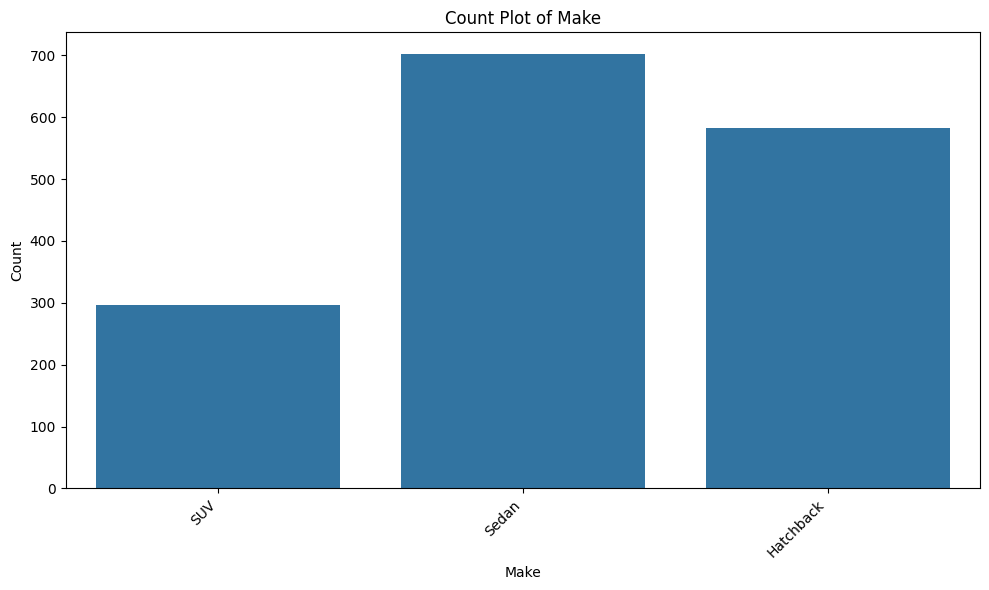


--- Analysis Complete for Column: Make ---


In [34]:
for i in df.columns:
  analyzer.analyze_column(i)

### Univariate Analysis: Observations and Insights
---
* **Age**: The average customer age is **32 years**, ranging from 22 to 54. There are no notable outliers. Most buyers are between the ages of **22 and 29**.

* **Gender**: Approximately **79%** of the sample is male.

* **Profession**: The professional split is nearly even, with **56% salaried** and **44% in business**.

* **Marital Status**: A significant **90%** of the individuals are married. Further bivariate analysis is needed to understand the breakdown by gender.

* **Education**: The sample consists of **62% post-graduates** and **38% graduates**. A more in-depth analysis will explore the correlation between education, salary, and vehicle choice.

* **Number of Dependents**: The number of dependents ranges up to four, with the majority of customers having **two dependents**. This suggests many buyers are part of families with two children or have a single working parent with one child and an unemployed partner.

* **Loan Status**:
    * **Personal Loan**: The distribution between those with and without a personal loan is nearly equal.
    * **House Loan**: **66%** of customers have a house loan. Multivariate analysis, such as a facet grid, could reveal the relationship between loan status and purchase decisions.

* **Partner Working**: **54%** of customers have a working partner.

* **Salary**:
    * **Individual Salary**: The average salary is **$60,000**, with a maximum of **$99,300**. The data is slightly right-skewed but contains no outliers.
    * **Partner Salary**: With an average of around **$19,000** and a maximum of **$80,500**, this data is heavily right-skewed.
    * **Total Salary**: The average total salary is **$79,625**. It's right-skewed with multiple points outside the whiskers, but these are considered legitimate data points, so no outlier treatment is necessary.

* **Price**: The average price of a vehicle is **$35,597**, with a minimum of **$7,000**. It will be important to analyze if the vehicle price or customer preference for a specific make is the primary driver of purchase decisions.

* **Make**: This is the **dependent variable**. The main objective is to determine how independent variables—like age, profession, price, and marital status—influence the choice of vehicle type.

## Bivariate Analysis

In [35]:
bivariate_analyzer = BivariateAnalyzer(df)


Analyzing numerical-categorical relationship between Age and Gender


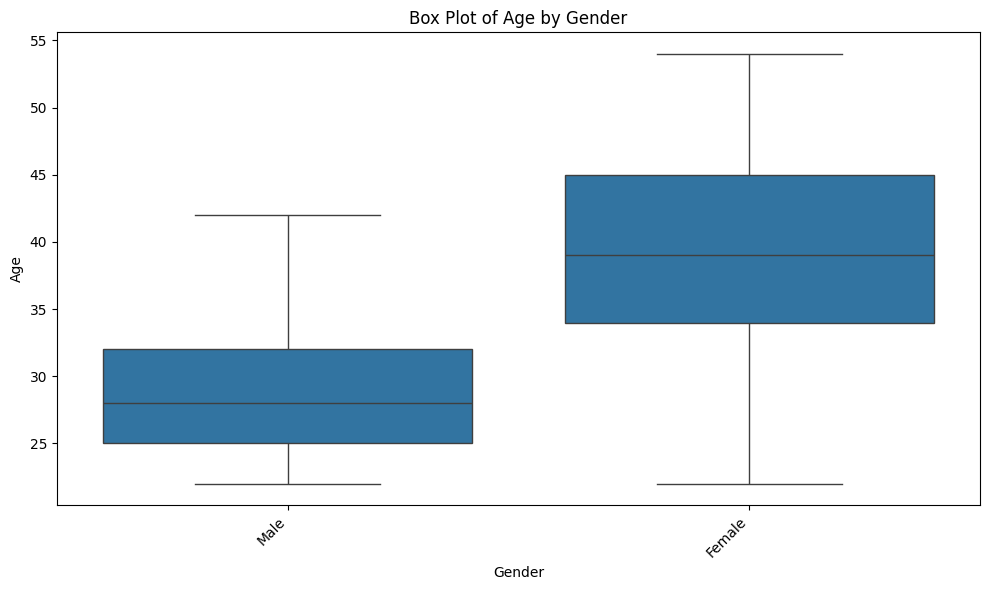

In [36]:
bivariate_analyzer.analyze_bivariate('Age', 'Gender')


Analyzing numerical-numerical relationship between Age and Price


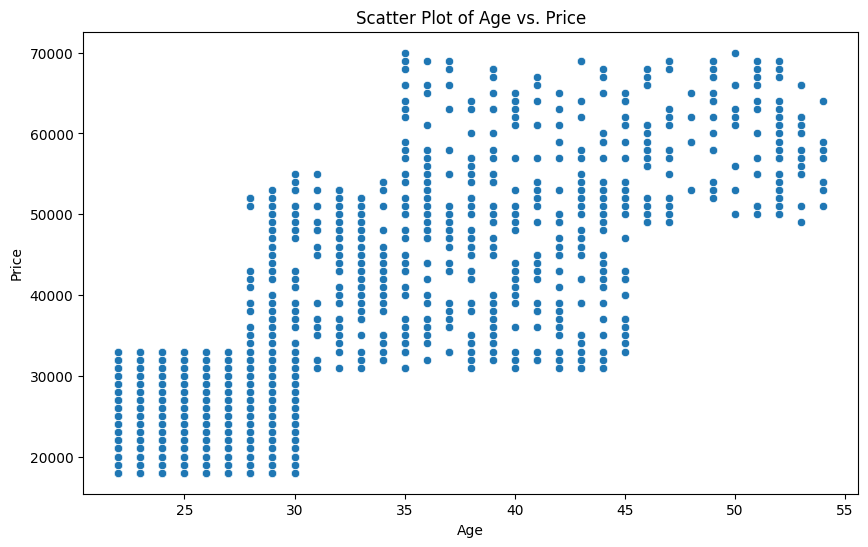

In [37]:
bivariate_analyzer.analyze_bivariate('Age', 'Price')


Analyzing categorical-categorical relationship between Gender and Profession

--- Analyzing Relationship between Gender and Profession ---

Contingency Table:


Profession,Business,Salaried
Gender,,
Female,105,224
Male,580,672


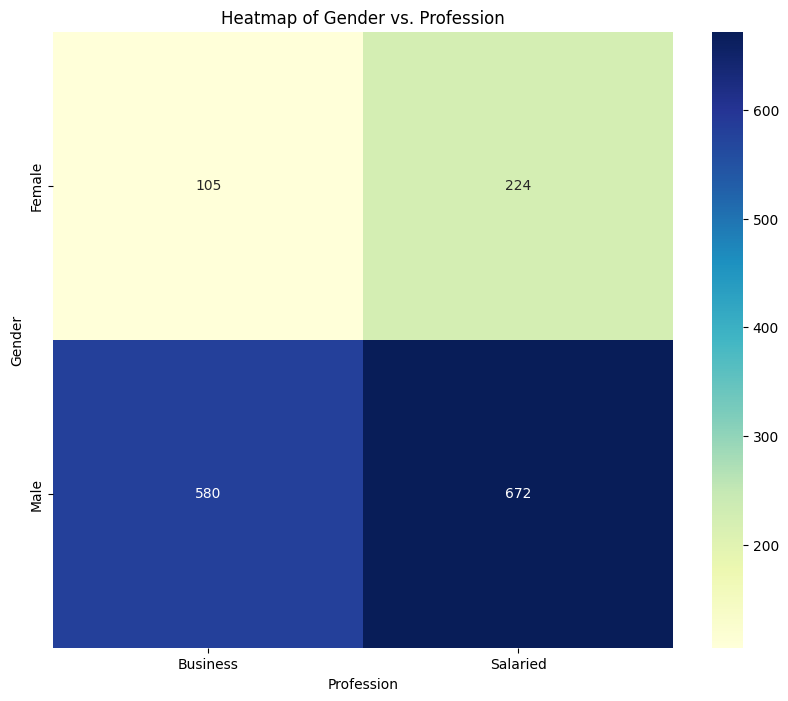


--- Analysis Complete for Gender and Profession ---


In [38]:
bivariate_analyzer.analyze_bivariate('Gender', 'Profession')

In [39]:
# SPlit the columns to 2 List , categorical and Numerical
cat , nums = [], []
for i in df.columns:
    if df[i].dtypes != 'object':
        nums.append(i)
    else:
        cat.append(i)
print(cat)
print(nums)

['Gender', 'Profession', 'Marital_status', 'Education', 'No_of_Dependents', 'Personal_loan', 'House_loan', 'Partner_working', 'Make']
['Age', 'Salary', 'Partner_salary', 'Total_salary', 'Price']


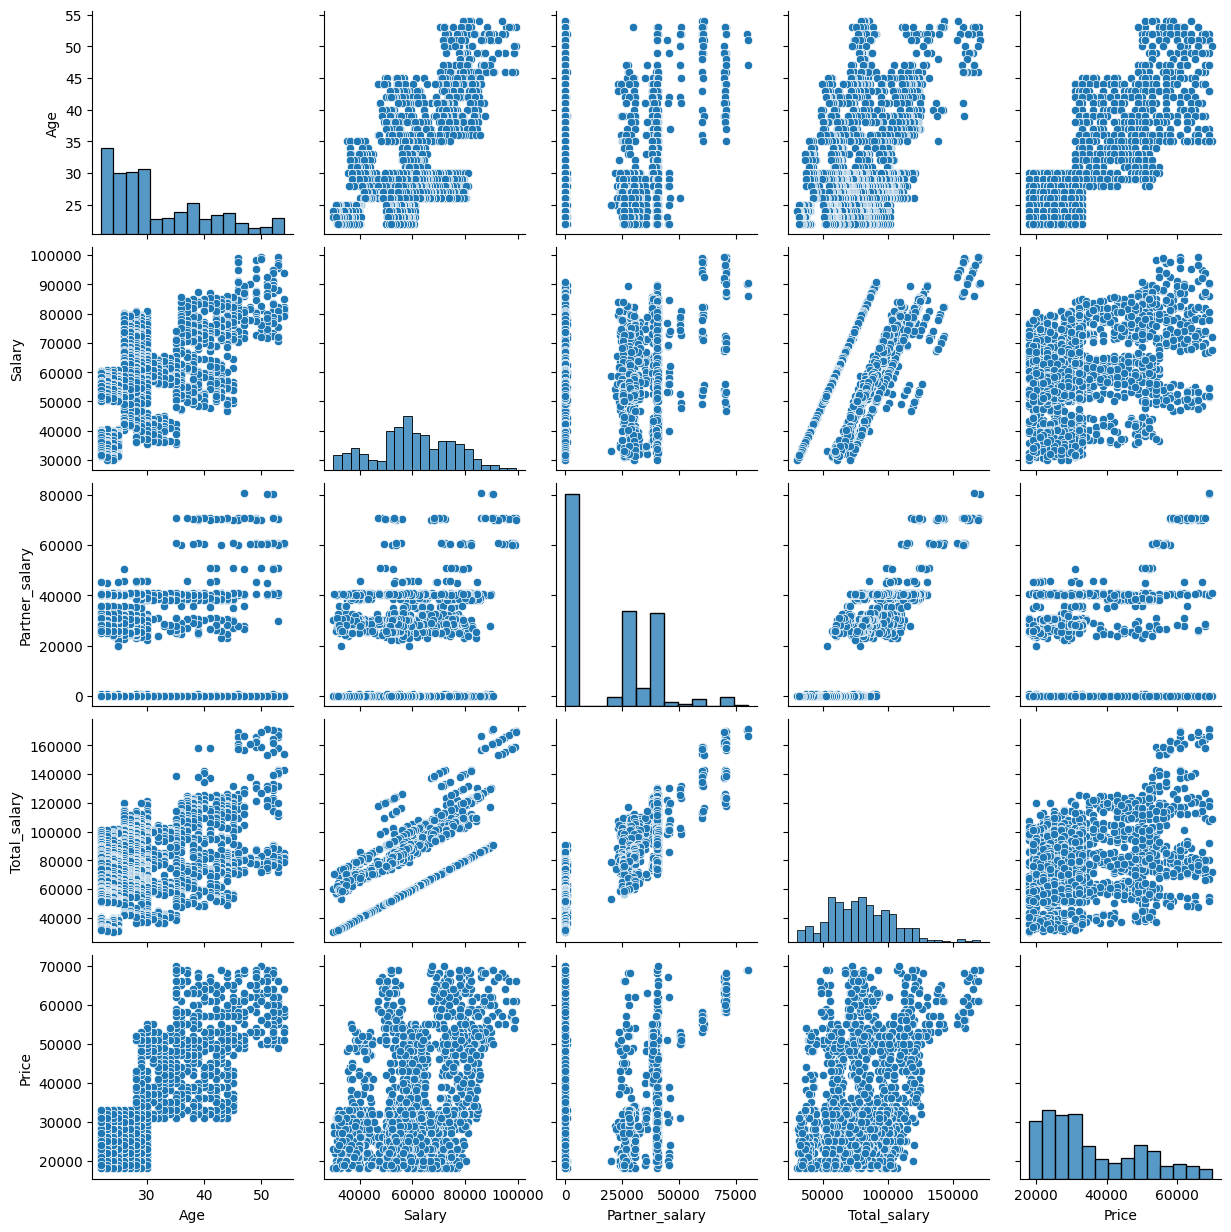

In [40]:
sns.pairplot(df[nums])

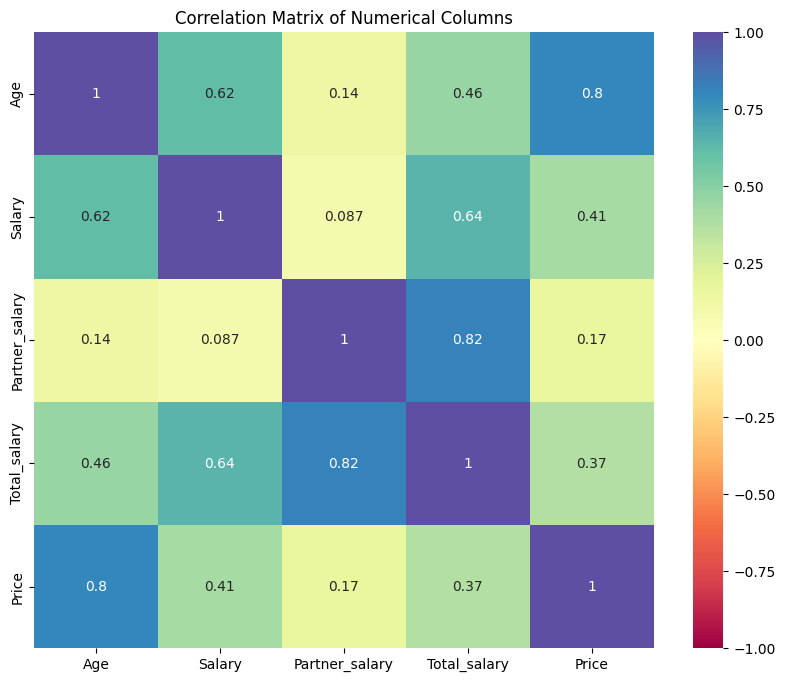

In [41]:
bivariate_analyzer.plot_correlation_matrix()

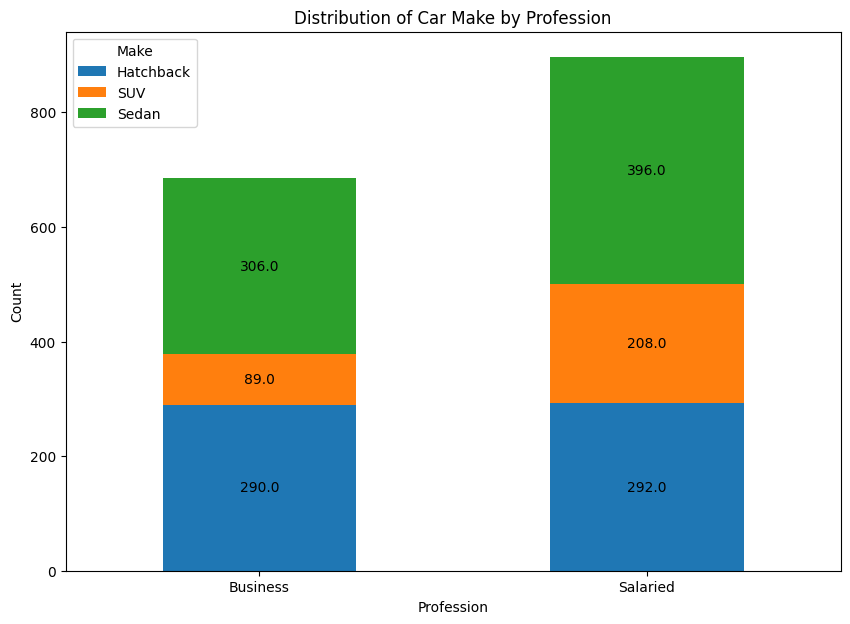

In [42]:
# Reshape the data for plotting
profession_make_counts = df.groupby(['Profession', 'Make']).size().unstack(fill_value=0)


# Plotting a stacked bar chart
ax = profession_make_counts.plot(kind='bar', stacked=True, figsize=(10, 7))

plt.title('Distribution of Car Make by Profession')
plt.xlabel('Profession')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Make')

# Add percentage labels to the bars
for container in ax.containers:
    labels = [f'{bar.get_height():.1f}' if bar.get_height() > 0 else '' for bar in container]
    ax.bar_label(container, labels=labels, label_type='center')

plt.show()

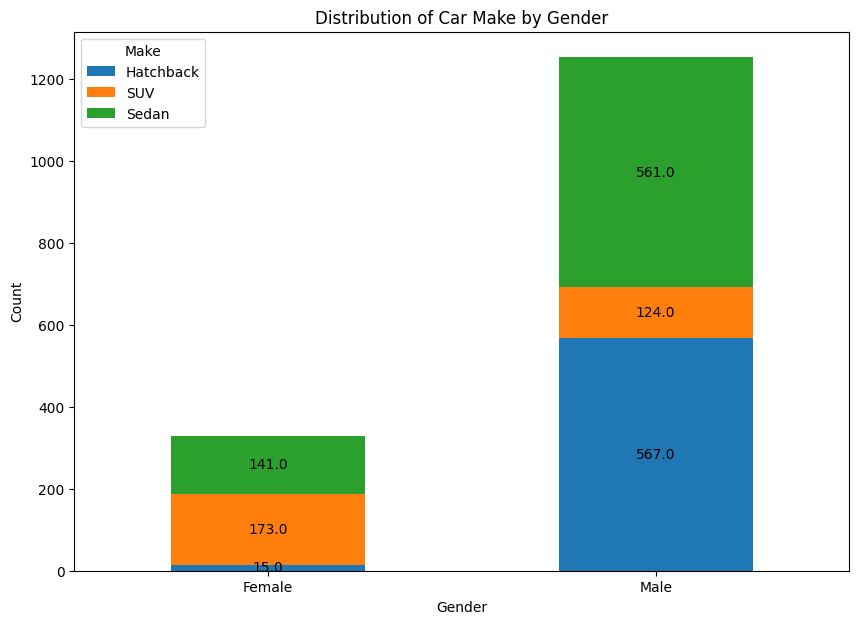

In [43]:
profession_make_counts = df.groupby(['Gender', 'Make']).size().unstack(fill_value=0)


# Plotting a stacked bar chart
ax = profession_make_counts.plot(kind='bar', stacked=True, figsize=(10, 7))

plt.title('Distribution of Car Make by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Make')

# Add percentage labels to the bars
for container in ax.containers:
    labels = [f'{bar.get_height():.1f}' if bar.get_height() > 0 else '' for bar in container]
    ax.bar_label(container, labels=labels, label_type='center')

plt.show()

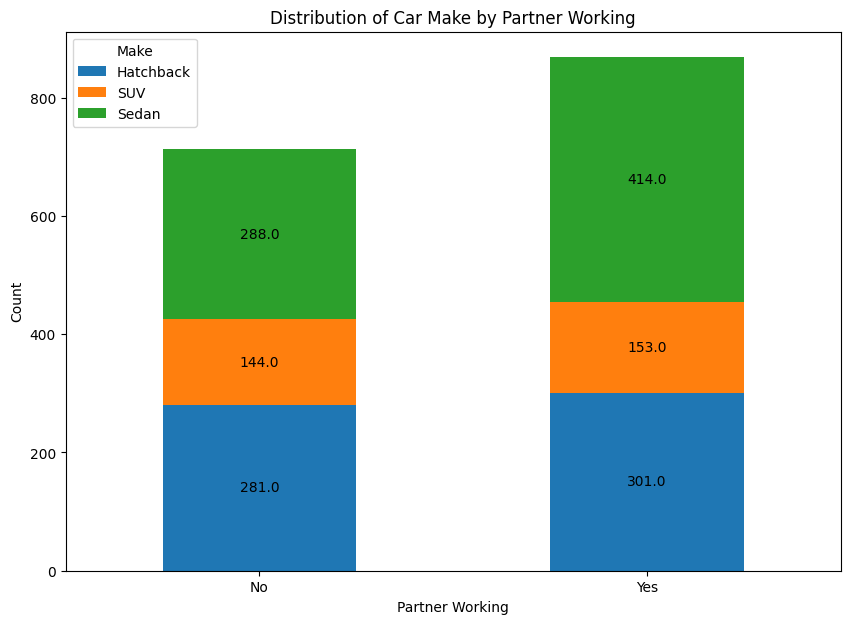

In [44]:
profession_make_counts = df.groupby(['Partner_working', 'Make']).size().unstack(fill_value=0)


# Plotting a stacked bar chart
ax = profession_make_counts.plot(kind='bar', stacked=True, figsize=(10, 7))

plt.title('Distribution of Car Make by Partner Working')
plt.xlabel('Partner Working')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Make')

# Add percentage labels to the bars
for container in ax.containers:
    labels = [f'{bar.get_height():.1f}' if bar.get_height() > 0 else '' for bar in container]
    ax.bar_label(container, labels=labels, label_type='center')

plt.show()

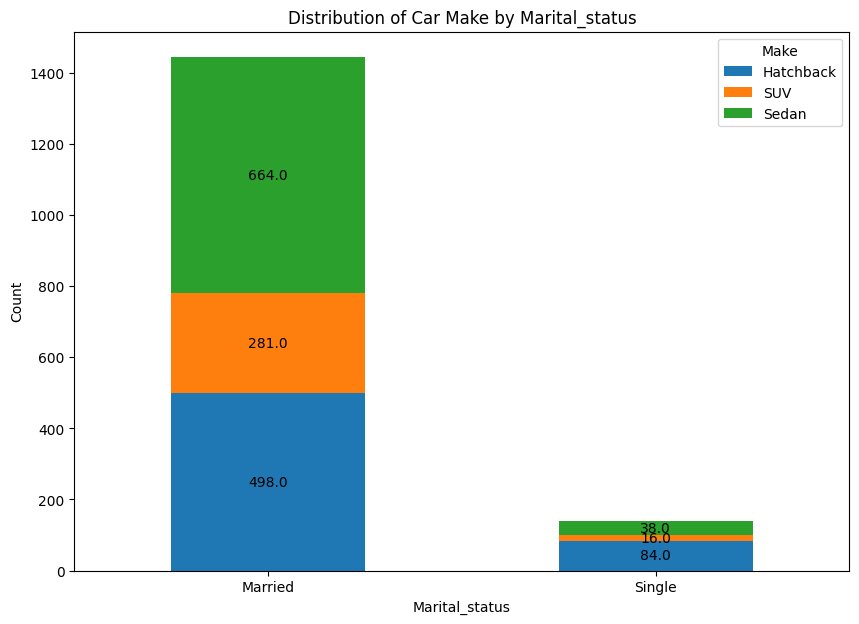

In [45]:
profession_make_counts = df.groupby(['Marital_status', 'Make']).size().unstack(fill_value=0)


# Plotting a stacked bar chart
ax = profession_make_counts.plot(kind='bar', stacked=True, figsize=(10, 7))

plt.title('Distribution of Car Make by Marital_status')
plt.xlabel('Marital_status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Make')

# Add percentage labels to the bars
for container in ax.containers:
    labels = [f'{bar.get_height():.1f}' if bar.get_height() > 0 else '' for bar in container]
    ax.bar_label(container, labels=labels, label_type='center')

plt.show()

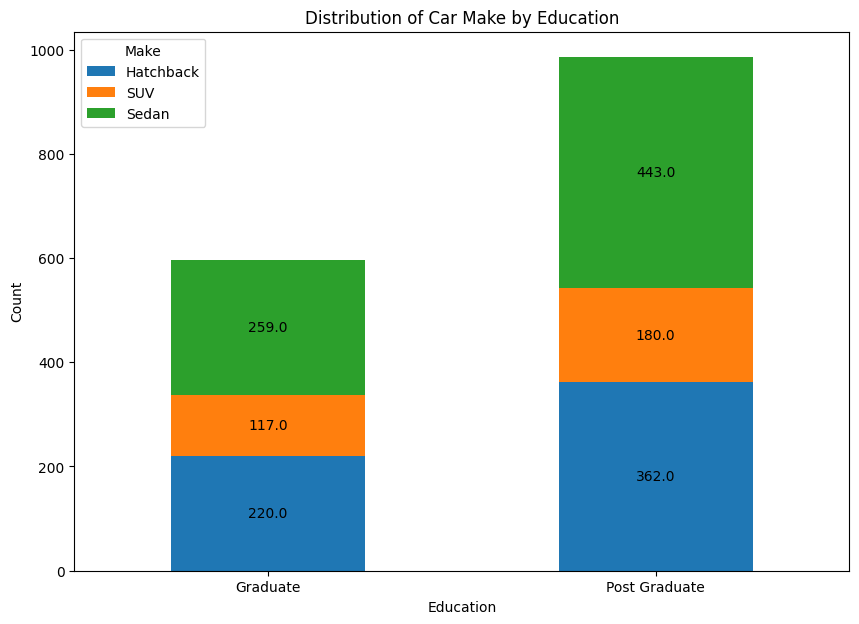

In [46]:
profession_make_counts = df.groupby(['Education', 'Make']).size().unstack(fill_value=0)


# Plotting a stacked bar chart
ax = profession_make_counts.plot(kind='bar', stacked=True, figsize=(10, 7))

plt.title('Distribution of Car Make by Education')
plt.xlabel('Education')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Make')

# Add percentage labels to the bars
for container in ax.containers:
    labels = [f'{bar.get_height():.1f}' if bar.get_height() > 0 else '' for bar in container]
    ax.bar_label(container, labels=labels, label_type='center')

plt.show()

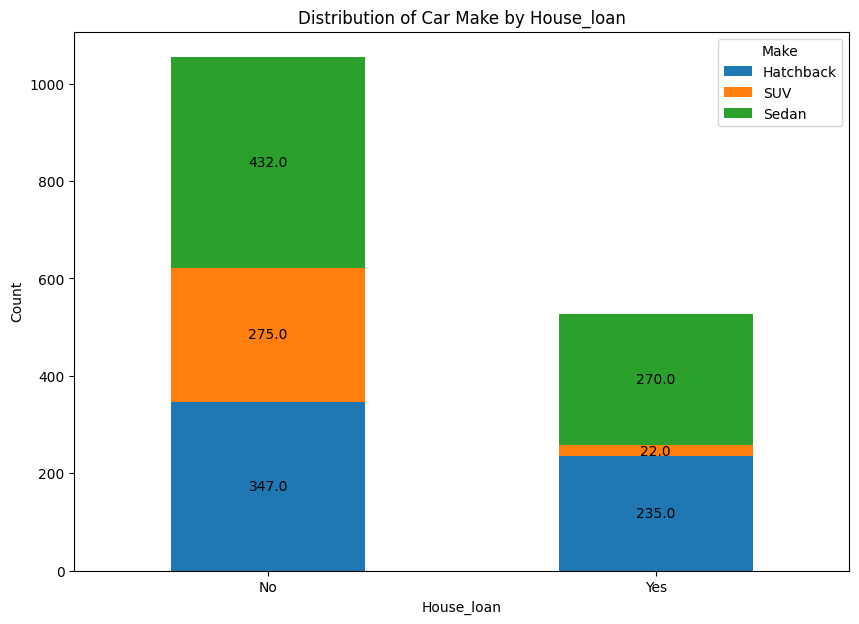

In [47]:
profession_make_counts = df.groupby(['House_loan', 'Make']).size().unstack(fill_value=0)


# Plotting a stacked bar chart
ax = profession_make_counts.plot(kind='bar', stacked=True, figsize=(10, 7))

plt.title('Distribution of Car Make by House_loan')
plt.xlabel('House_loan')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Make')

# Add percentage labels to the bars
for container in ax.containers:
    labels = [f'{bar.get_height():.1f}' if bar.get_height() > 0 else '' for bar in container]
    ax.bar_label(container, labels=labels, label_type='center')

plt.show()

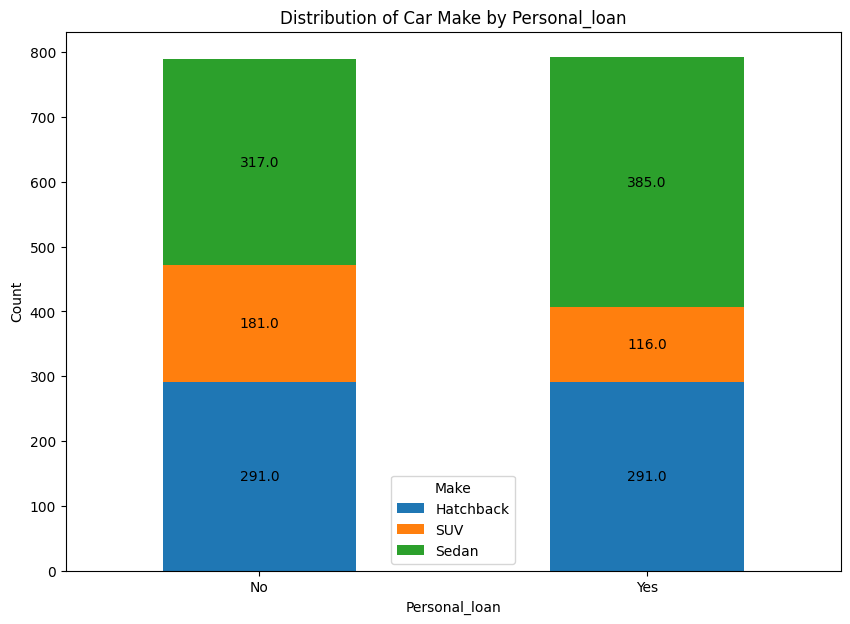

In [48]:
profession_make_counts = df.groupby(['Personal_loan', 'Make']).size().unstack(fill_value=0)


# Plotting a stacked bar chart
ax = profession_make_counts.plot(kind='bar', stacked=True, figsize=(10, 7))

plt.title('Distribution of Car Make by Personal_loan')
plt.xlabel('Personal_loan')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Make')

# Add percentage labels to the bars
for container in ax.containers:
    labels = [f'{bar.get_height():.1f}' if bar.get_height() > 0 else '' for bar in container]
    ax.bar_label(container, labels=labels, label_type='center')

plt.show()

### Exploring Relationships between Numerical Variables

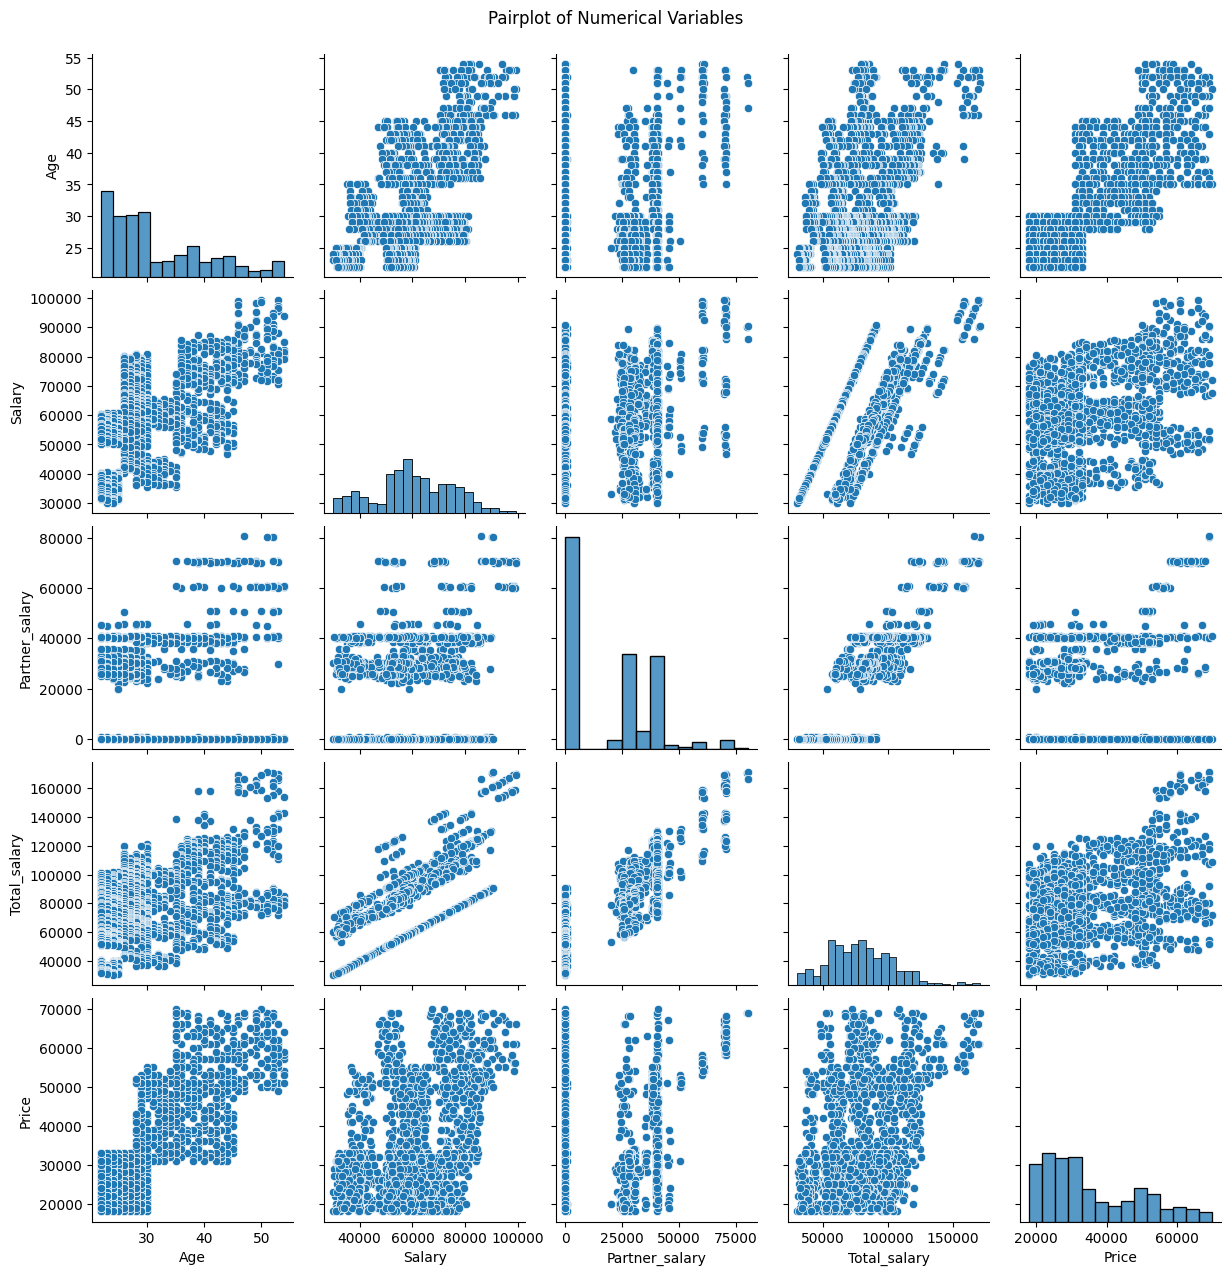

In [49]:
# Explore the relationship between all numerical variables using a pairplot
sns.pairplot(df[nums])
plt.suptitle('Pairplot of Numerical Variables', y=1.02)
plt.show()

### Exploring Correlation between Numerical Variables

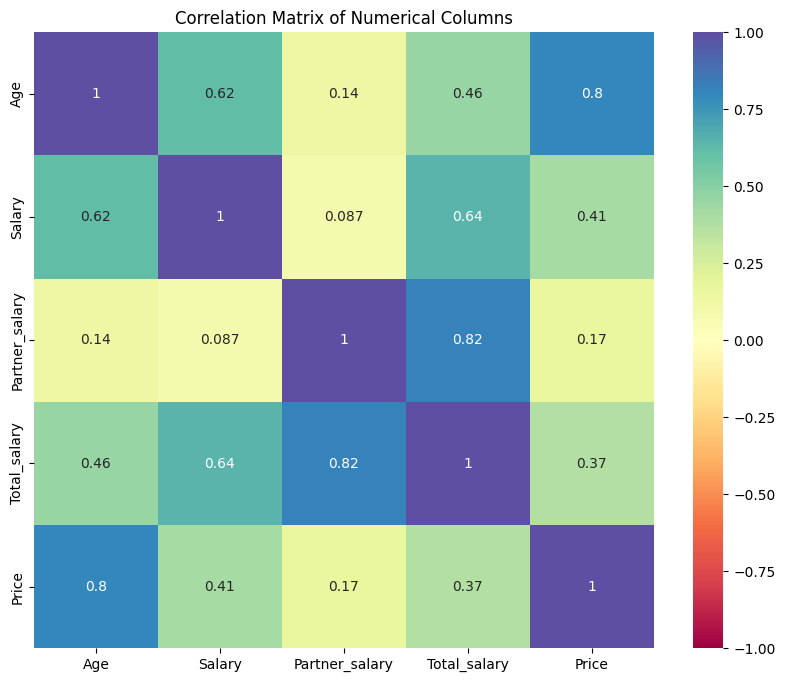

In [50]:
# Explore the correlation between all numerical variables using a heatmap
bivariate_analyzer.plot_correlation_matrix()

### Exploring Relationships between Categorical and Numerical Variables

Analyzing relationship between Gender and Age


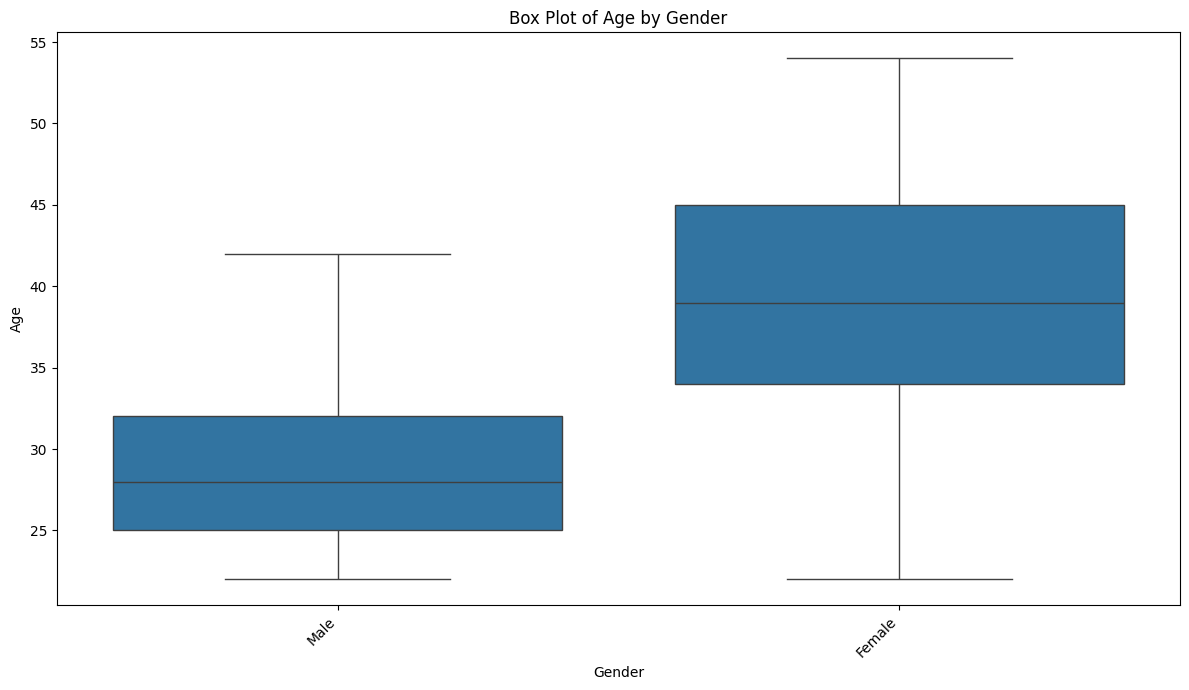

Analyzing relationship between Gender and Salary


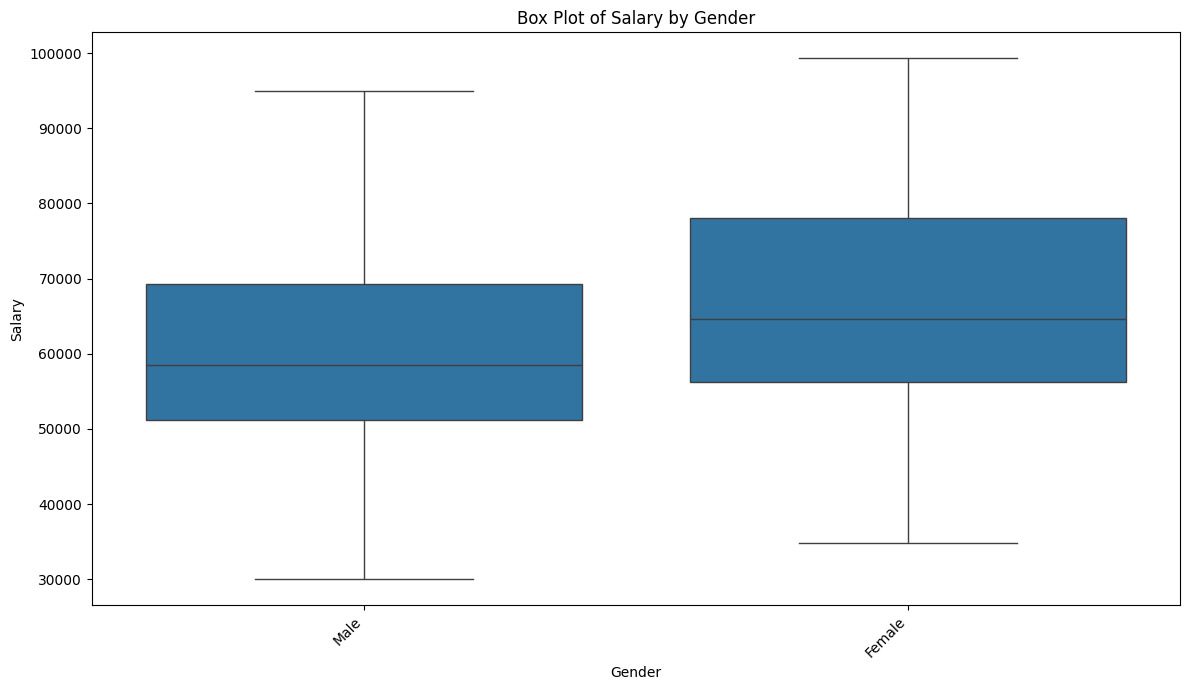

Analyzing relationship between Gender and Partner_salary


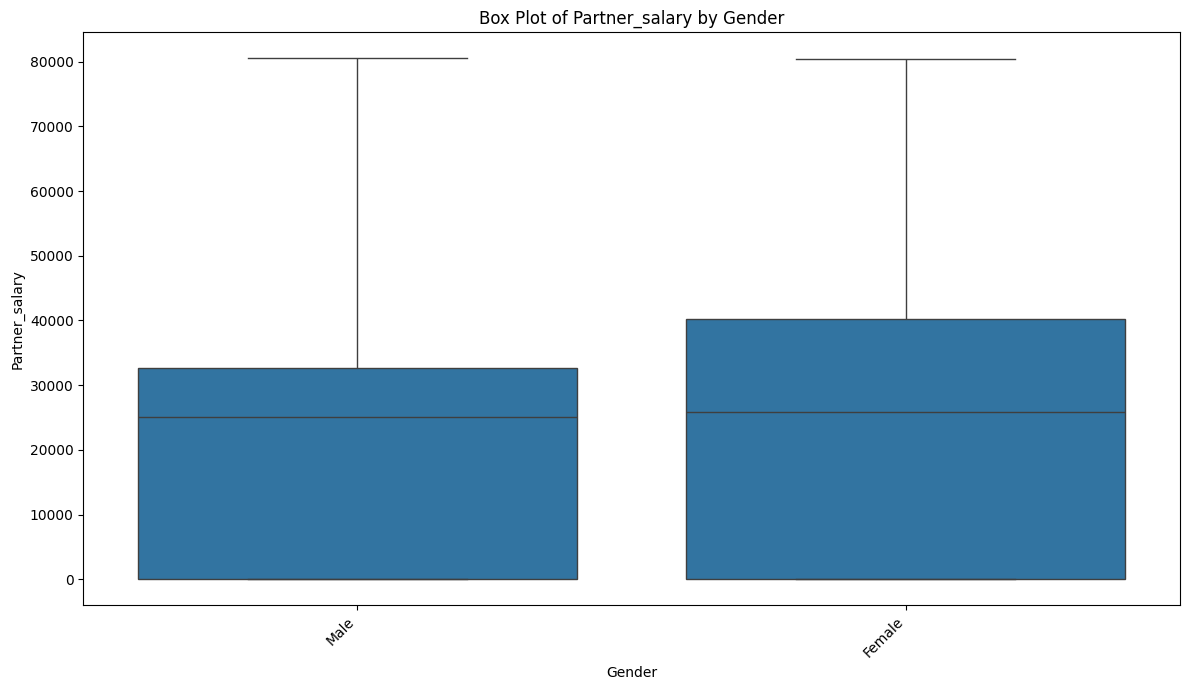

Analyzing relationship between Gender and Total_salary


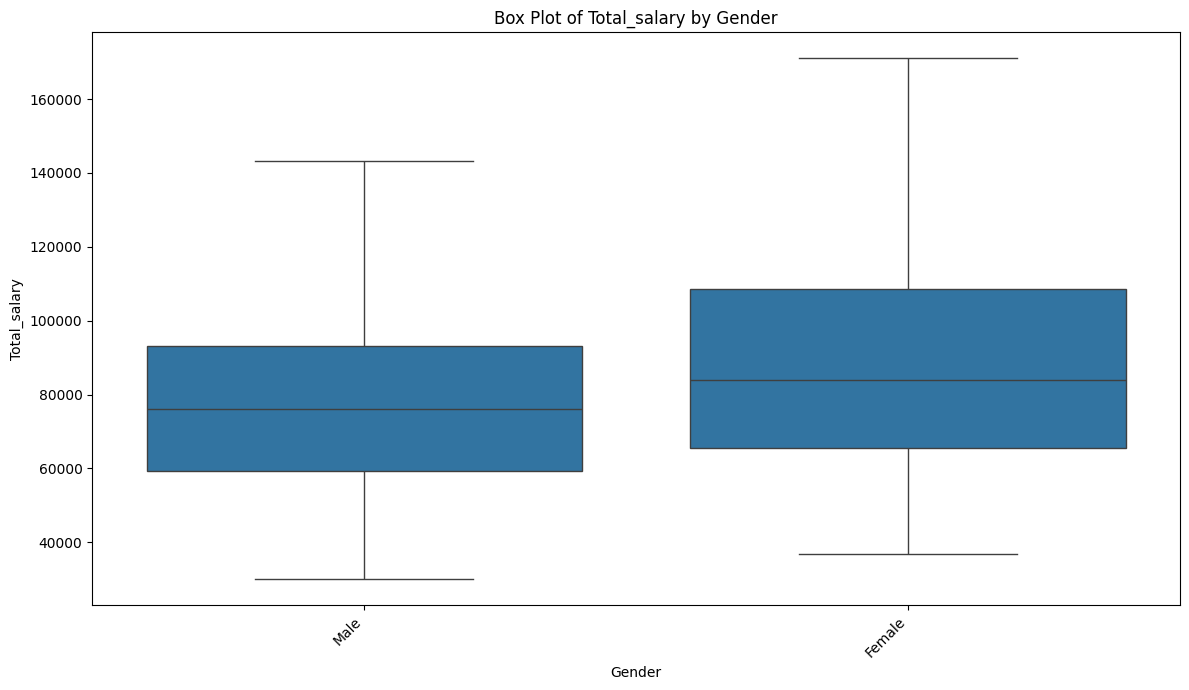

Analyzing relationship between Gender and Price


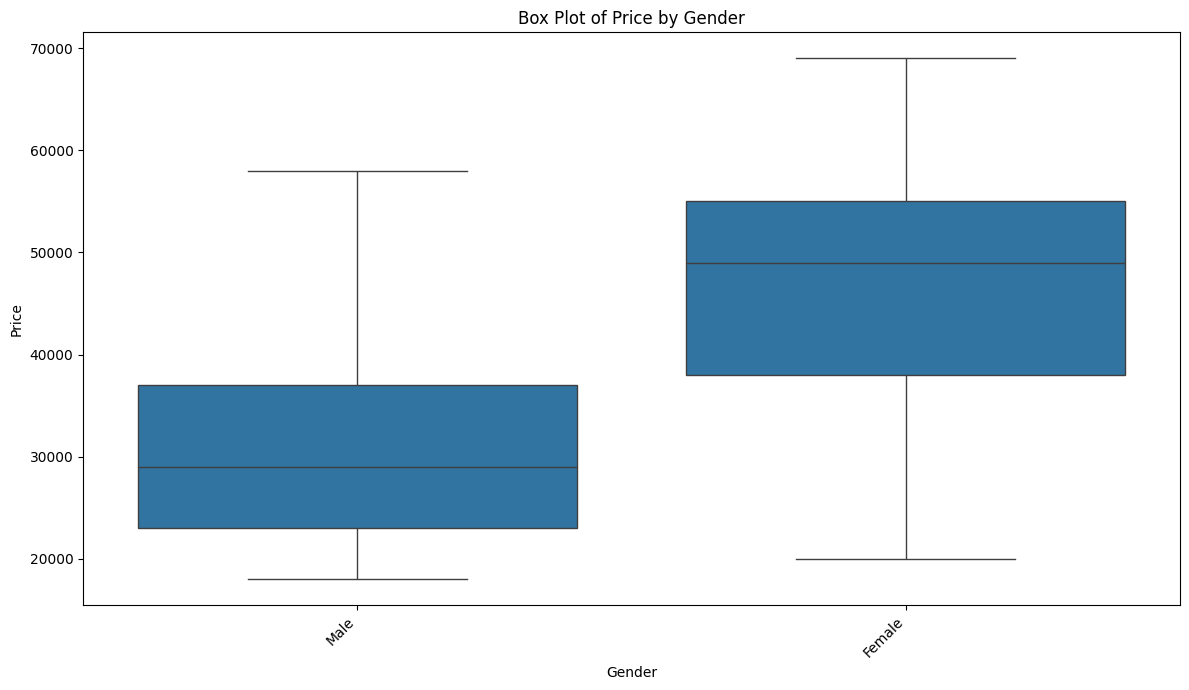

Analyzing relationship between Profession and Age


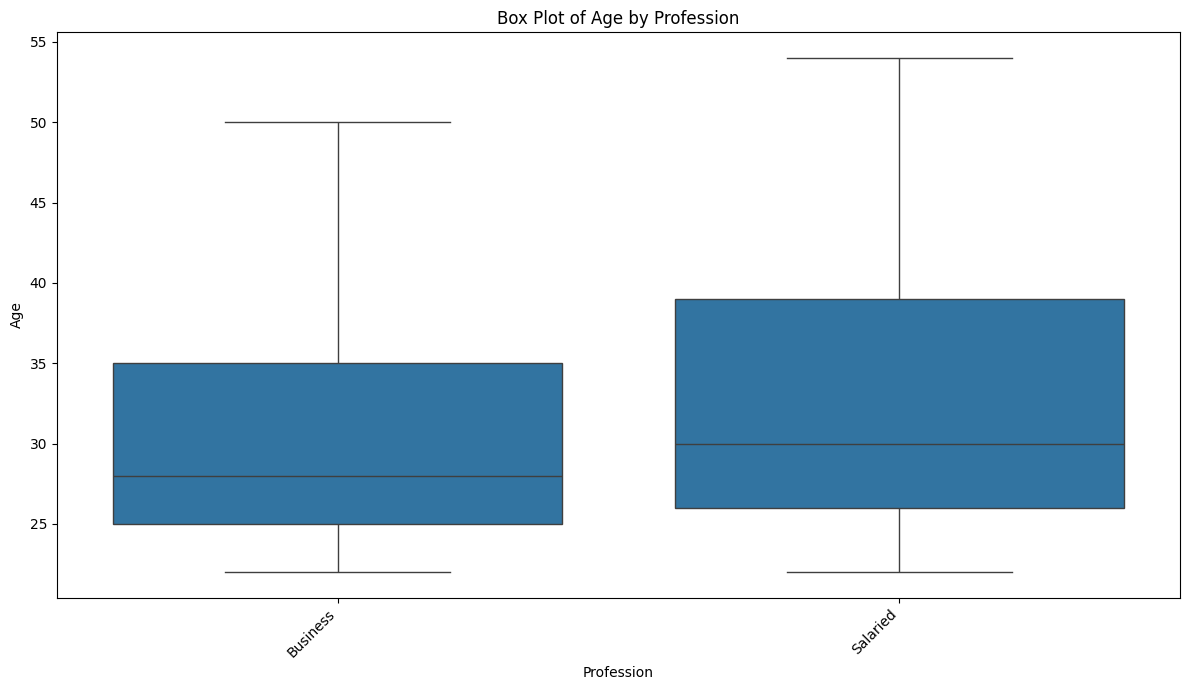

Analyzing relationship between Profession and Salary


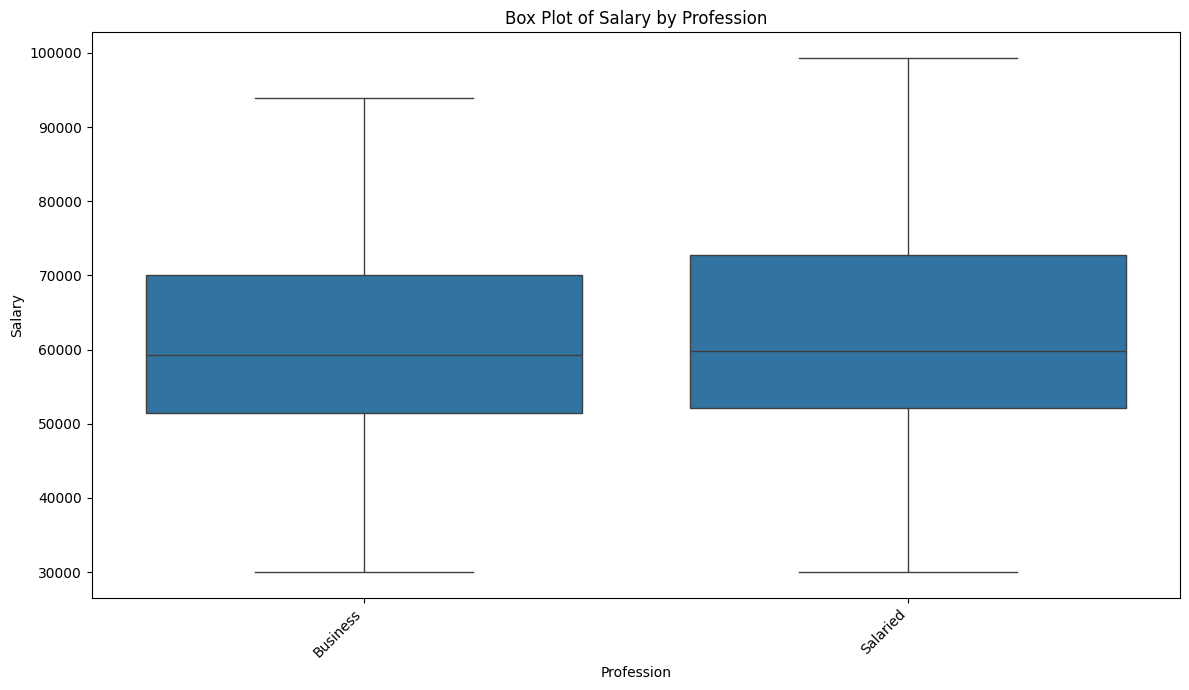

Analyzing relationship between Profession and Partner_salary


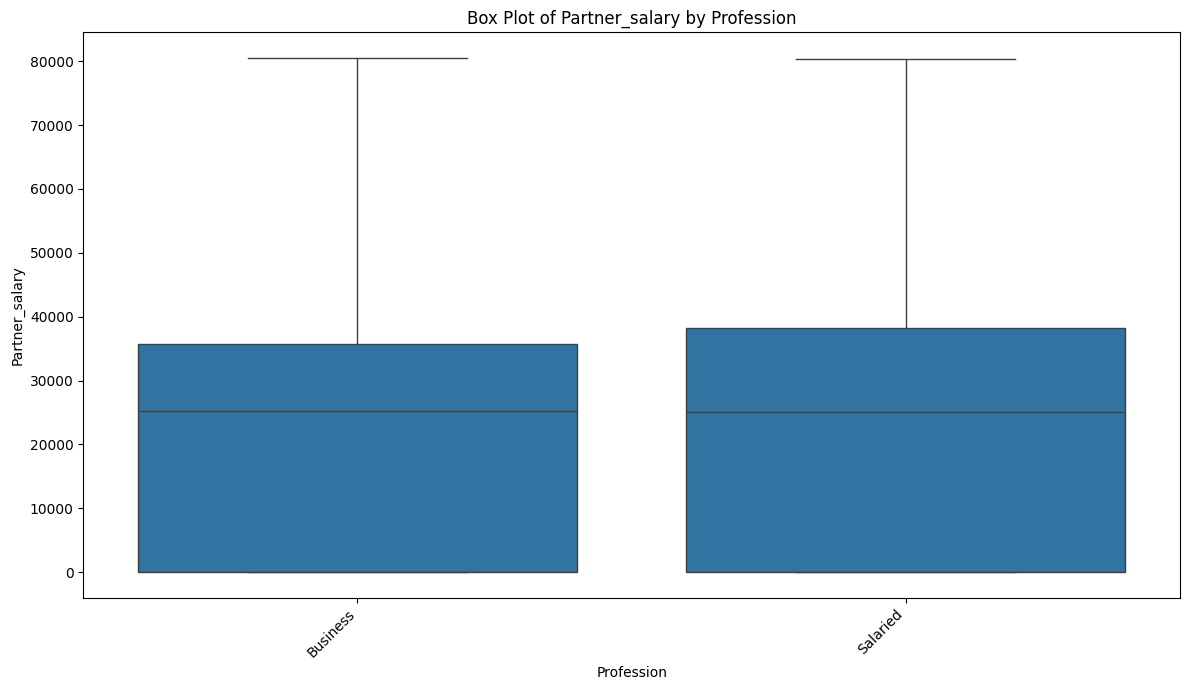

Analyzing relationship between Profession and Total_salary


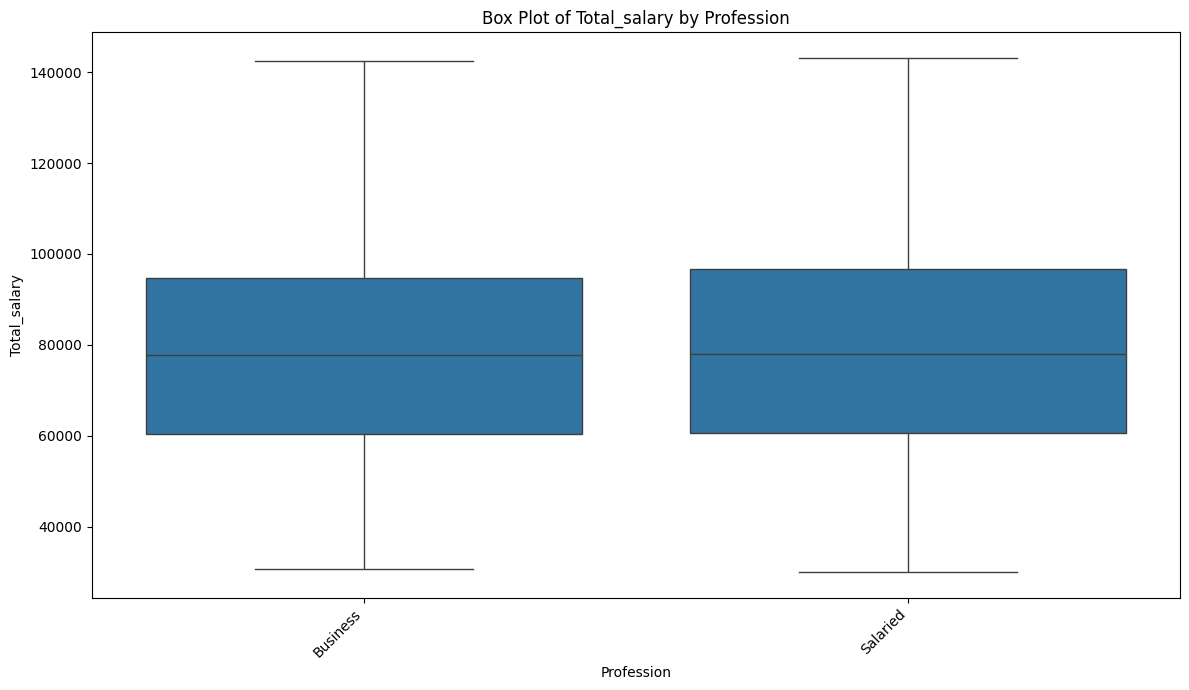

Analyzing relationship between Profession and Price


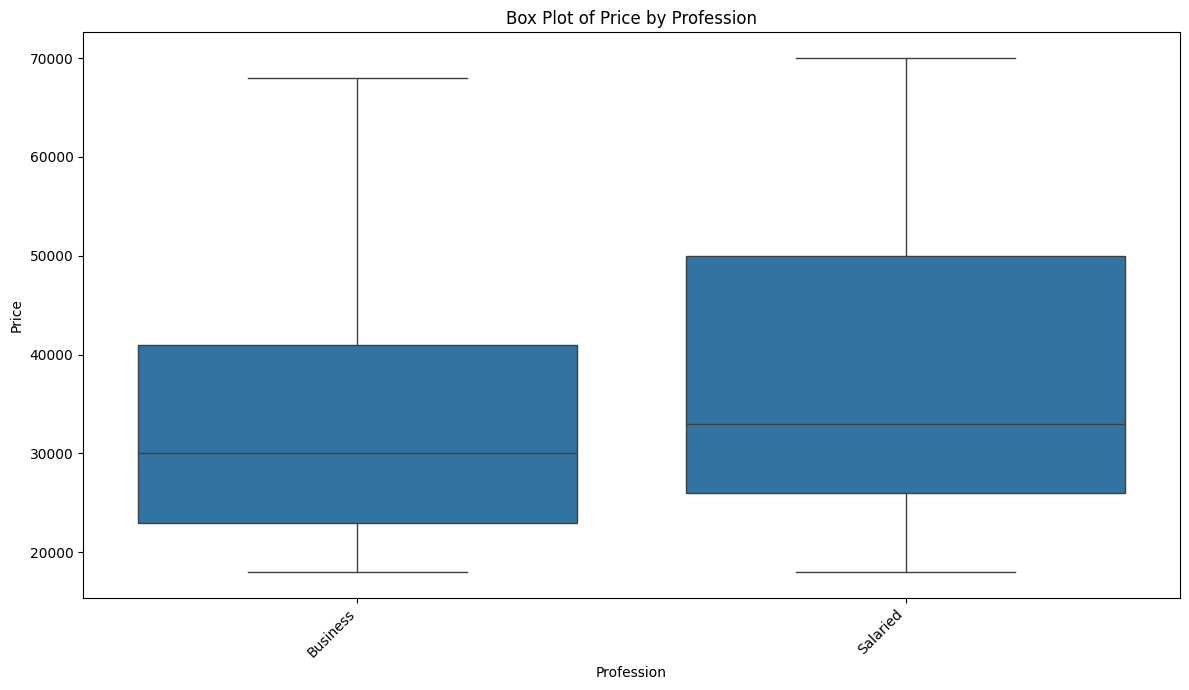

Analyzing relationship between Marital_status and Age


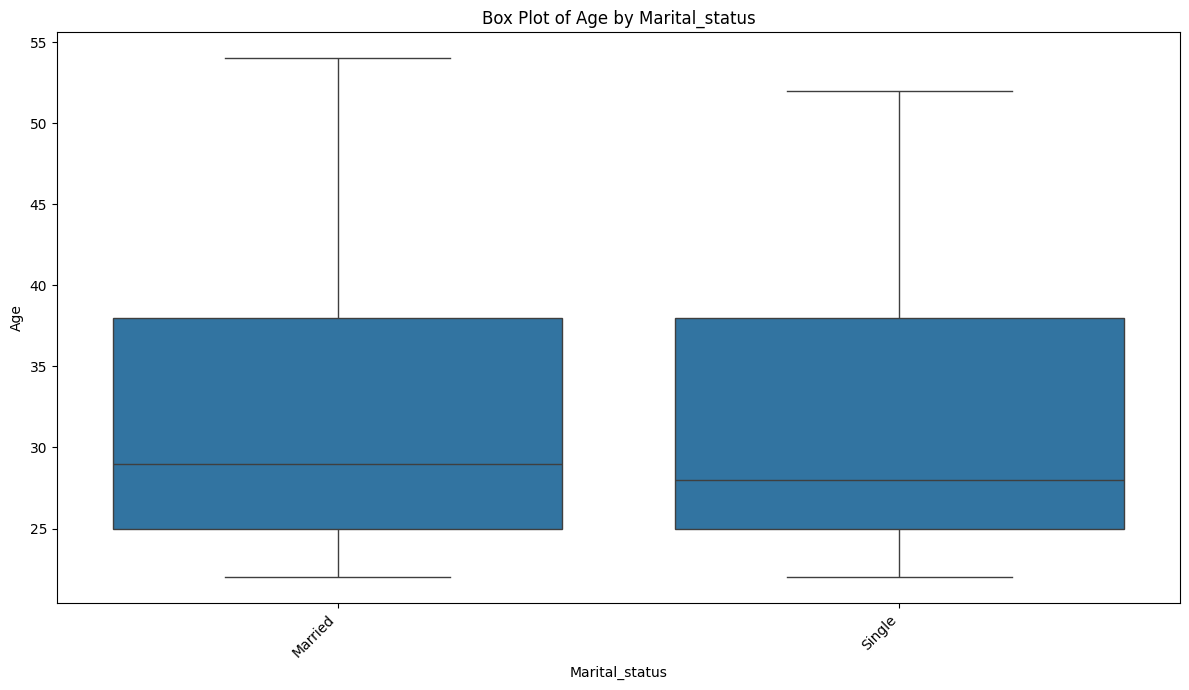

Analyzing relationship between Marital_status and Salary


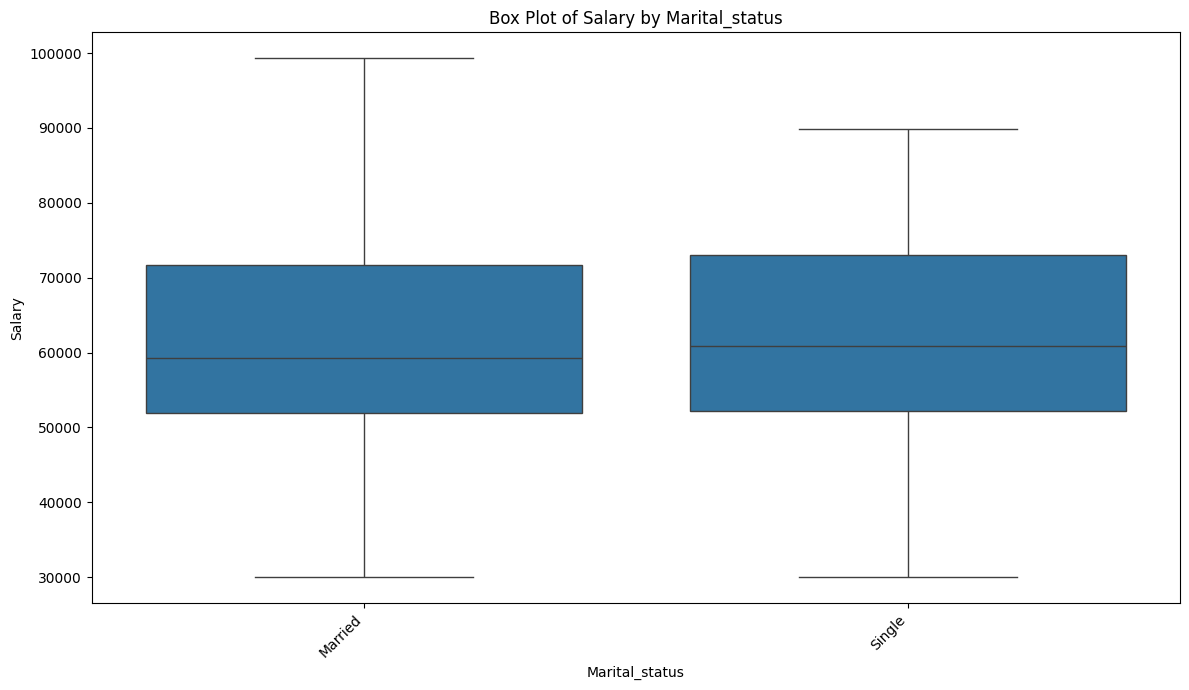

Analyzing relationship between Marital_status and Partner_salary


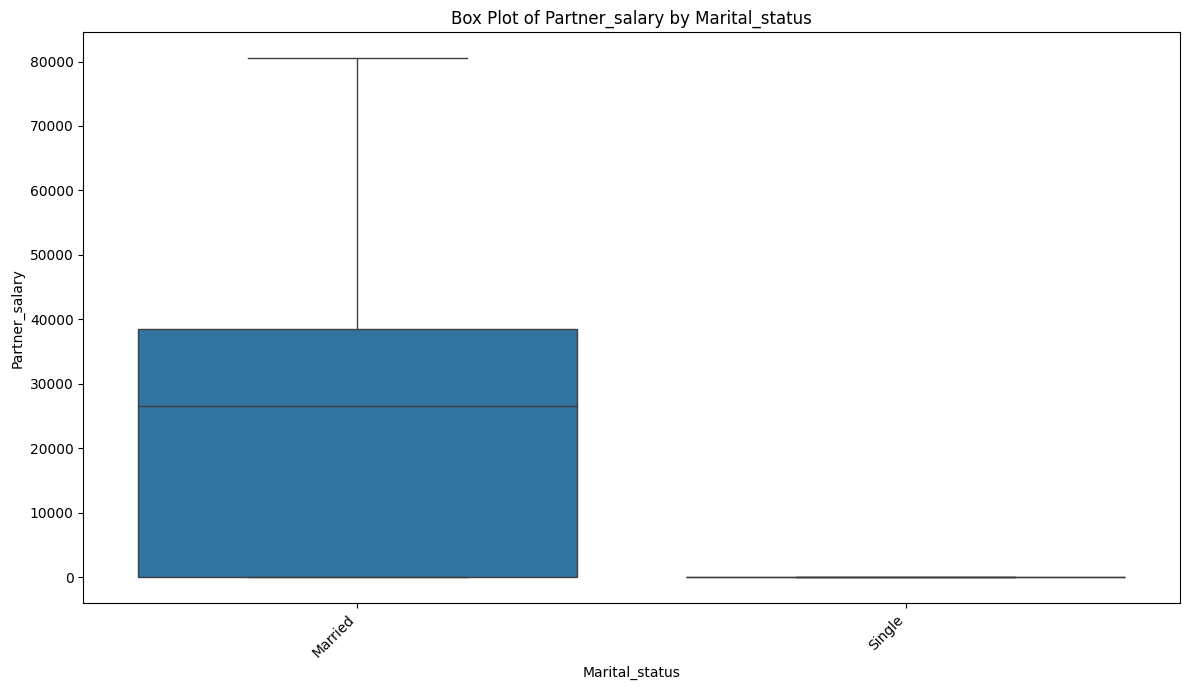

Analyzing relationship between Marital_status and Total_salary


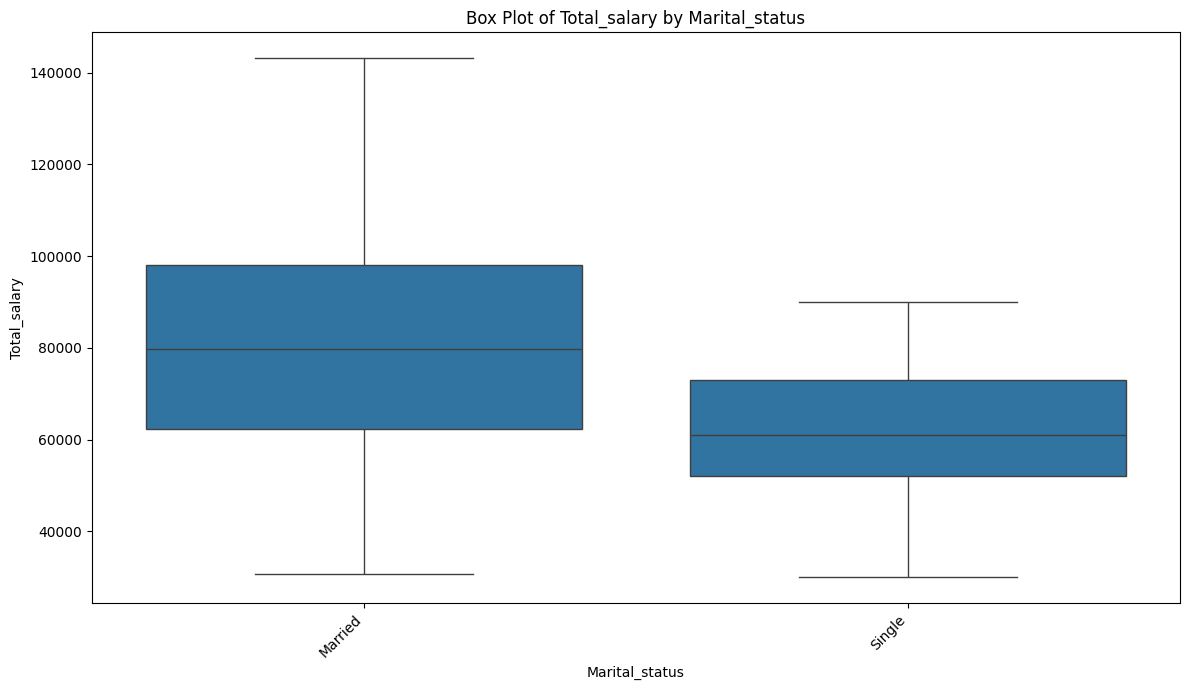

Analyzing relationship between Marital_status and Price


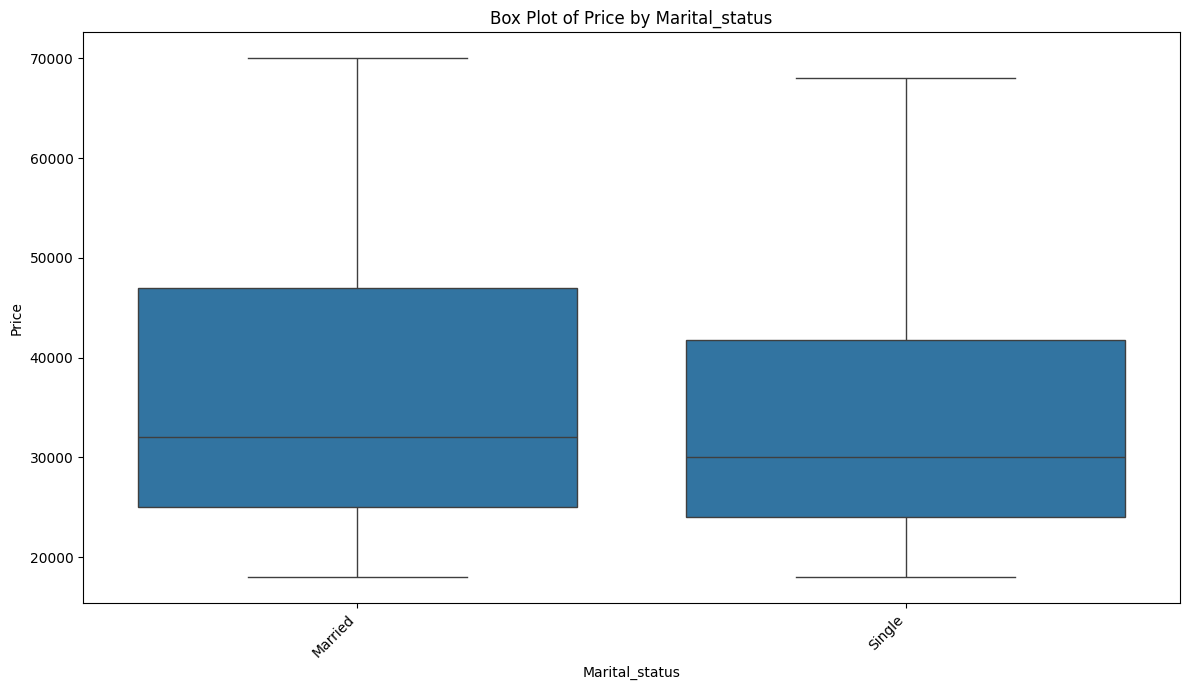

Analyzing relationship between Education and Age


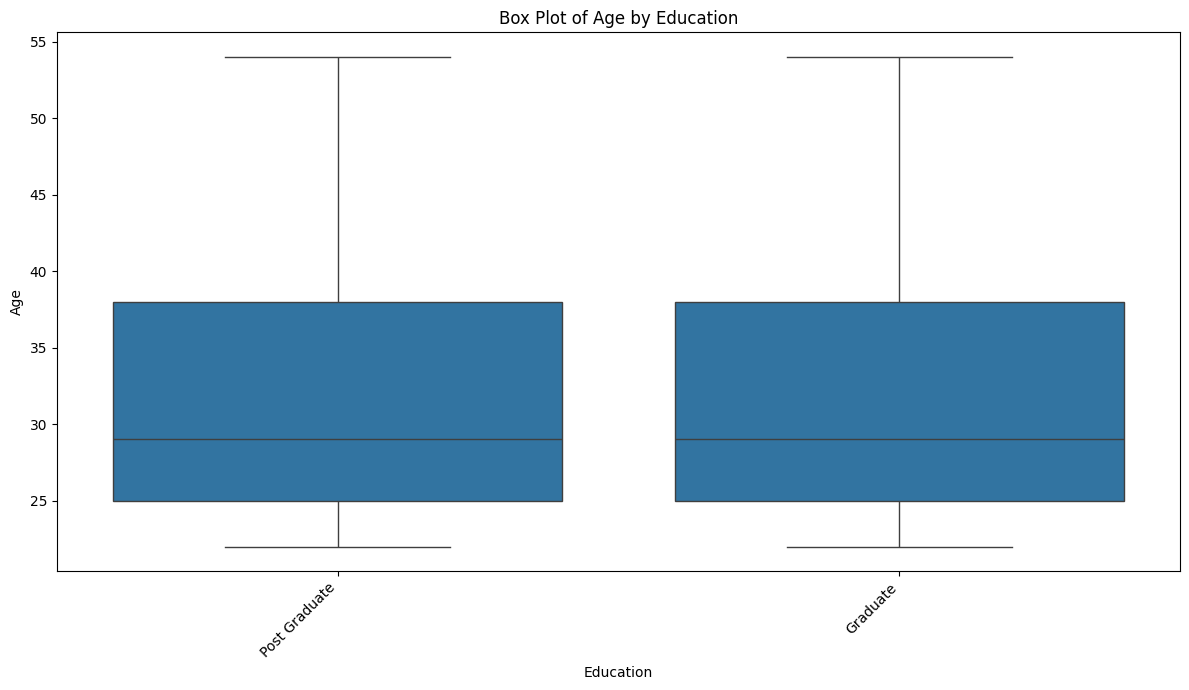

Analyzing relationship between Education and Salary


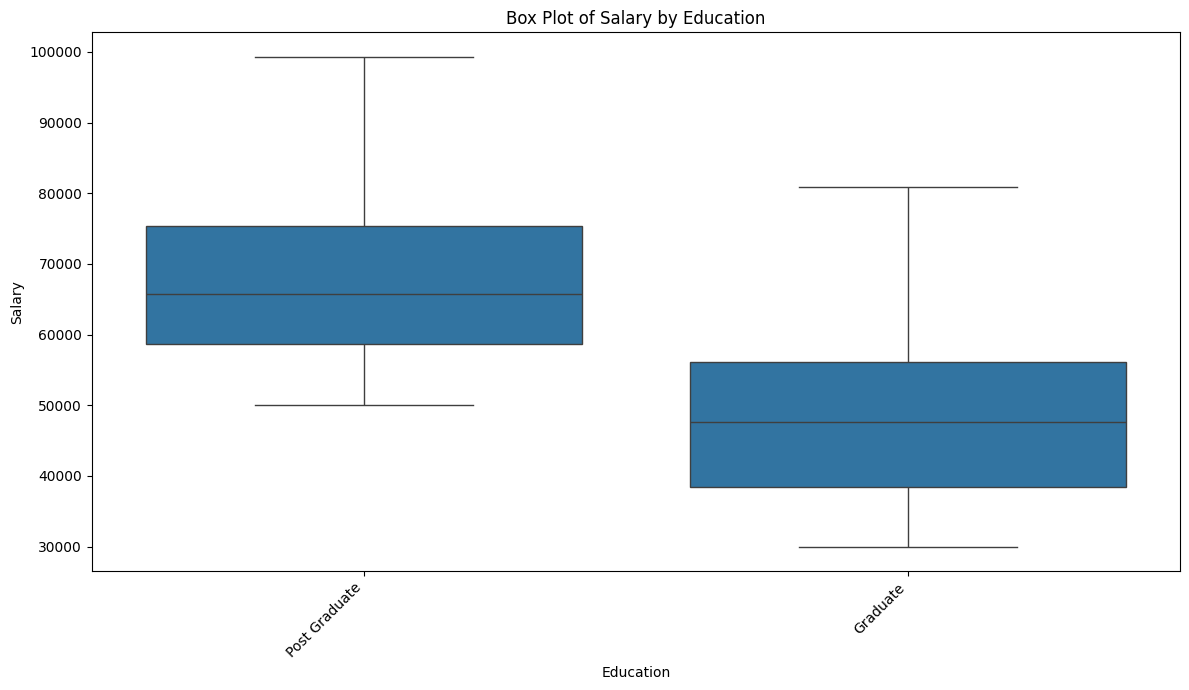

Analyzing relationship between Education and Partner_salary


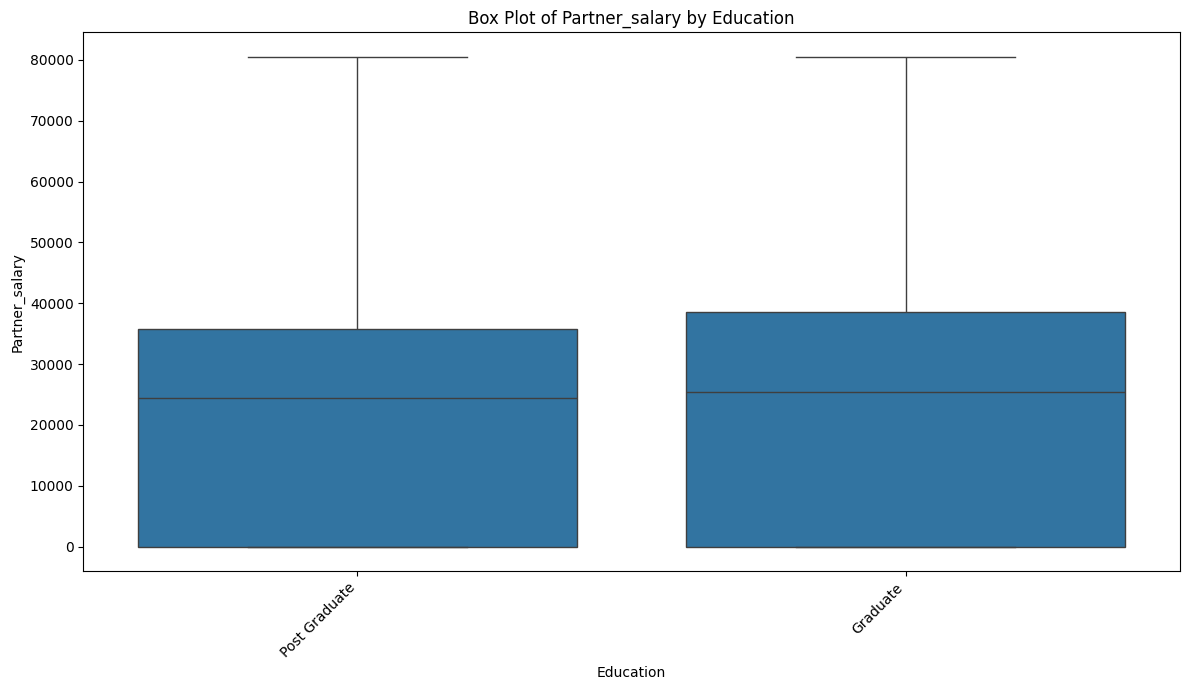

Analyzing relationship between Education and Total_salary


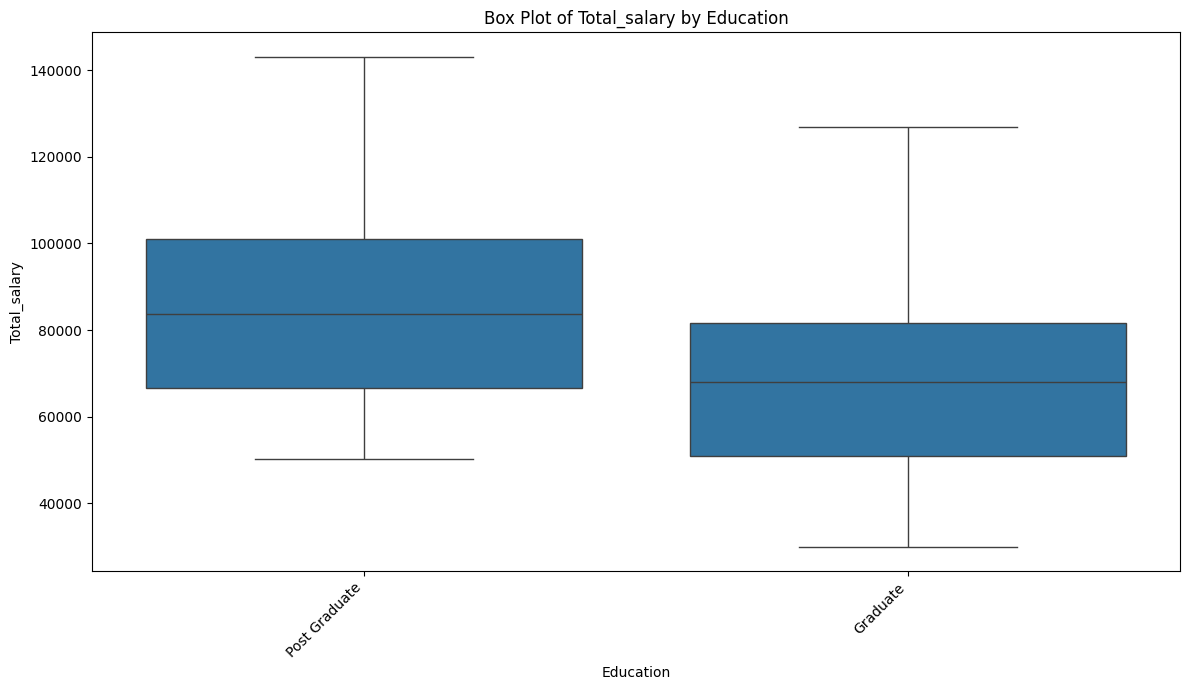

Analyzing relationship between Education and Price


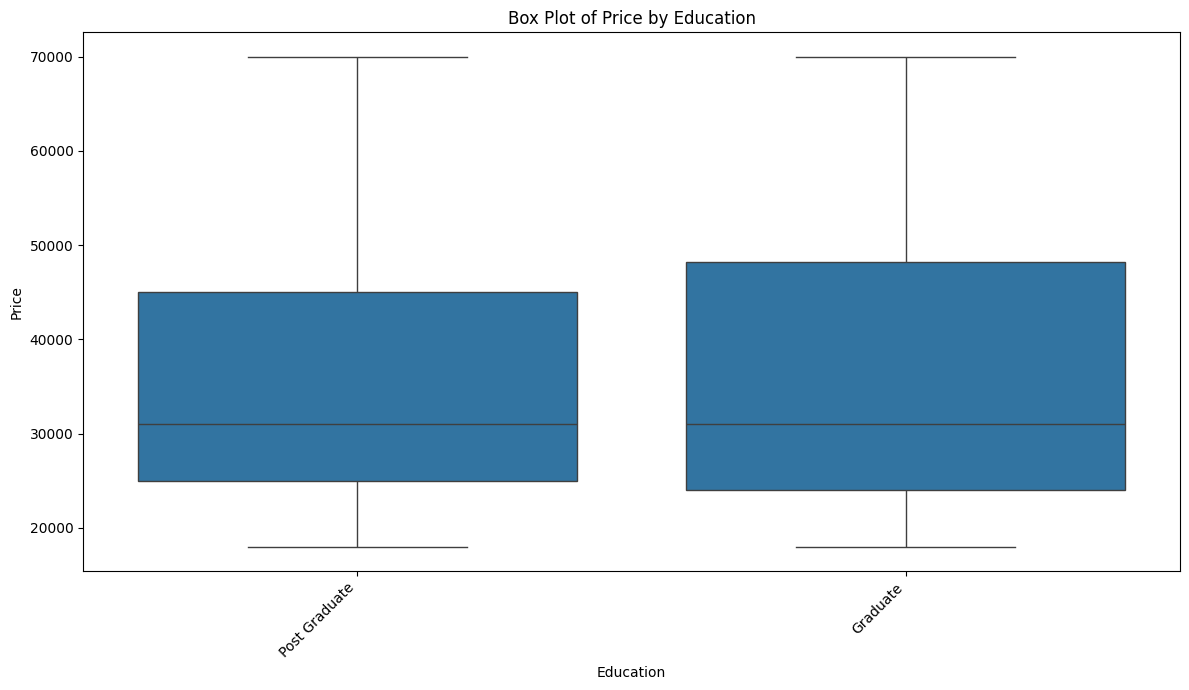

Analyzing relationship between No_of_Dependents and Age


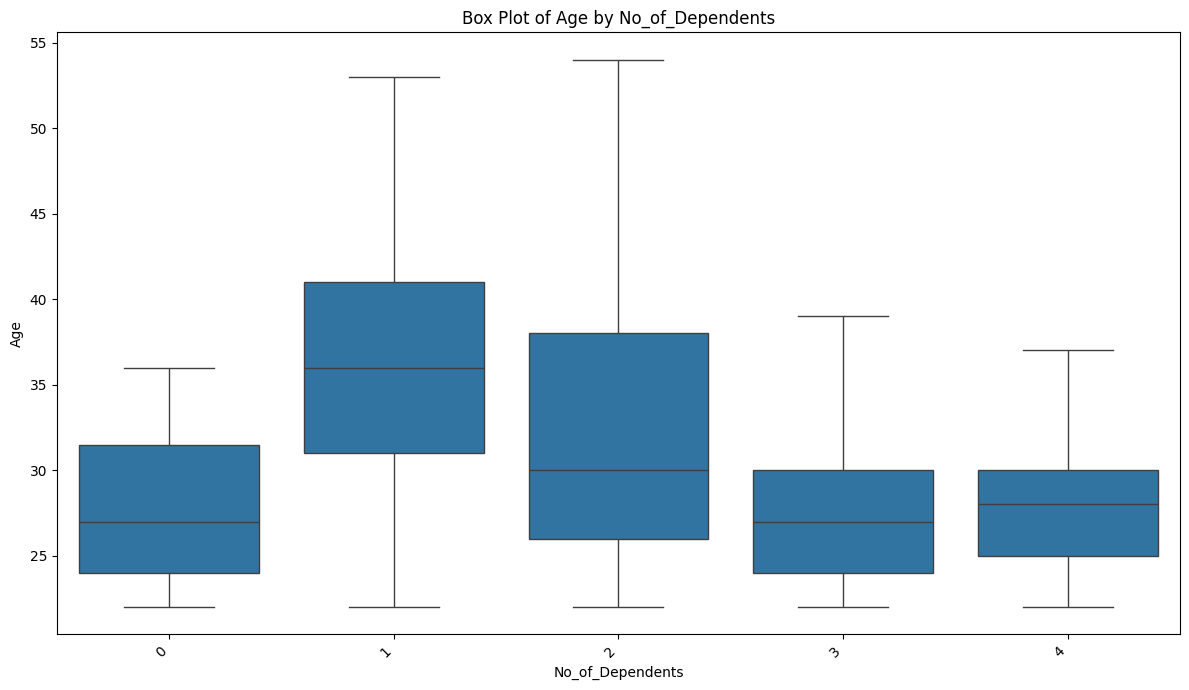

Analyzing relationship between No_of_Dependents and Salary


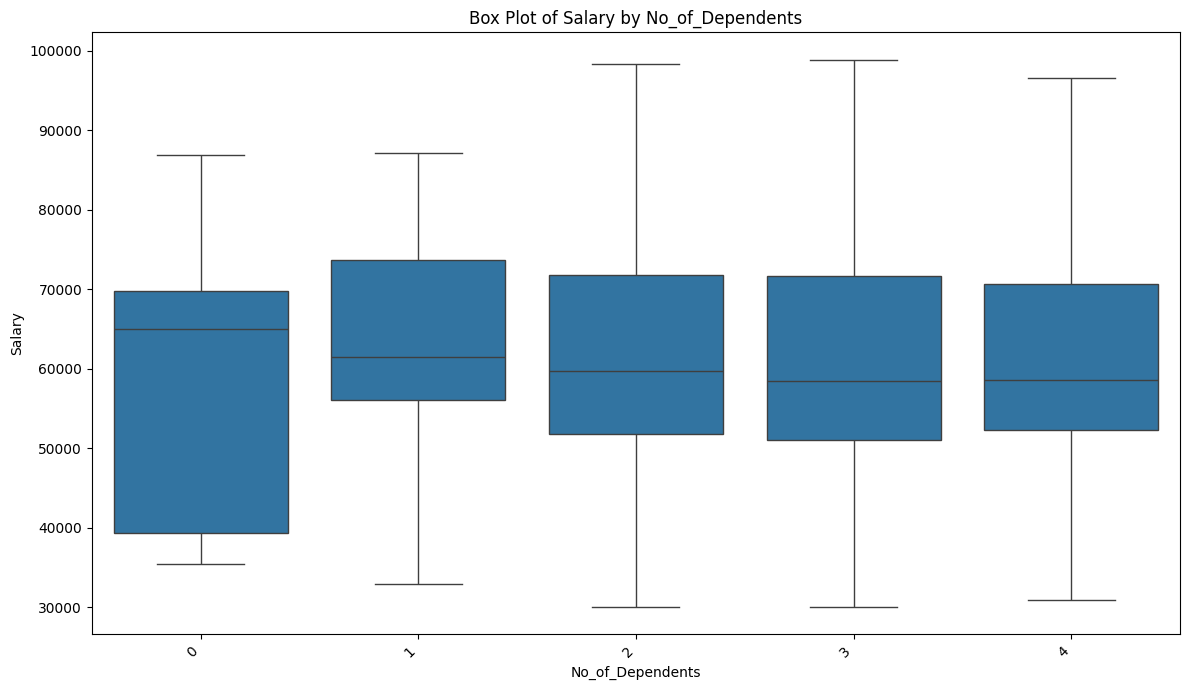

Analyzing relationship between No_of_Dependents and Partner_salary


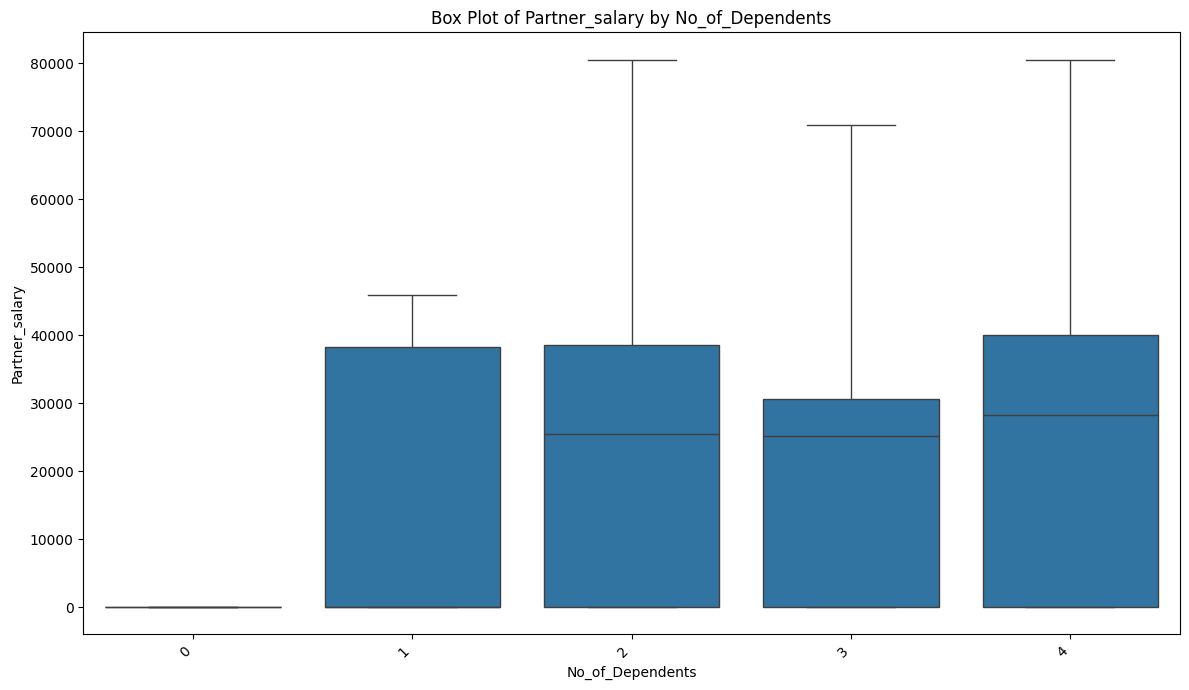

Analyzing relationship between No_of_Dependents and Total_salary


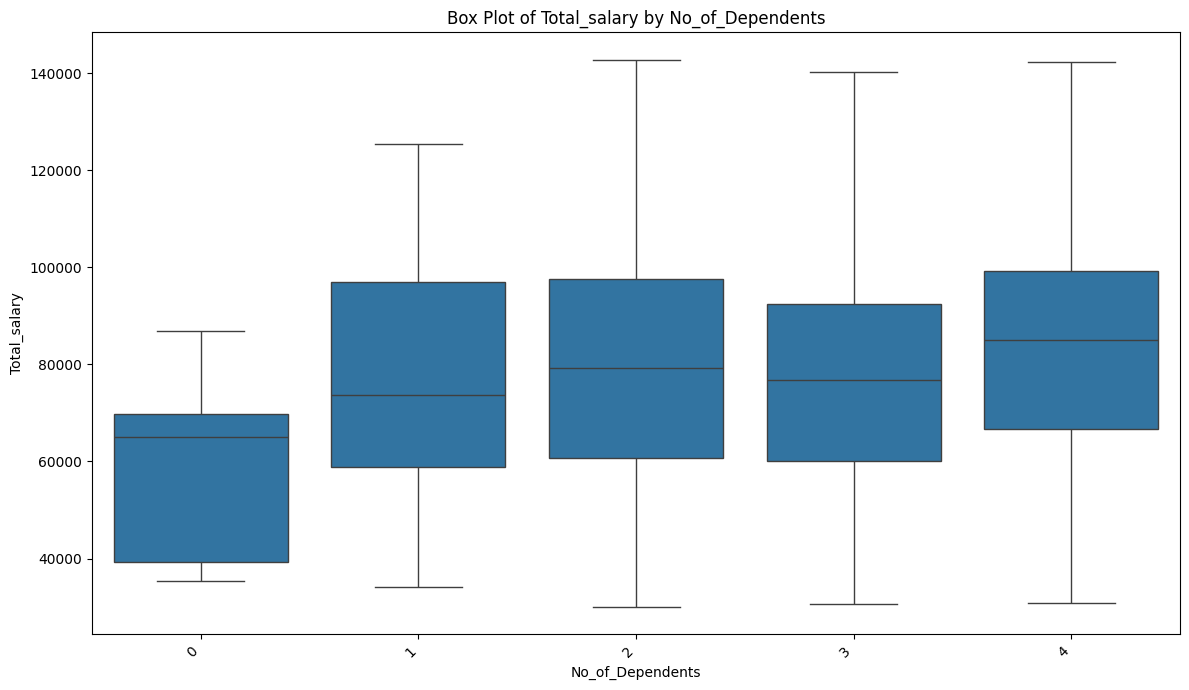

Analyzing relationship between No_of_Dependents and Price


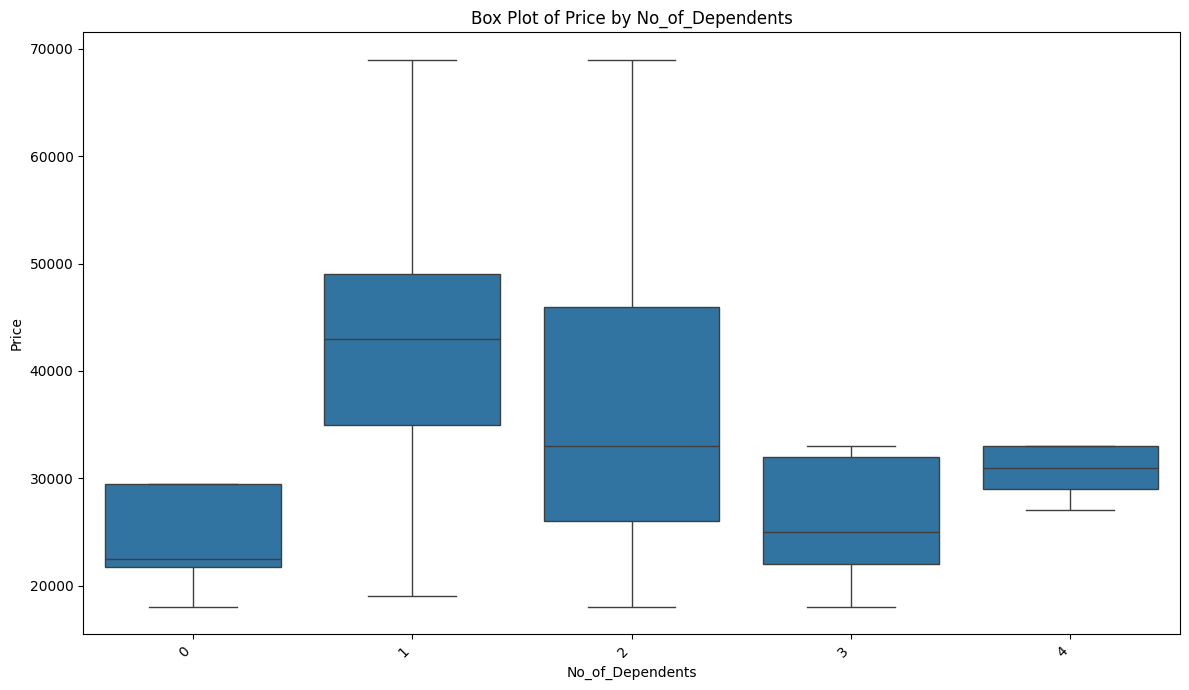

Analyzing relationship between Personal_loan and Age


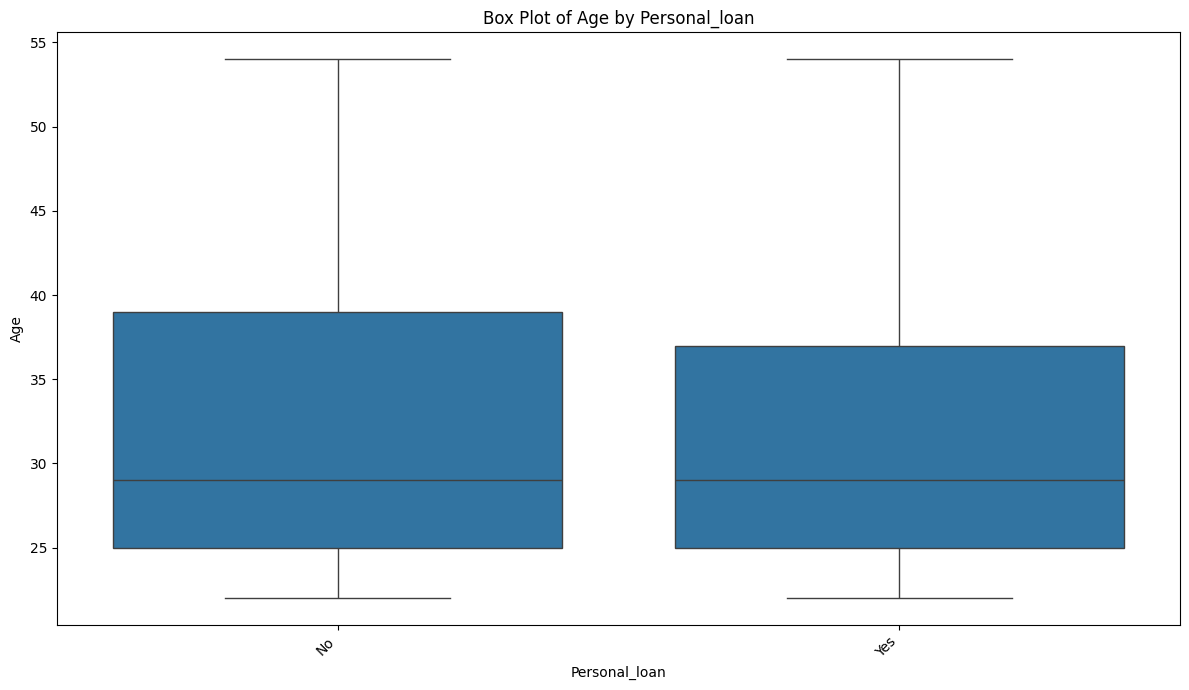

Analyzing relationship between Personal_loan and Salary


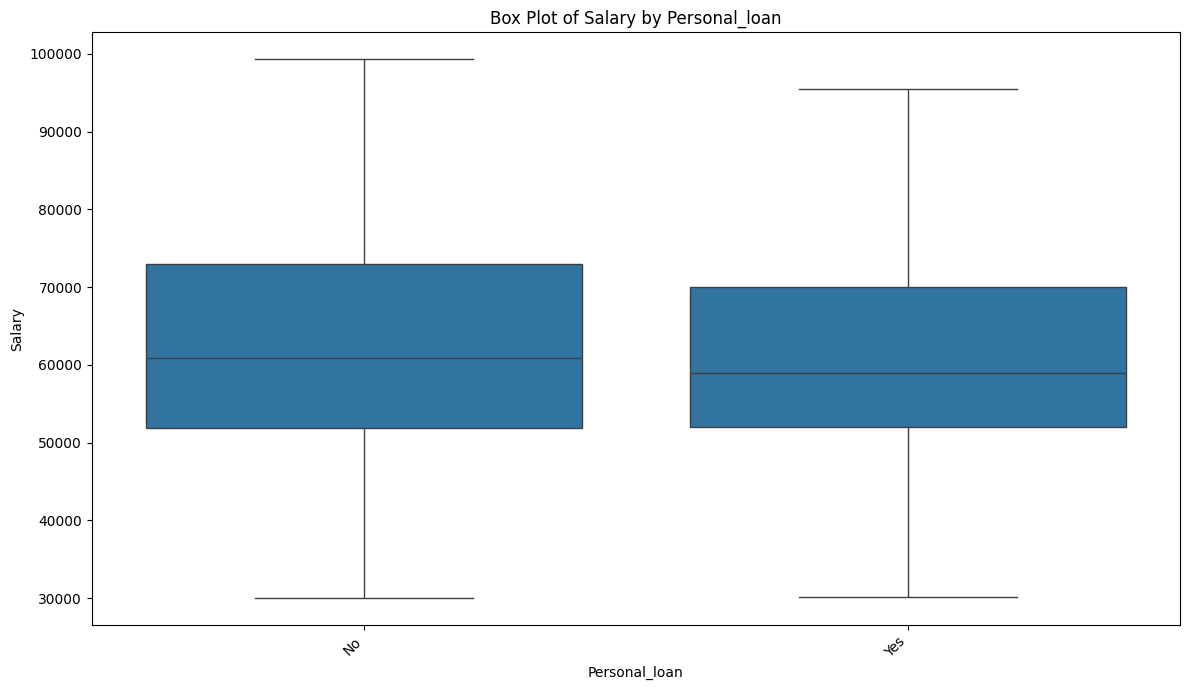

Analyzing relationship between Personal_loan and Partner_salary


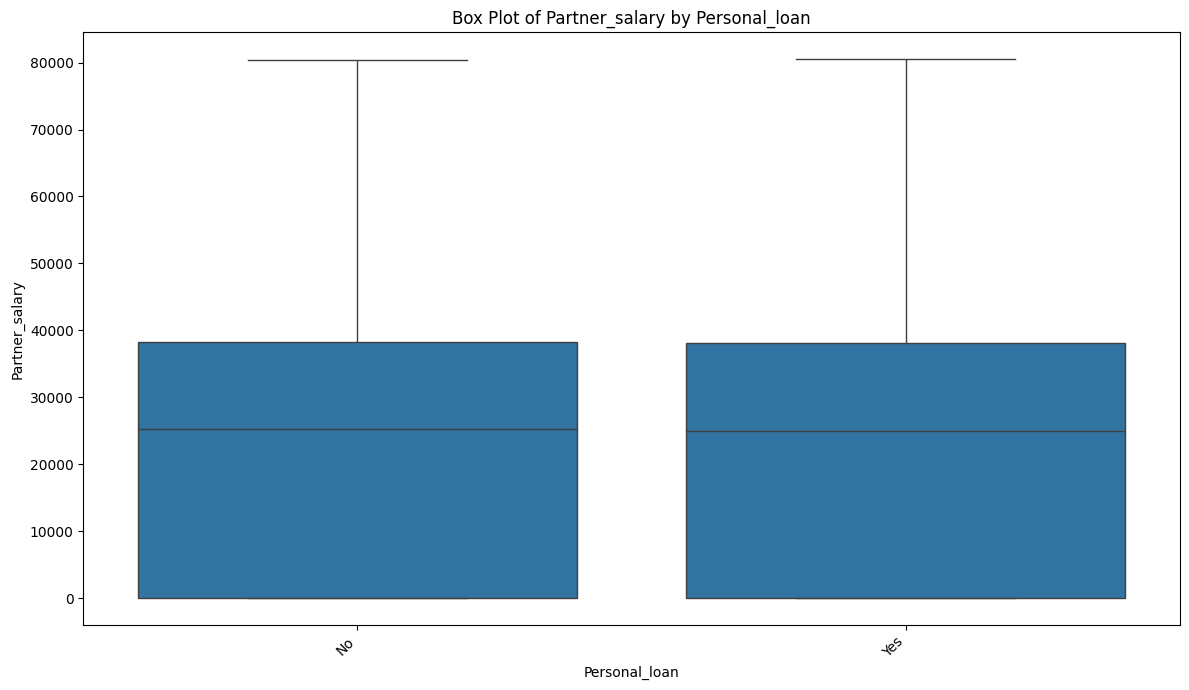

Analyzing relationship between Personal_loan and Total_salary


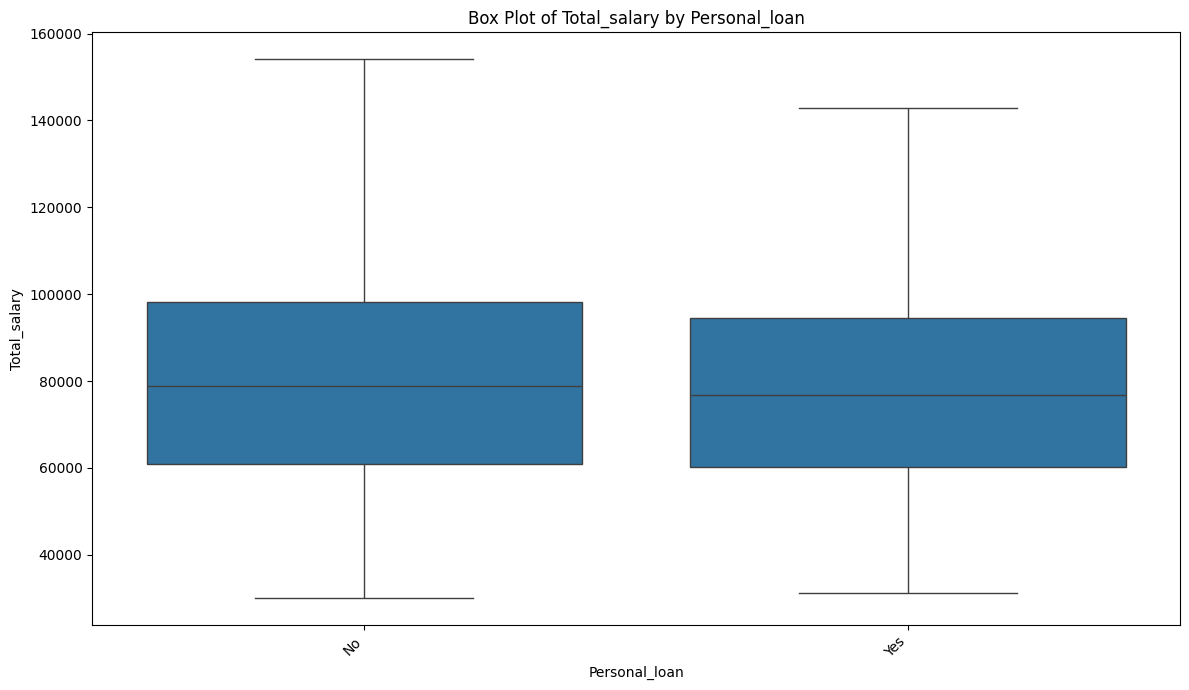

Analyzing relationship between Personal_loan and Price


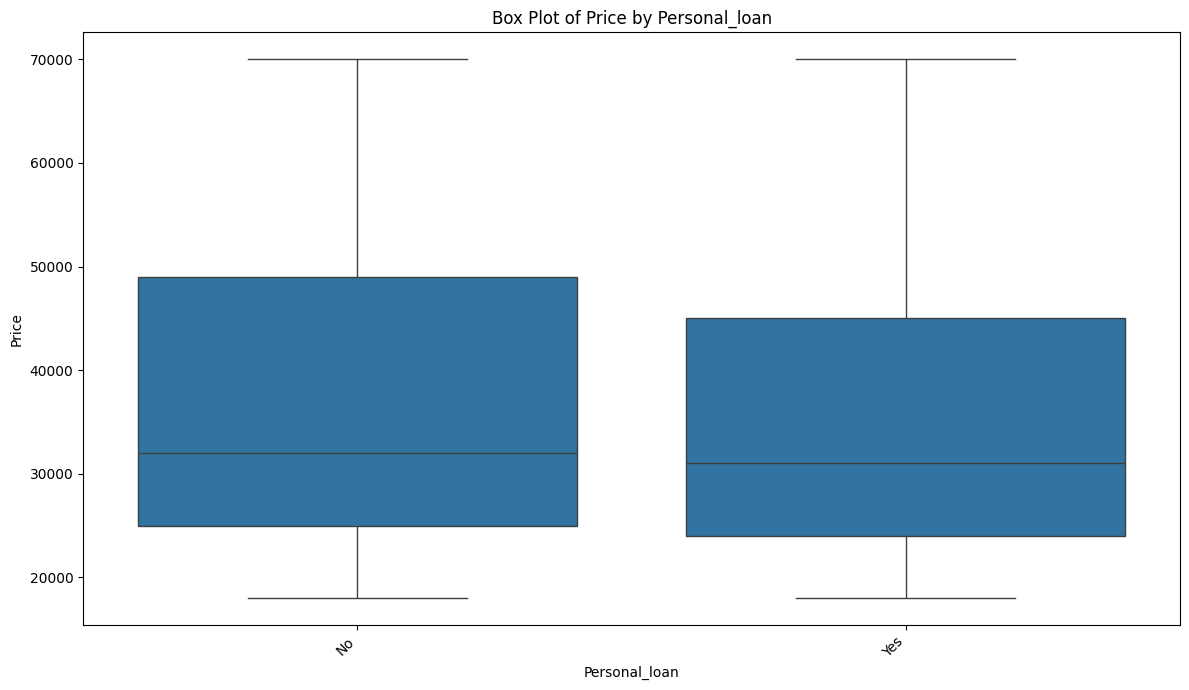

Analyzing relationship between House_loan and Age


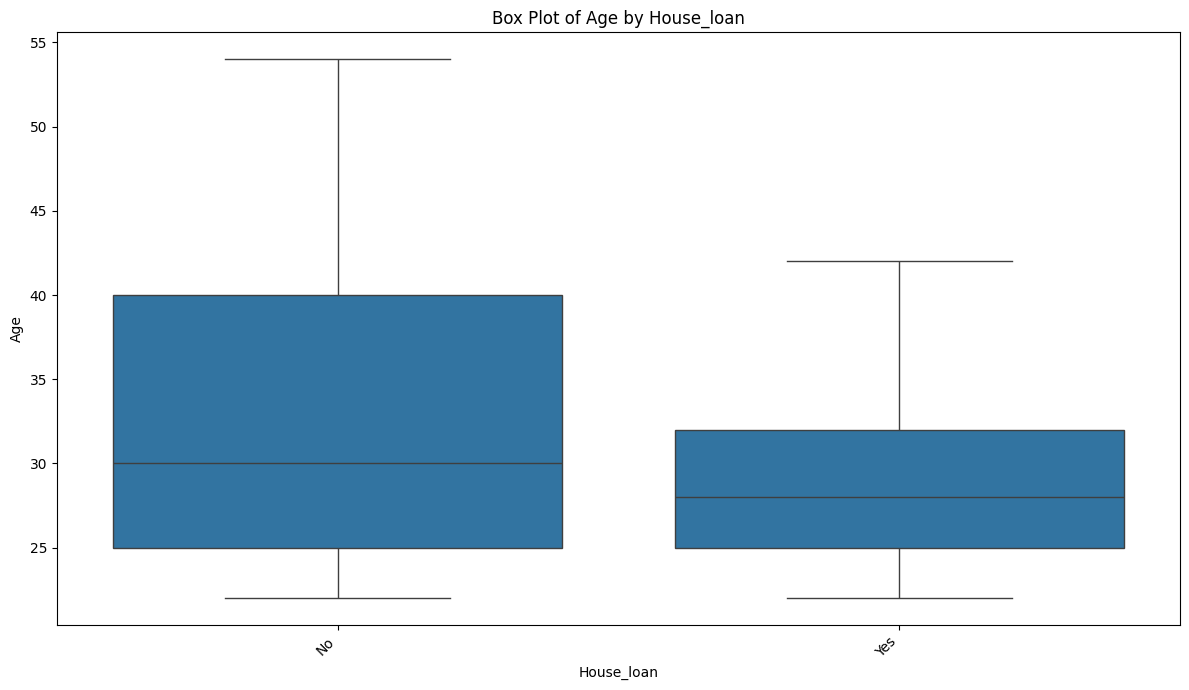

Analyzing relationship between House_loan and Salary


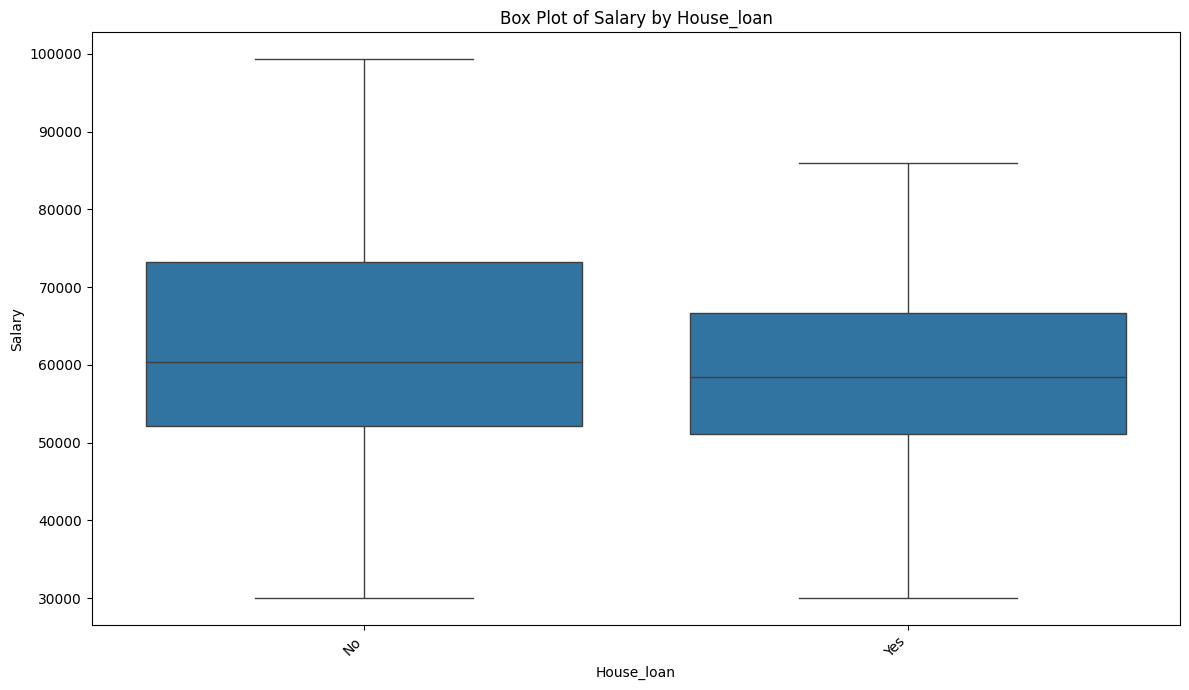

Analyzing relationship between House_loan and Partner_salary


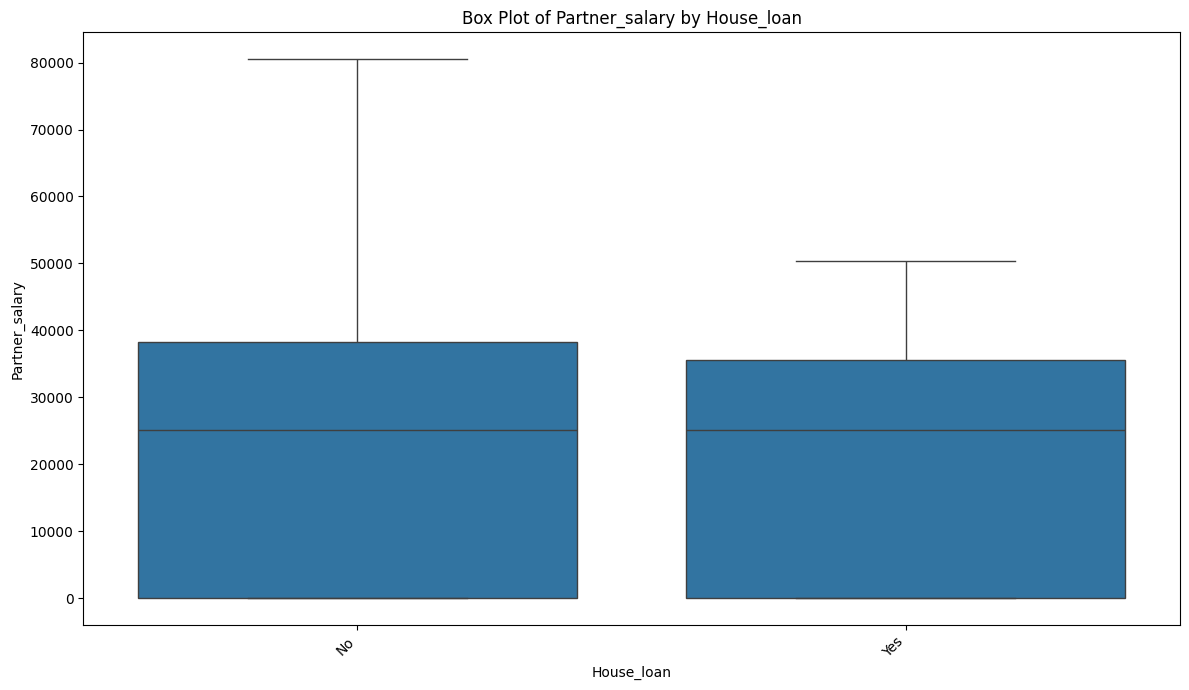

Analyzing relationship between House_loan and Total_salary


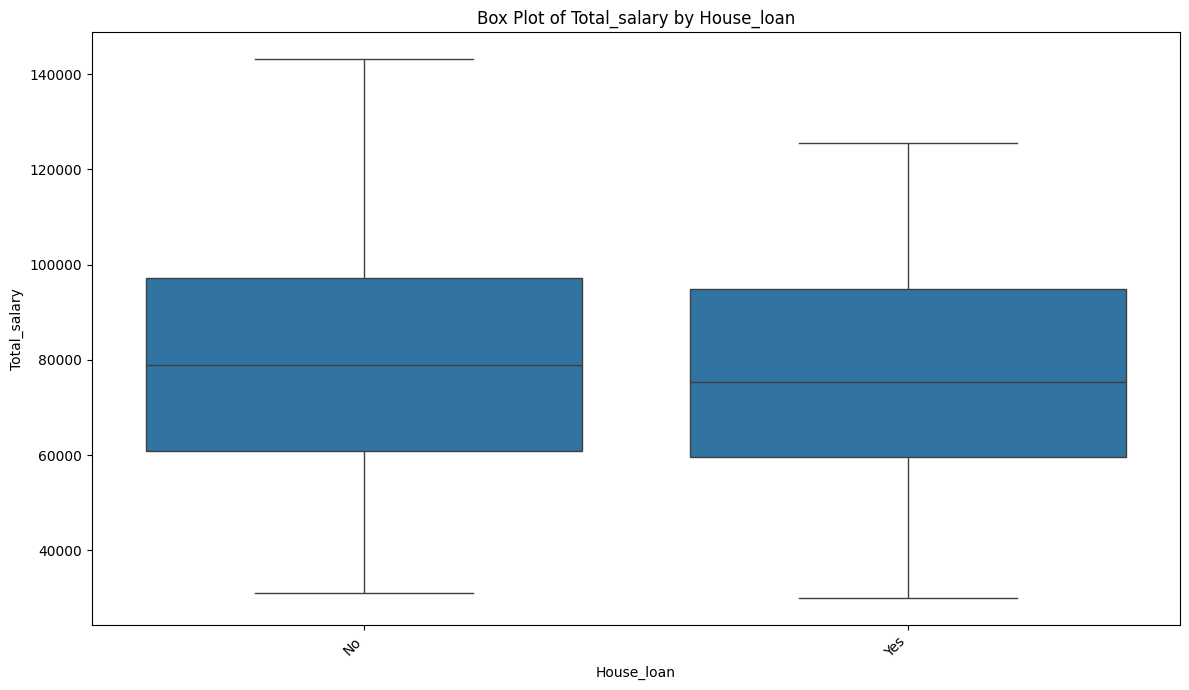

Analyzing relationship between House_loan and Price


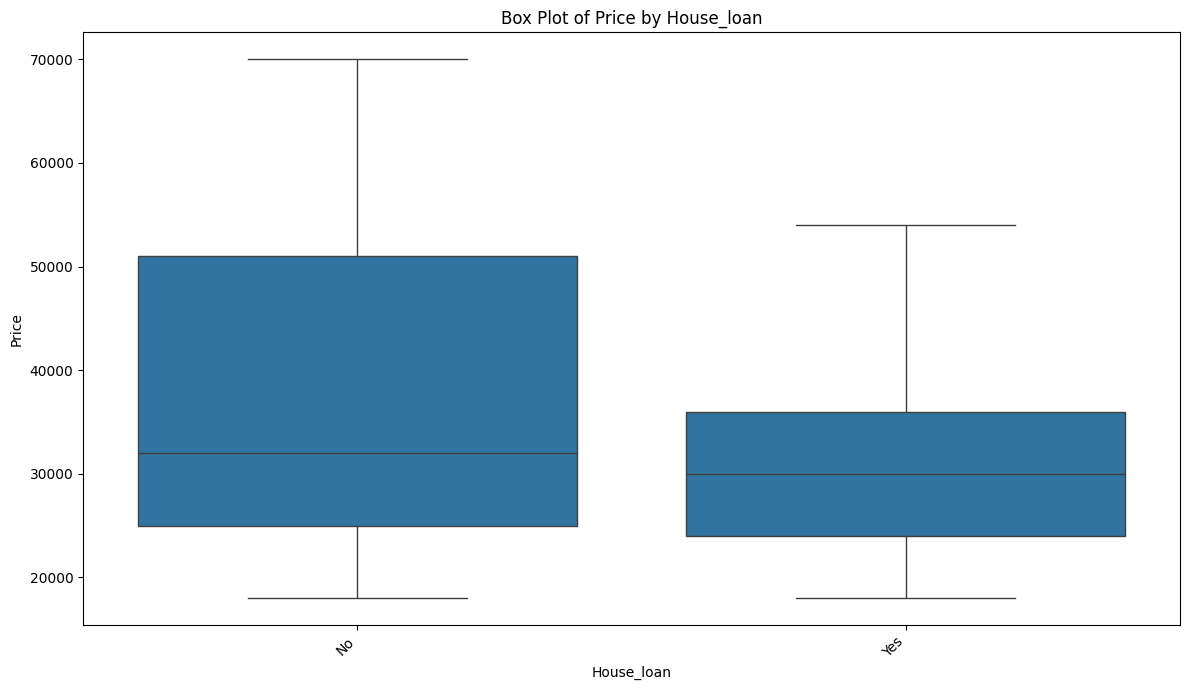

Analyzing relationship between Partner_working and Age


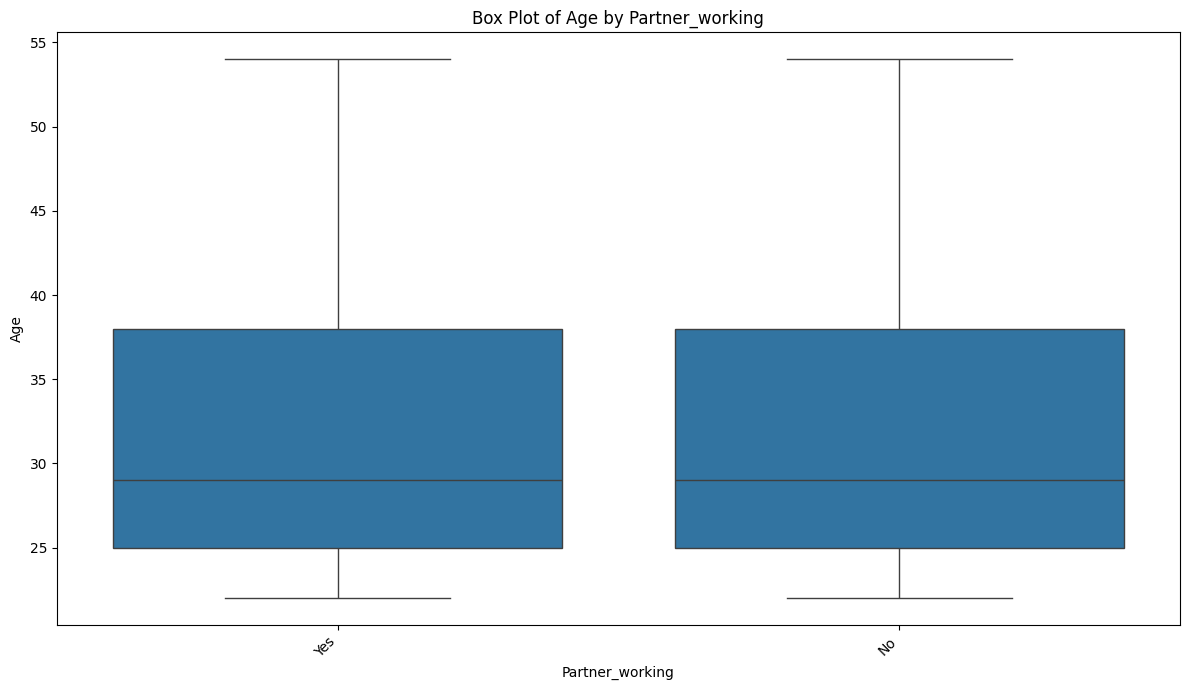

Analyzing relationship between Partner_working and Salary


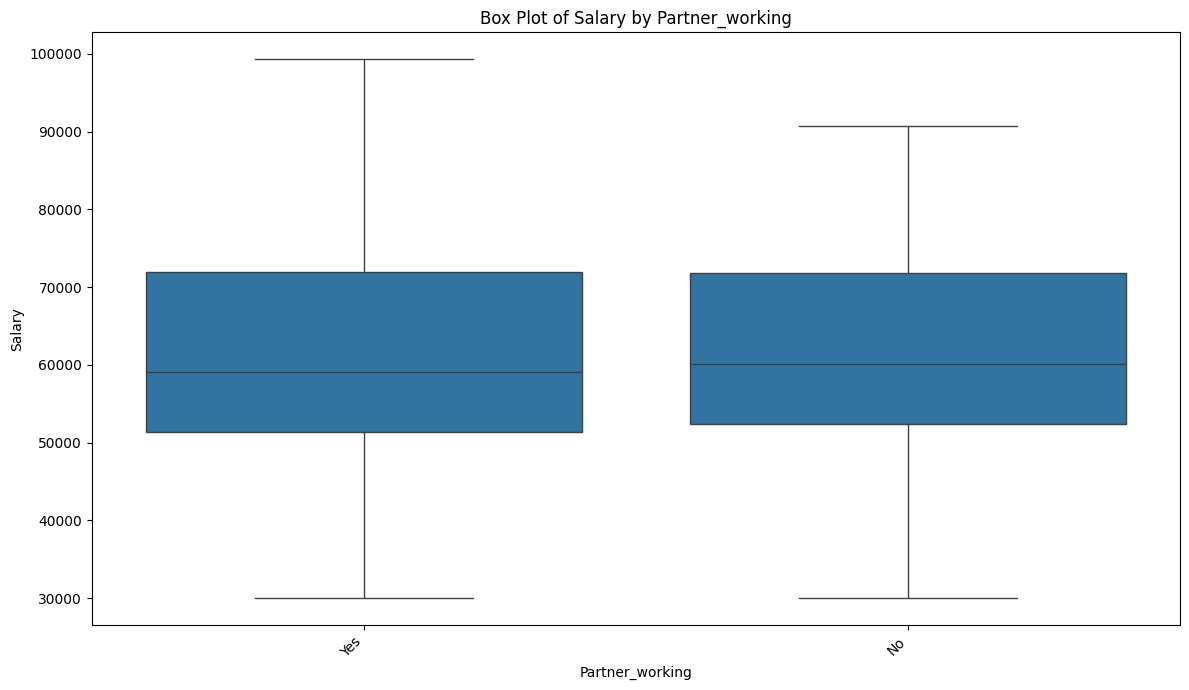

Analyzing relationship between Partner_working and Partner_salary


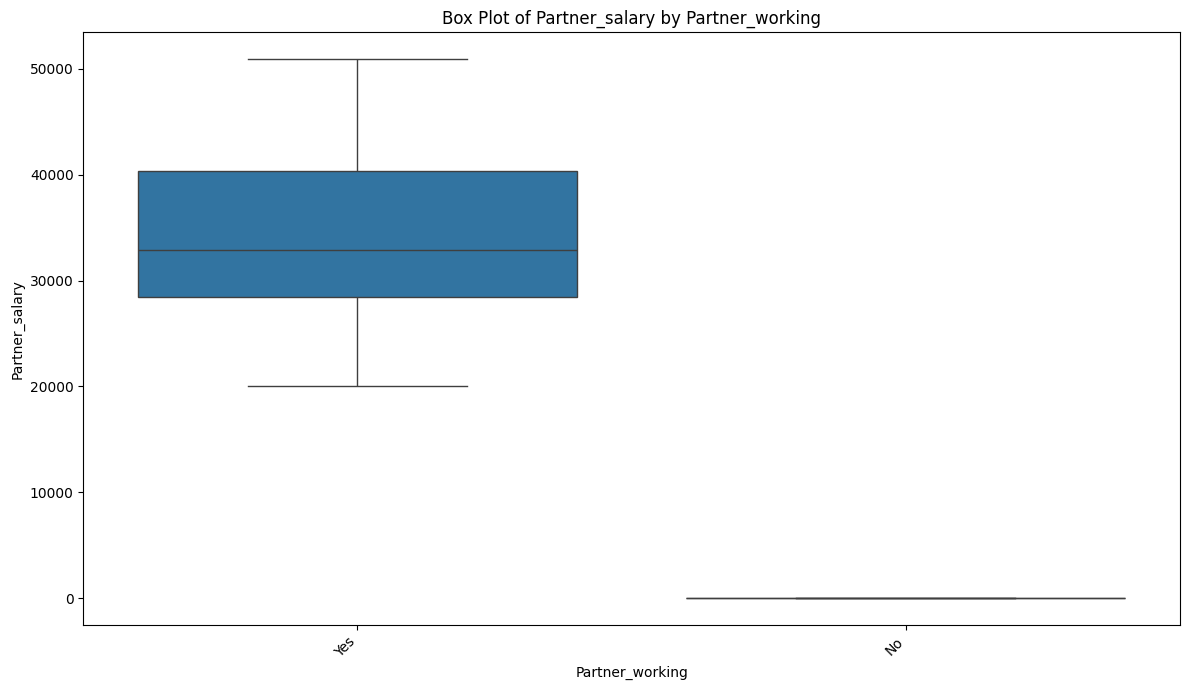

Analyzing relationship between Partner_working and Total_salary


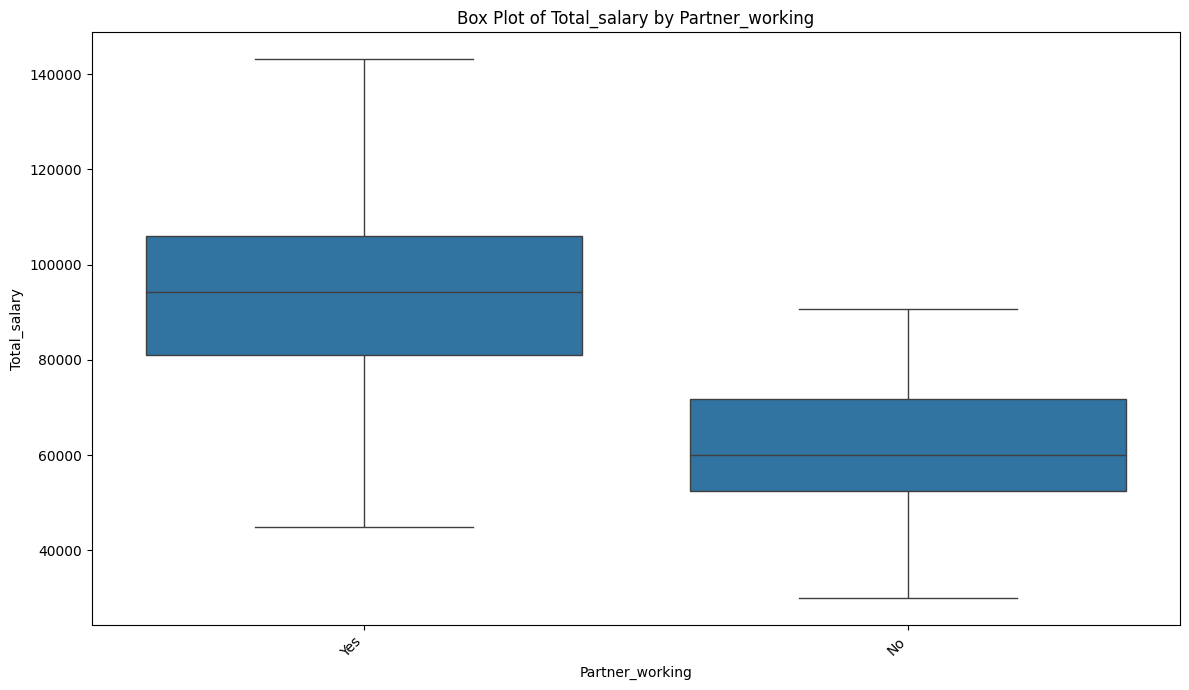

Analyzing relationship between Partner_working and Price


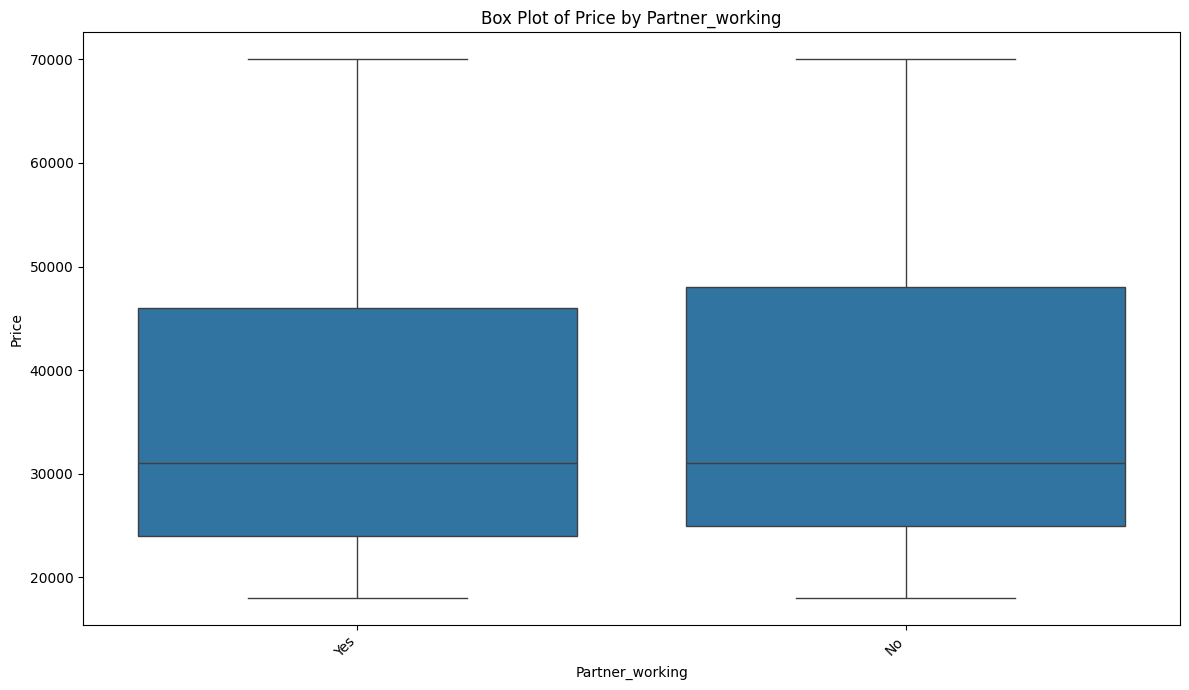

Analyzing relationship between Make and Age


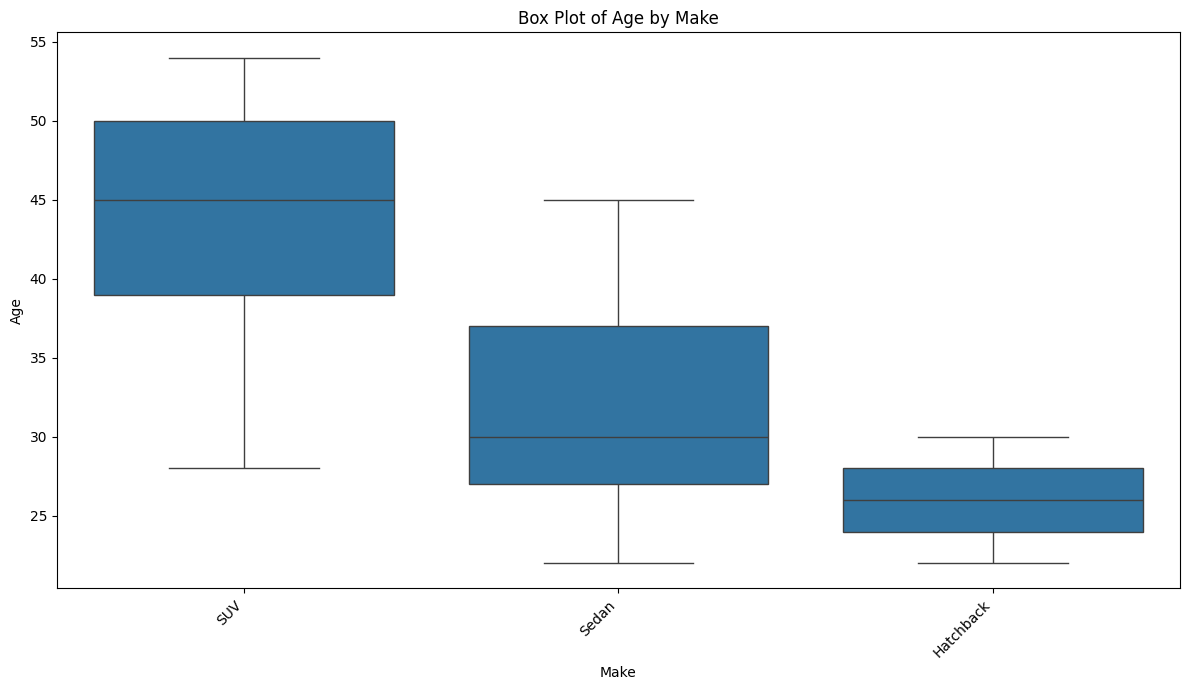

Analyzing relationship between Make and Salary


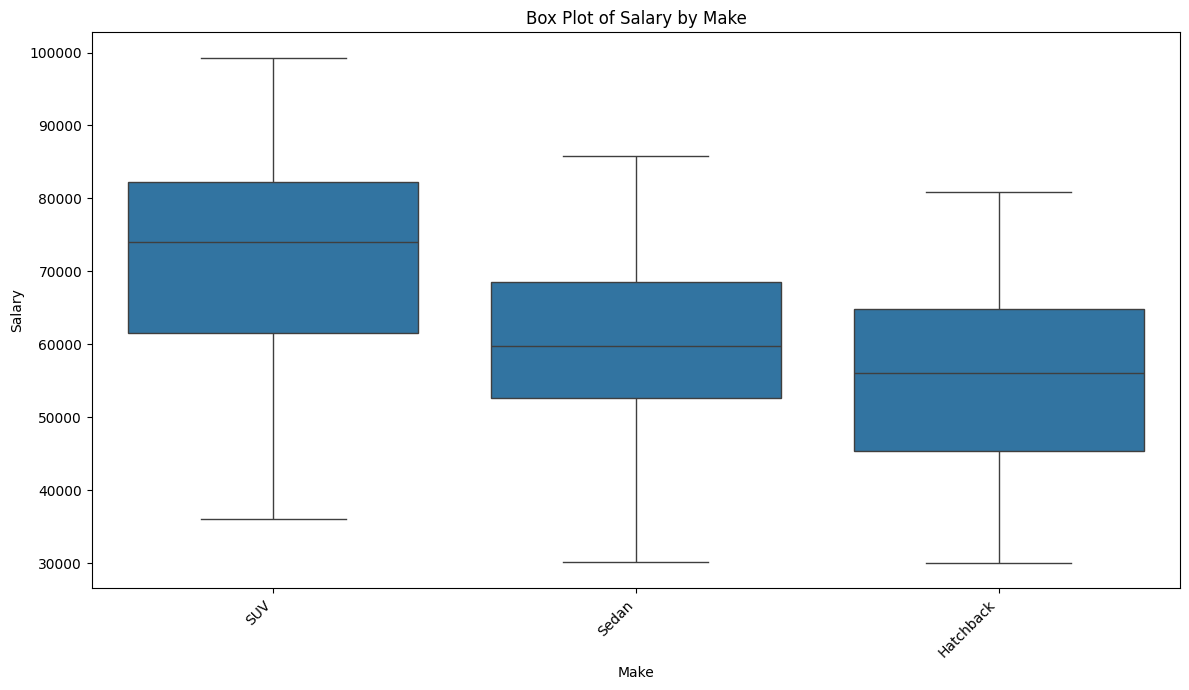

Analyzing relationship between Make and Partner_salary


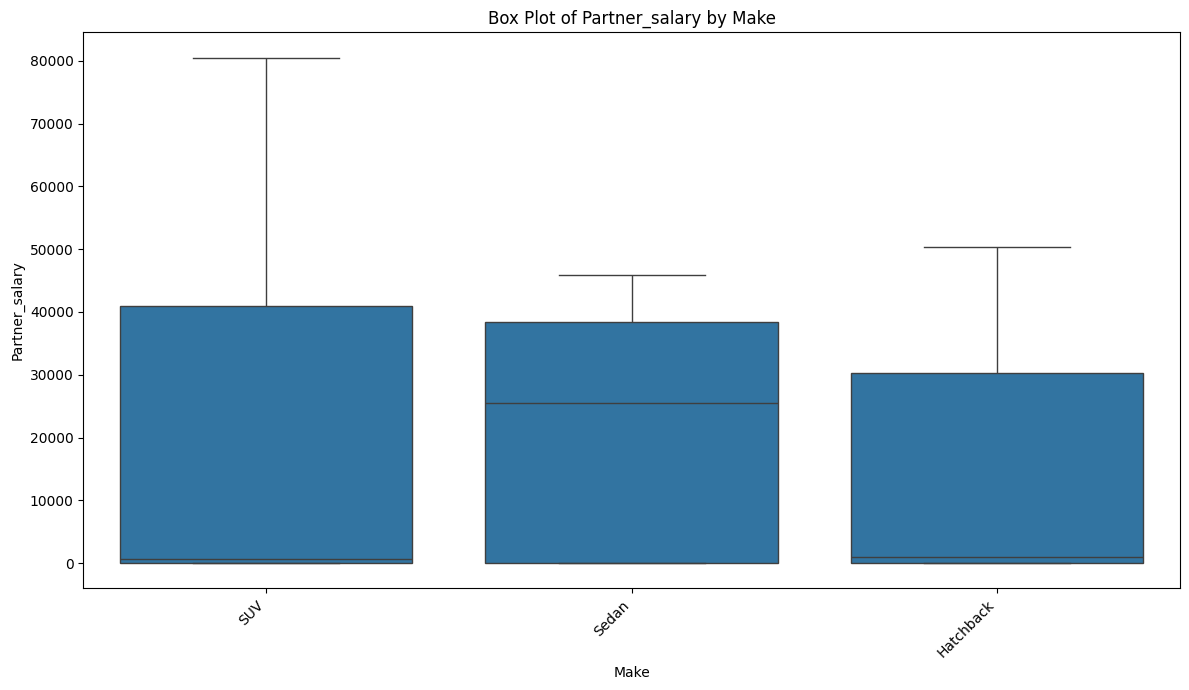

Analyzing relationship between Make and Total_salary


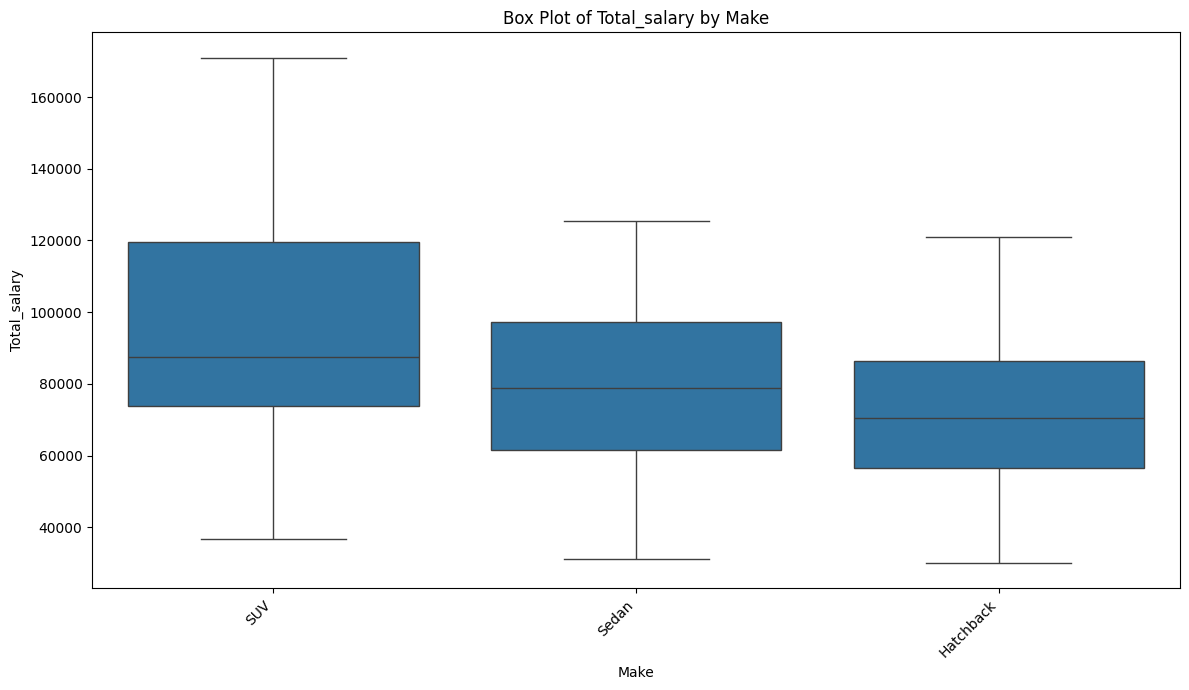

Analyzing relationship between Make and Price


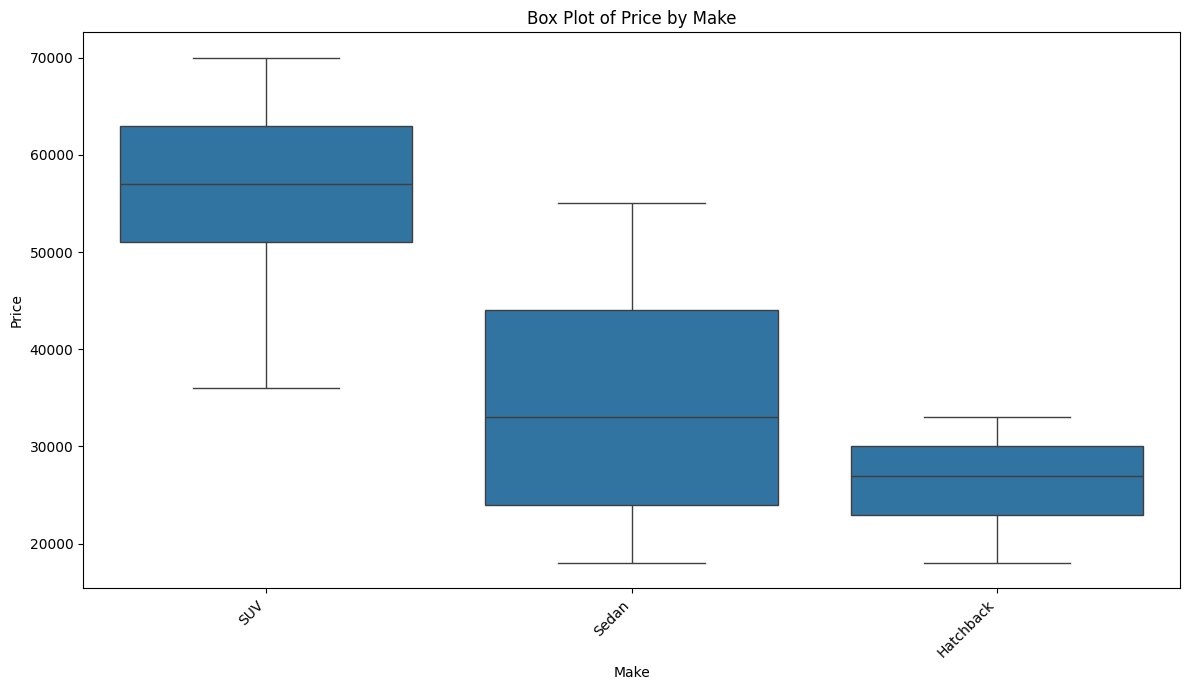

In [51]:
for cat_col in cat:
    for num_col in nums:
        print(f"Analyzing relationship between {cat_col} and {num_col}")
        bivariate_analyzer.plot_numerical_categorical(numerical_col=num_col, categorical_col=cat_col, kind='boxplot', figsize=(12, 7))

### Bivariate analysis with Dependent Variable Make

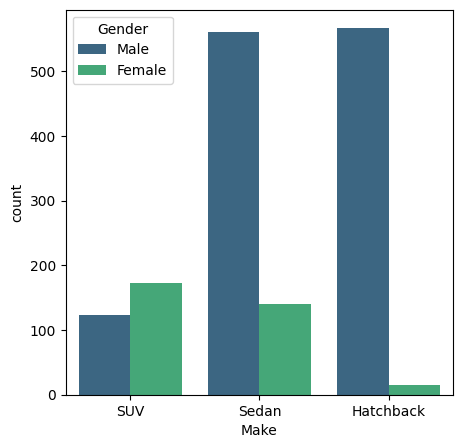

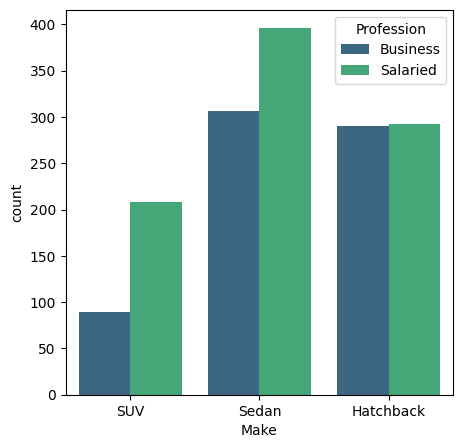

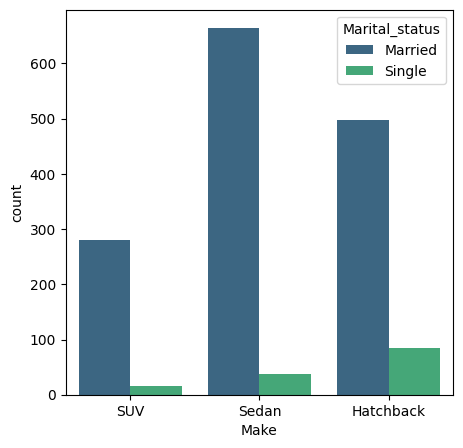

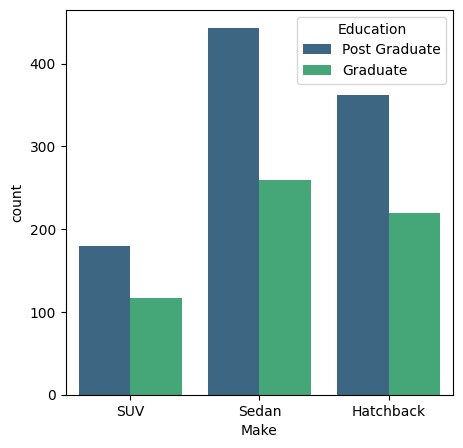

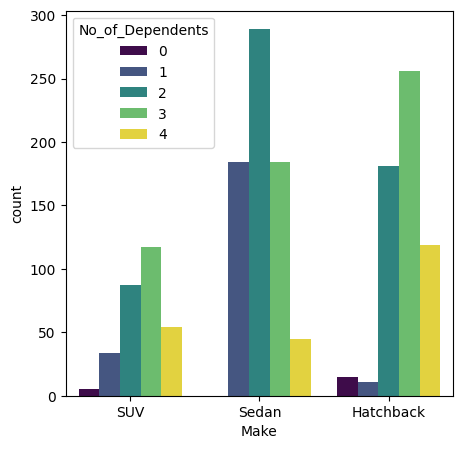

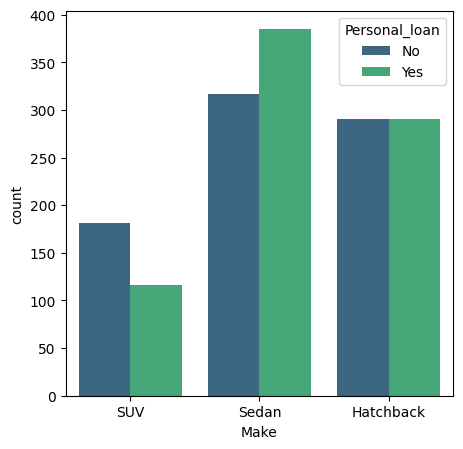

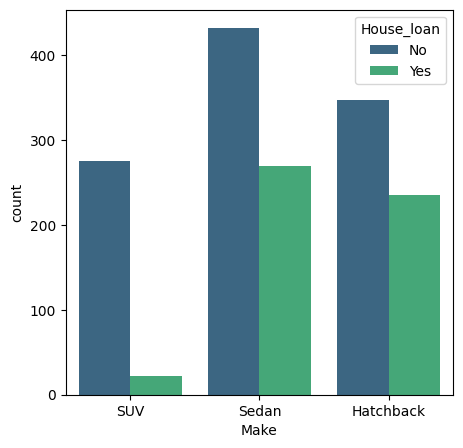

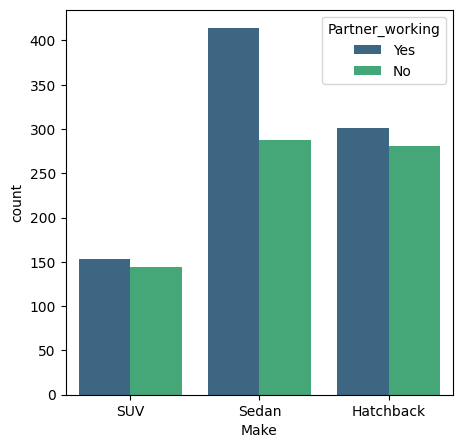

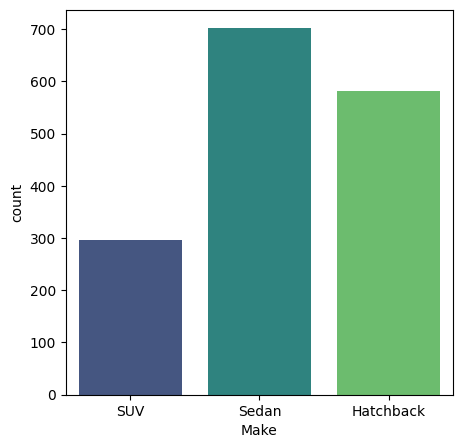

In [52]:
for i in cat:
    plt.figure(figsize=(5,5))
    sns.countplot(data=df, x = 'Make', hue = i, palette='viridis')
    plt.show()

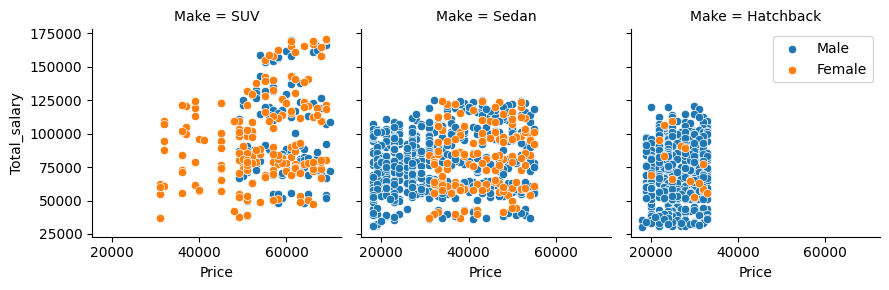

In [53]:
g = sns.FacetGrid(df, col="Make", hue="Gender", col_wrap=3)
g.map(sns.scatterplot, 'Price', 'Total_salary')
plt.legend()
plt.show()

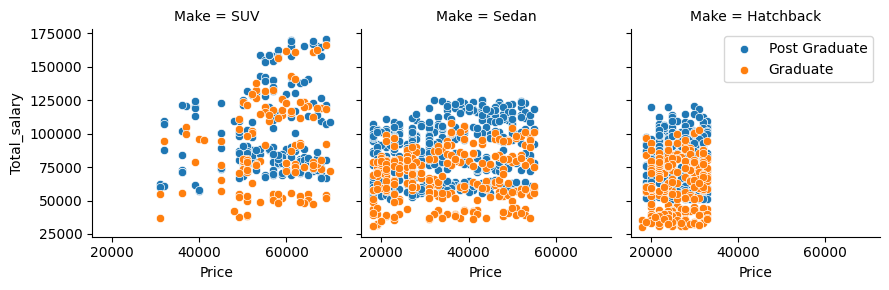

In [54]:
g = sns.FacetGrid(df, col="Make", hue="Education", col_wrap=3)
g.map(sns.scatterplot, 'Price', 'Total_salary')
plt.legend()
plt.show()

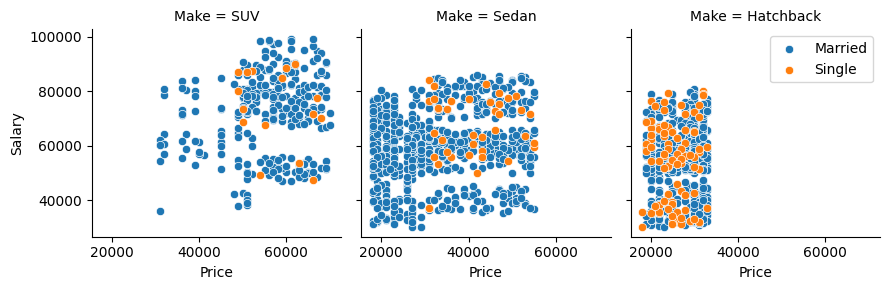

In [55]:
g = sns.FacetGrid(df, col="Make", hue="Marital_status", col_wrap=3)
g.map(sns.scatterplot, 'Price', 'Salary')
plt.legend()
plt.show()

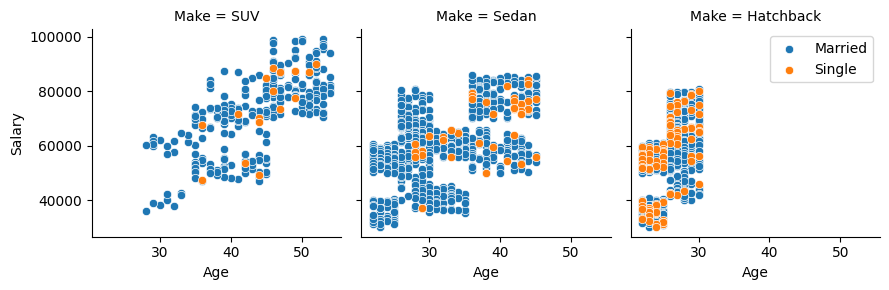

In [56]:
g = sns.FacetGrid(df, col="Make", hue="Marital_status", col_wrap=3)
g.map(sns.scatterplot, 'Age', 'Salary')
plt.legend()
plt.show()

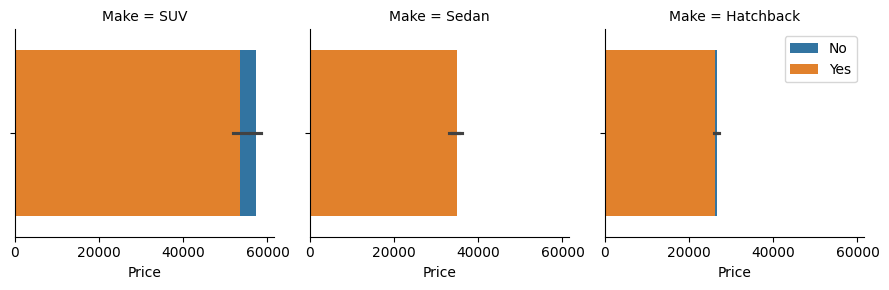

In [57]:
g = sns.FacetGrid(df, col="Make", hue="Personal_loan", col_wrap=3)
g.map(sns.barplot, 'Price', dodge = False)
plt.legend()
plt.show()

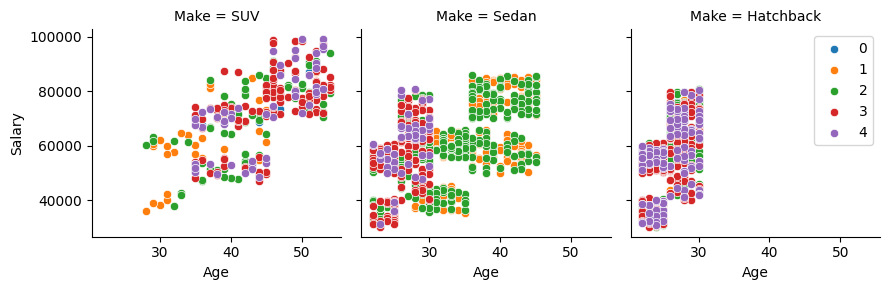

In [58]:
g = sns.FacetGrid(df, col="Make", hue="No_of_Dependents", col_wrap=3)
g.map(sns.scatterplot, 'Age', 'Salary')
plt.legend()
plt.show()

## Criteria

Key Questions

Explore the data to answer the following key questions:
1. Do men tend to prefer SUVs more compared to women?
2. What is the likelihood of a salaried person buying a Sedan?
3. What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?
4. How does the the amount spent on purchasing automobiles vary by gender?
5. How much money was spent on purchasing automobiles by individuals who took a personal loan?
6. How does having a working partner influence the purchase of higher-priced cars?

In [59]:
# Do men tend to prefer SUVs more compared to women?

df.groupby(by = ['Gender', 'Make'])['Make'].count().unstack()

Make,Hatchback,SUV,Sedan
Gender,,,
Female,15,173,141
Male,567,124,561


In [60]:
df.groupby(by = ['Gender', 'Make'])['Make'].count().unstack().rank(ascending=False, method = 'dense')

Make,Hatchback,SUV,Sedan
Gender,,,
Female,2.0,1.0,2.0
Male,1.0,2.0,1.0


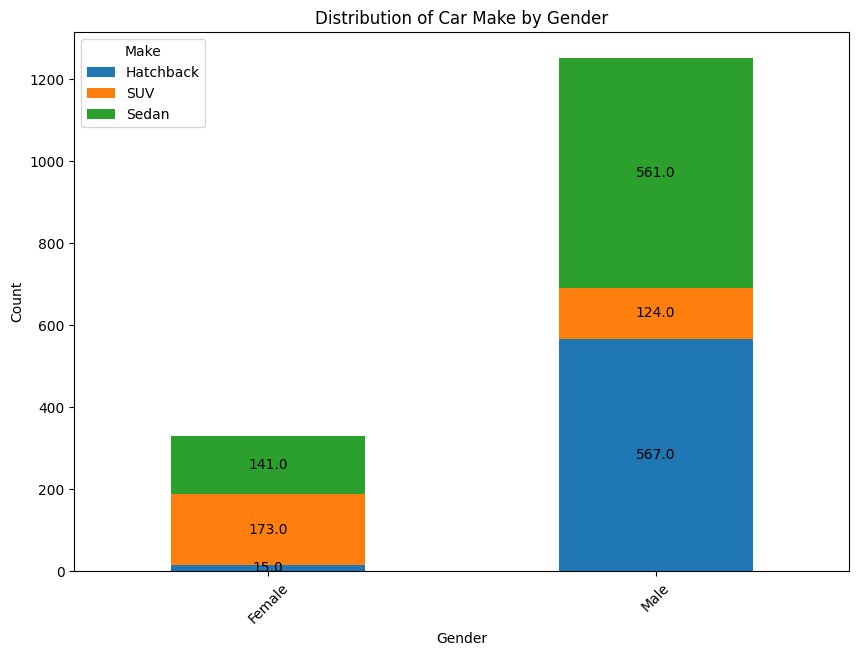

In [61]:
# Reshape the data for plotting and stack it
gender_make_counts = df.groupby(['Gender', 'Make']).size().unstack()
ax = gender_make_counts.plot(kind='bar', stacked=True, figsize=(10, 7))

plt.title('Distribution of Car Make by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Make')

for container in ax.containers:
    labels = [f'{bar.get_height()}' if bar.get_height() > 0 else '' for bar in container]
    ax.bar_label(container, labels=labels, label_type='center')

plt.show()

### Do men tend to prefer SUVs more compared to women?
---
* **SUV Purchase by Gender**: In this sample, more **females bought SUVs** than males.
* **Relative Preference**: When considering the proportion of purchases within each gender category, **females show a higher preference for SUVs** compared to males.

In [62]:
# What is the likelihood of a salaried person buying a Sedan?

df.groupby(by = ['Profession', 'Make'])['Make'].count()

Profession  Make     
Business    Hatchback    290
            SUV           89
            Sedan        306
Salaried    Hatchback    292
            SUV          208
            Sedan        396
Name: Make, dtype: int64

In [63]:
profession_make_table = df.groupby(['Profession', 'Make']).size().unstack(fill_value=0)
display(profession_make_table)

Make,Hatchback,SUV,Sedan
Profession,,,
Business,290,89,306
Salaried,292,208,396


In [64]:
# Applying Bayes Theorem - likelihood of a person buying Sedan given that he is salaried
salaried_person = df[df['Profession'] == 'Salaried']

In [65]:
likelihood = round((salaried_person[salaried_person['Make'] == 'Sedan'].shape[0] / salaried_person.shape[0])* 100, 2)
print(f'The Salaried person likely to buy a sedan is {likelihood}%')

The Salaried person likely to buy a sedan is 44.2%


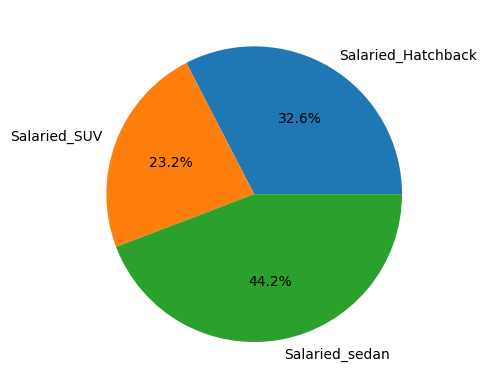

In [66]:
plt.pie(salaried_person.groupby(by = ['Make'])['Make'].count().values,
                labels=[
                'Salaried_Hatchback',
                'Salaried_SUV',
                'Salaried_sedan'],
        autopct='%1.1f%%')
plt.show()

### What is the likelihood of a salaried person buying a Sedan?

- likelihood of Salaried person buying Sedan is 44.2%

In [67]:
# What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?
df.groupby(by = ['Gender', 'Profession', 'Make'])['Make'].count().unstack()

Make               Hatchback    SUV  Sedan
Gender Profession                         
Female Business          NaN   55.0   50.0
       Salaried         15.0  118.0   91.0
Male   Business        290.0   34.0  256.0
       Salaried        277.0   90.0  305.0

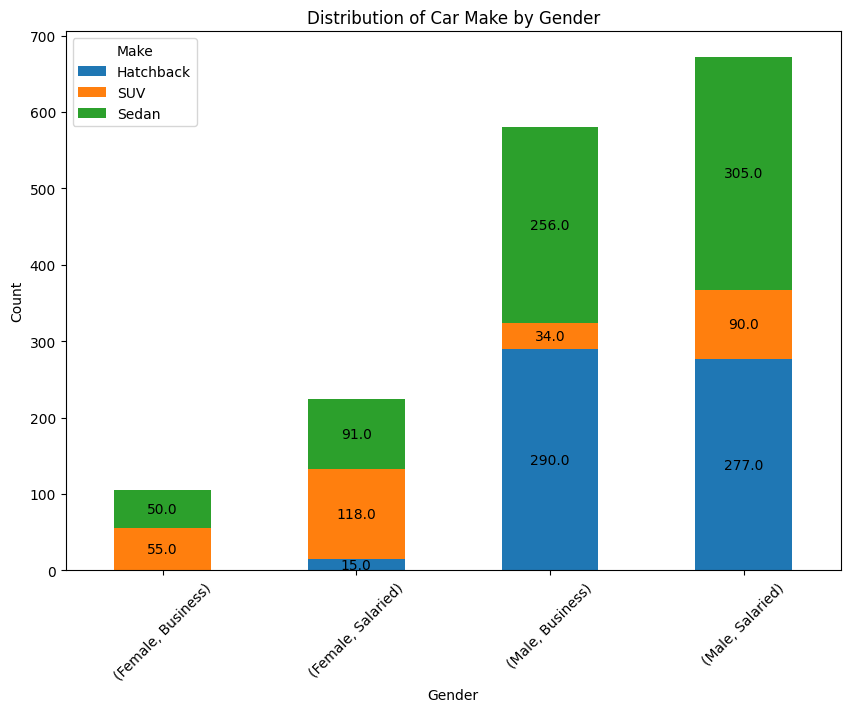

In [68]:
gender_Profession_make_counts = df.groupby(['Gender', 'Profession', 'Make']).size().unstack()
ax = gender_Profession_make_counts.plot(kind='bar', stacked=True, figsize=(10, 7))

plt.title('Distribution of Car Make by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Make')

for container in ax.containers:
    labels = [f'{bar.get_height()}' if bar.get_height() > 0 else '' for bar in container]
    ax.bar_label(container, labels=labels, label_type='center')

plt.show()

### Inferences

* **Sheldon Cooper's Claim**: Sheldon Cooper's claim that a salaried male is an easier target for an **SUV** sale is **incorrect**. The data indicates that salaried males are **more likely to buy a Sedan** than an SUV. This preference is likely due to the combination of their professional role and financial considerations.

In [69]:
# How does the the amount spent on purchasing automobiles vary by gender?
df.pivot_table(index='Gender', values = 'Price', columns='Make', margins=True, aggfunc = ['sum', 'mean']).round(2)

sum                                    mean                      \
Make   Hatchback       SUV     Sedan       All Hatchback       SUV     Sedan   
Gender                                                                         
Female    412000   9252000   6031000  15695000  27466.67  53479.77  42773.05   
Male    14996000   7328000  18261000  40585000  26447.97  59096.77  32550.80   
All     15408000  16580000  24292000  56280000  26474.23  55824.92  34603.99   

                  
Make         All  
Gender            
Female  47705.17  
Male    32416.13  
All     35597.72

In [70]:
df.groupby(by = ['Gender', 'Make'])['Price'].mean()

Gender  Make     
Female  Hatchback    27466.666667
        SUV          53479.768786
        Sedan        42773.049645
Male    Hatchback    26447.971781
        SUV          59096.774194
        Sedan        32550.802139
Name: Price, dtype: float64

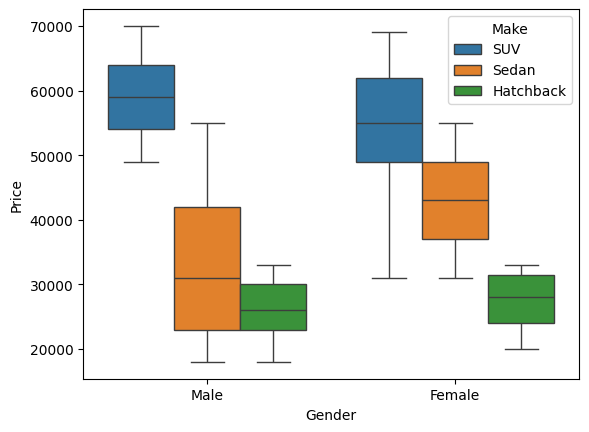

In [71]:
sns.boxplot(df, x = 'Gender', y = 'Price', hue = 'Make');

### How does the the amount spent on purchasing automobiles vary by gender?
---
The data suggests a clear gender-based preference in vehicle purchases: **men tend to buy Sedans**, while **women are more likely to purchase SUVs**.

values [np.float64(36742.71229404309), np.float64(34457.07070707071)]


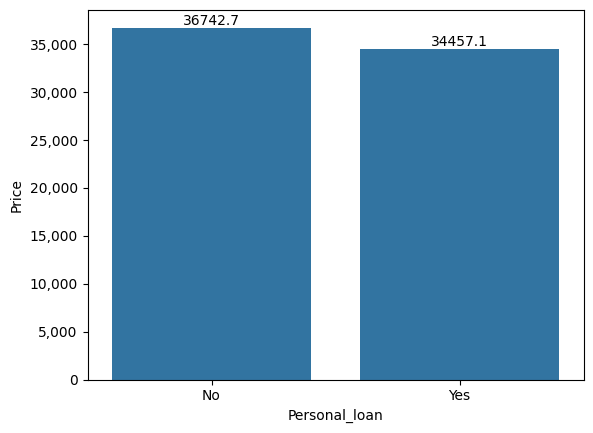

In [72]:
# How much money was spent on purchasing automobiles by individuals who took a personal loan?

g = sns.barplot(data=df, x = 'Personal_loan', y = 'Price', estimator='mean', errorbar=('ci', False))
formatter = FuncFormatter(lambda x, _: '{:,.0f}'.format(x))
plt.gca().yaxis.set_major_formatter(formatter)
heights= [i.get_height() for i in g.containers[0]]
print(f'values {heights}')
g.bar_label(g.containers[0], label_type='edge');
plt.savefig('amt_spent_vary_personal_loan.jpg')
plt.show()

In [73]:
df.groupby(by = ['Personal_loan'])['Price'].mean()

,Price
Personal_loan,
No,36742.712294
Yes,34457.070707


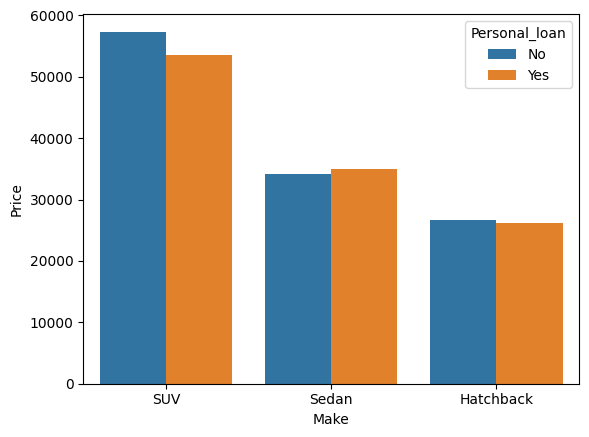

In [74]:
g = sns.barplot(data=df, x = 'Make', y = 'Price', hue='Personal_loan', estimator='mean', errorbar=('ci', False))

In [75]:
df['price_bucket'] = pd.cut(df['Price'], bins=3, labels=['LOW','MEDIUM', 'HIGH'])

In [76]:
df.groupby(by = ['price_bucket', 'Partner_working'])['Partner_working'].count().unstack()

Partner_working,No,Yes
price_bucket,,
LOW,440,542
MEDIUM,159,202
HIGH,114,124


In [77]:
df.groupby(by = ['Personal_loan'])['Price'].agg(['mean', 'median', 'min', 'max', 'sum']).round(2)

,mean,median,min,max,sum
Personal_loan,,,,,
No,36742.71,32000.0,18000,70000,28990000
Yes,34457.07,31000.0,18000,70000,27290000


### Inferences on Personal Loan Influence
---
* **Purchase Influence**: The decision to take a personal loan **did not significantly influence** the customer's choice of vehicle make or its price.
* **Average Spending**: The average amount spent on a vehicle is very similar for both groups: **\$34,457** for those with a personal loan, and **\$36,742** for those without.
* **Total Spending**: While the total amount spent by customers without a personal loan is slightly higher (\$28.99 million) than by those with a loan (\$27.29 million), this difference is likely due to the larger size of the "no loan" group and does not reflect a change in vehicle preference or price point. The data visualization further confirms that the distribution of purchases across different vehicle **Makes** is unaffected by personal loan status.

In [78]:
# How does having a working partner influence the purchase of higher-priced cars?
df.Marital_status.value_counts()

,count
Marital_status,
Married,1443
Single,138


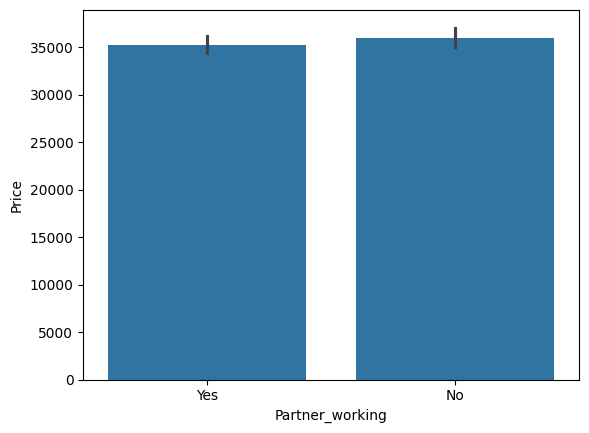

In [79]:
sns.barplot(data=df, x = 'Partner_working', y = 'Price', estimator='mean');

In [80]:
df.pivot_table(index='Partner_working' , values = ['Price', 'Total_salary'], columns='Make', aggfunc=['mean', 'sum']).round(2)

mean                                              \
                    Price                     Total_salary              
Make            Hatchback       SUV     Sedan    Hatchback        SUV   
Partner_working                                                         
No               26323.84  56173.61  35354.17     55056.94   71630.56   
Yes              26614.62  55496.73  34082.13     85918.60  120084.31   

                                sum                                            \
                              Price                    Total_salary             
Make                Sedan Hatchback      SUV     Sedan    Hatchback       SUV   
Partner_working                                                                 
No               60312.85   7397000  8089000  10182000     15471000  10314800   
Yes              92991.30   8011000  8491000  14110000     25861500  18372900   

                           
                           
Make                Sedan  
Partner_working            
No               17370100  
Yes              38498400

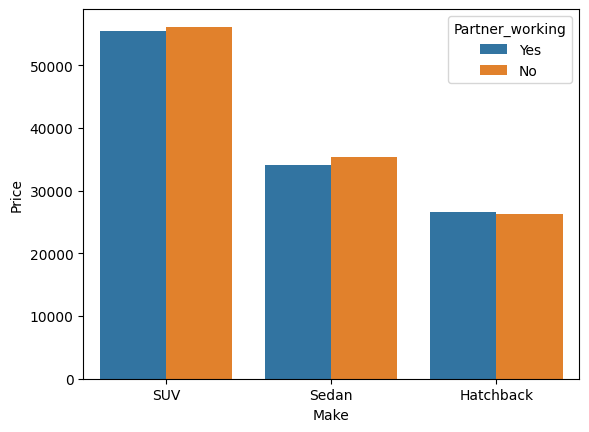

In [81]:
g = sns.barplot(data=df, x = 'Make', y = 'Price', hue='Partner_working', estimator='mean', errorbar=('ci', False))

### Inferences on Partner Working Influence
---
* **Minimal Impact on Purchase**: The status of a customer's partner working **has little influence** on the vehicle purchase decision, including the preferred **Make** (SUV, Sedan, Hatchback) and the **price point**.
* **Spending Disconnect**: Despite the fact that the **cumulative total salary is 1.5 times higher** for customers with a working partner, their average vehicle spending (\$35,267) is virtually the same as those whose partner isn't working (\$36,000).
* **Conclusion**: This suggests that the substantial increase in household income from a working partner **does not translate into an increase in the vehicle purchase budget** or a change in the type of car they buy. The decision appears to be driven by other factors, such as necessity or the primary earner's income.